# Non-Invasive Blood Glucose Estimation Using PPG and Machine Learning

**Research-Grade Analysis Notebook — Chapter 4 Foundation**

This notebook performs a complete analysis of an experimental PPG-BGL dataset:
1. Dataset and participant demographics/descriptive statistics
2. PPG signal quality assessment and preprocessing
3. Literature-informed PPG feature engineering
4. Rigorous machine-learning regression with multiple validation strategies
5. Comprehensive model evaluation and interpretation

**Research Question:** Can blood glucose level (BGL) be estimated from PPG-derived features using machine-learning regression?

**Important:** The model uses **PPG-derived information only** as predictors. Demographic variables are explored descriptively but are NOT used as ML features.

---
## 1. Configuration and Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import neurokit2 as nk
from scipy import signal as scipy_signal
from scipy.stats import (skew, kurtosis, pearsonr, spearmanr,
                          mannwhitneyu, normaltest, shapiro)
from scipy.interpolate import interp1d
from scipy.fft import rfft, rfftfreq
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor, HistGradientBoostingRegressor)
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet)
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import (KFold, GroupKFold, LeaveOneGroupOut,
                                      RandomizedSearchCV, learning_curve,
                                      cross_val_predict)
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              median_absolute_error)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import (SelectKBest, f_regression,
                                        mutual_info_regression)
from sklearn.base import BaseEstimator, RegressorMixin
import xgboost as xgb
import joblib

try:
    import catboost as cb
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False

try:
    import lightgbm as lgb
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='DFA_alpha2')
warnings.filterwarnings('ignore', category=RuntimeWarning)

# --- Global Configuration ---
RANDOM_STATE = 42
SAMPLING_RATE = 50          # Hz
ORIGINAL_DURATION = 70      # seconds
TRIM_SECONDS = 5            # seconds to trim from each end
ANALYSIS_DURATION = 60      # seconds after trimming
EXPECTED_TOTAL_SAMPLES = ORIGINAL_DURATION * SAMPLING_RATE  # 3500
TRIM_SAMPLES = TRIM_SECONDS * SAMPLING_RATE                 # 250
ANALYSIS_SAMPLES = ANALYSIS_DURATION * SAMPLING_RATE        # 3000
N_SPLITS = 5
CSV_PATH = "data/real/glucosense_r_dataset_2026-09-04.csv"

np.random.seed(RANDOM_STATE)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'figure.dpi': 130,
    'figure.figsize': (12, 6),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'savefig.bbox': 'tight',
    'savefig.dpi': 150,
})

# Output directories
os.makedirs('results', exist_ok=True)
os.makedirs('figures', exist_ok=True)

print("=" * 65)
print("  NON-INVASIVE BGL ESTIMATION — RESEARCH NOTEBOOK")
print("=" * 65)
print(f"  Random state:       {RANDOM_STATE}")
print(f"  Sampling rate:      {SAMPLING_RATE} Hz")
print(f"  Analysis window:    {ANALYSIS_DURATION}s ({ANALYSIS_SAMPLES} samples)")
print(f"  CV splits:          {N_SPLITS}")
print(f"  CatBoost:           {HAS_CATBOOST}")
print(f"  LightGBM:           {HAS_LIGHTGBM}")
print(f"  SHAP:               {HAS_SHAP}")
print("=" * 65)

  NON-INVASIVE BGL ESTIMATION — RESEARCH NOTEBOOK
  Random state:       42
  Sampling rate:      50 Hz
  Analysis window:    60s (3000 samples)
  CV splits:          5
  CatBoost:           True
  LightGBM:           True
  SHAP:               True


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 2. Data Loading and Internal Representation

In [2]:
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"Dataset not found: {CSV_PATH}")

df_raw = pd.read_csv(CSV_PATH)
print(f"CSV loaded: {len(df_raw)} rows × {len(df_raw.columns)} columns")
print(f"Columns: {list(df_raw.columns)}")
display(df_raw.head(3))

CSV loaded: 73 rows × 13 columns
Columns: ['session_id', 'created_at', 'participant_id', 'age', 'gender', 'weight_kg', 'height_cm', 'years_on_t2dm', 'medication', 'session_kind', 'bgl_mgdl', 'ppg_samples_count', 'ppg_data']


,session_id,created_at,participant_id,age,gender,weight_kg,height_cm,years_on_t2dm,medication,session_kind,bgl_mgdl,ppg_samples_count,ppg_data
0,fce4b7a2-b3db-4b11-81e7-9c8f8ace228d,2026-08-06T09:03:50.335985+00:00,P001,73,Female,74.0,120.0,8,"Alphabetuc+, glepid-2, sealmet, trevisa",fasting,196,3500,57994;58030;58020;58027;58013;58039;58044;5805...
1,07dc95d8-8001-417f-b139-d4faf092b371,2026-08-06T10:34:31.431381+00:00,P001,73,Female,74.0,120.0,8,"Alphabetuc+, glepid-2, sealmet, trevisa",1hr_post_prandial,269,3500,59419;59453;59470;59475;59513;59507;59529;5956...
2,2fb9eb9e-4f36-4749-bb66-78510db5dde9,2026-08-27T07:56:02.871753+00:00,P002,63,Female,79.0,172.0,21,NaN,fasting,190,3500,55490;55479;55469;55480;55473;55469;55476;5548...


In [3]:
# Build clean internal representation
recordings = []
ppg_parse_errors = []

for idx, row in df_raw.iterrows():
    try:
        ppg_str = str(row['ppg_data'])
        ppg_values = np.array([int(x) for x in ppg_str.split(';')], dtype=np.float64)
    except Exception as e:
        ppg_parse_errors.append((idx, row.get('session_id', 'unknown'), str(e)))
        continue

    rec = {
        'recording_id': row['session_id'],
        'participant_id': row['participant_id'],
        'bgl': float(row['bgl_mgdl']),
        'ppg_raw_full': ppg_values,
        'ppg_samples_count': int(row['ppg_samples_count']),
        'demographics': {
            'age': row.get('age', np.nan),
            'gender': row.get('gender', np.nan),
            'weight_kg': row.get('weight_kg', np.nan),
            'height_cm': row.get('height_cm', np.nan),
            'years_on_t2dm': row.get('years_on_t2dm', np.nan),
            'medication': row.get('medication', np.nan),
            'session_kind': row.get('session_kind', np.nan),
        },
        'created_at': row.get('created_at', np.nan),
    }
    recordings.append(rec)

print(f"\nParsed {len(recordings)} recordings successfully.")
if ppg_parse_errors:
    print(f"  Parse errors: {len(ppg_parse_errors)}")
    for err in ppg_parse_errors:
        print(f"    Row {err[0]}: {err[2]}")
else:
    print("  No parse errors.")


Parsed 73 recordings successfully.
  No parse errors.


---
## 3. Dataset Overview

In [4]:
participant_ids = [r['participant_id'] for r in recordings]
unique_participants = sorted(set(participant_ids))
recs_per_participant = pd.Series(participant_ids).value_counts().sort_index()

# Check for age anomalies and replace with median
ages_raw = [r['demographics']['age'] for r in recordings]
valid_ages = [a for a in ages_raw if pd.notna(a) and a > 5]  # age > 5 is plausible
age_median = np.nanmedian(valid_ages)

for r in recordings:
    a = r['demographics']['age']
    if pd.isna(a) or a <= 5:
        print(f"  ⚠ Recording {r['recording_id'][:8]}... (P={r['participant_id']}): "
              f"age={a} replaced with median={age_median:.0f}")
        r['demographics']['age'] = age_median

# Calculate BMI where possible
for r in recordings:
    w = r['demographics']['weight_kg']
    h = r['demographics']['height_cm']
    if pd.notna(w) and pd.notna(h) and h > 0:
        r['demographics']['bmi'] = float(w) / (float(h) / 100.0) ** 2
    else:
        r['demographics']['bmi'] = np.nan

# Dataset overview table
ppg_sample_counts = [len(r['ppg_raw_full']) for r in recordings]
expected_ok = sum(1 for c in ppg_sample_counts if c == EXPECTED_TOTAL_SAMPLES)

overview_data = {
    'Property': [
        'Total recordings', 'Unique participants', 'Min recordings/participant',
        'Max recordings/participant', 'Mean recordings/participant',
        'Median recordings/participant', 'PPG sampling frequency',
        'Original recording duration', 'Trim (each end)',
        'Analysis window', 'Expected PPG samples (original)',
        'Recordings with expected samples', 'Missing BGL values',
        'Duplicate session IDs'
    ],
    'Value': [
        len(recordings), len(unique_participants),
        recs_per_participant.min(), recs_per_participant.max(),
        f"{recs_per_participant.mean():.2f}", f"{recs_per_participant.median():.1f}",
        f"{SAMPLING_RATE} Hz", f"{ORIGINAL_DURATION}s",
        f"{TRIM_SECONDS}s", f"{ANALYSIS_DURATION}s ({ANALYSIS_SAMPLES} samples)",
        EXPECTED_TOTAL_SAMPLES,
        f"{expected_ok}/{len(recordings)}",
        sum(1 for r in recordings if pd.isna(r['bgl'])),
        len([r['recording_id'] for r in recordings]) - len(set([r['recording_id'] for r in recordings]))
    ]
}
overview_df = pd.DataFrame(overview_data)
print("\n=== DATASET OVERVIEW ===")
display(overview_df.style.hide(axis='index').set_properties(**{'text-align': 'left'}))
overview_df.to_csv('results/dataset_overview.csv', index=False)

# Participants with multiple recordings
multi_rec = recs_per_participant[recs_per_participant > 1]
if len(multi_rec) > 0:
    print(f"\nParticipants with multiple recordings ({len(multi_rec)}):")
    for pid, count in multi_rec.items():
        bgls = [r['bgl'] for r in recordings if r['participant_id'] == pid]
        kinds = [r['demographics']['session_kind'] for r in recordings if r['participant_id'] == pid]
        print(f"  {pid}: {count} recordings, BGL={bgls}, Sessions={kinds}")

  ⚠ Recording 18d73372... (P=P050): age=1 replaced with median=63

=== DATASET OVERVIEW ===


Property,Value
Total recordings,73
Unique participants,63
Min recordings/participant,1
Max recordings/participant,2
Mean recordings/participant,1.16
Median recordings/participant,1.0
PPG sampling frequency,50 Hz
Original recording duration,70s
Trim (each end),5s
Analysis window,60s (3000 samples)



Participants with multiple recordings (10):
  P001: 2 recordings, BGL=[196.0, 269.0], Sessions=['fasting', '1hr_post_prandial']
  P010: 2 recordings, BGL=[85.0, 239.0], Sessions=['fasting', '2hr_post_prandial']
  P011: 2 recordings, BGL=[106.0, 142.0], Sessions=['fasting', '2hr_post_prandial']
  P012: 2 recordings, BGL=[125.0, 221.0], Sessions=['fasting', '2hr_post_prandial']
  P014: 2 recordings, BGL=[137.0, 176.0], Sessions=['fasting', '2hr_post_prandial']
  P043: 2 recordings, BGL=[108.0, 194.0], Sessions=['fasting', '2hr_post_prandial']
  P051: 2 recordings, BGL=[108.0, 232.0], Sessions=['fasting', '2hr_post_prandial']
  P052: 2 recordings, BGL=[180.0, 183.0], Sessions=['1hr_post_prandial', '2hr_post_prandial']
  P054: 2 recordings, BGL=[144.0, 184.0], Sessions=['1hr_post_prandial', '1hr_post_prandial']
  P055: 2 recordings, BGL=[256.0, 212.0], Sessions=['2hr_post_prandial', '2hr_post_prandial']


---
## 4. Demographic Analysis — Continuous Variables

Descriptive statistics for continuous demographic and clinical variables.
Age anomalies (≤5 years) have been replaced with the column median.

In [5]:
# Gather continuous demographic data
demo_records = []
for r in recordings:
    d = r['demographics']
    demo_records.append({
        'participant_id': r['participant_id'],
        'age': d['age'],
        'gender': d['gender'],
        'weight_kg': d['weight_kg'],
        'height_cm': d['height_cm'],
        'bmi': d.get('bmi', np.nan),
        'years_on_t2dm': d['years_on_t2dm'],
        'session_kind': d['session_kind'],
        'bgl_mgdl': r['bgl'],
    })
demo_df = pd.DataFrame(demo_records)

# Use participant-level data for demographics (avoid double-counting)
demo_participant = demo_df.drop_duplicates(subset='participant_id')

continuous_vars = {
    'Age (years)': demo_participant['age'],
    'Weight (kg)': demo_participant['weight_kg'],
    'Height (cm)': demo_participant['height_cm'],
    'BMI (kg/m²)': demo_participant['bmi'],
    'Years on T2DM': demo_participant['years_on_t2dm'],
    'BGL (mg/dL)': demo_df['bgl_mgdl'],  # recording-level for BGL
}

desc_rows = []
for name, series in continuous_vars.items():
    s = series.dropna()
    desc_rows.append({
        'Variable': name,
        'N': len(s),
        'Mean': f"{s.mean():.1f}",
        'SD': f"{s.std():.1f}",
        'Min': f"{s.min():.1f}",
        'Q1': f"{s.quantile(0.25):.1f}",
        'Median': f"{s.median():.1f}",
        'Q3': f"{s.quantile(0.75):.1f}",
        'Max': f"{s.max():.1f}",
        'IQR': f"{s.quantile(0.75) - s.quantile(0.25):.1f}",
    })

desc_table = pd.DataFrame(desc_rows)
print("=== TABLE 1: Descriptive Statistics — Continuous Variables ===")
display(desc_table.style.hide(axis='index'))
desc_table.to_csv('results/demographic_statistics.csv', index=False)

=== TABLE 1: Descriptive Statistics — Continuous Variables ===


Variable,N,Mean,SD,Min,Q1,Median,Q3,Max,IQR
Age (years),63,62.7,10.9,31.0,56.5,63.0,70.0,85.0,13.5
Weight (kg),63,70.9,10.9,47.0,63.4,72.0,77.3,101.3,13.9
Height (cm),63,162.9,9.9,120.0,157.0,165.0,168.5,180.0,11.5
BMI (kg/m²),63,26.9,5.3,18.4,23.9,26.3,28.5,51.4,4.6
Years on T2DM,63,7.5,7.0,0.0,2.0,5.0,11.0,25.0,9.0
BGL (mg/dL),73,151.5,55.2,73.0,109.0,139.0,188.0,394.0,79.0


## 5. Demographic Analysis — Categorical Variables

=== Categorical Demographics ===


Variable,Category,n,%
Gender,Female,44,69.8%
Gender,Male,19,30.2%
Session Kind,fasting,40,54.8%
Session Kind,2hr_post_prandial,22,30.1%
Session Kind,1hr_post_prandial,11,15.1%


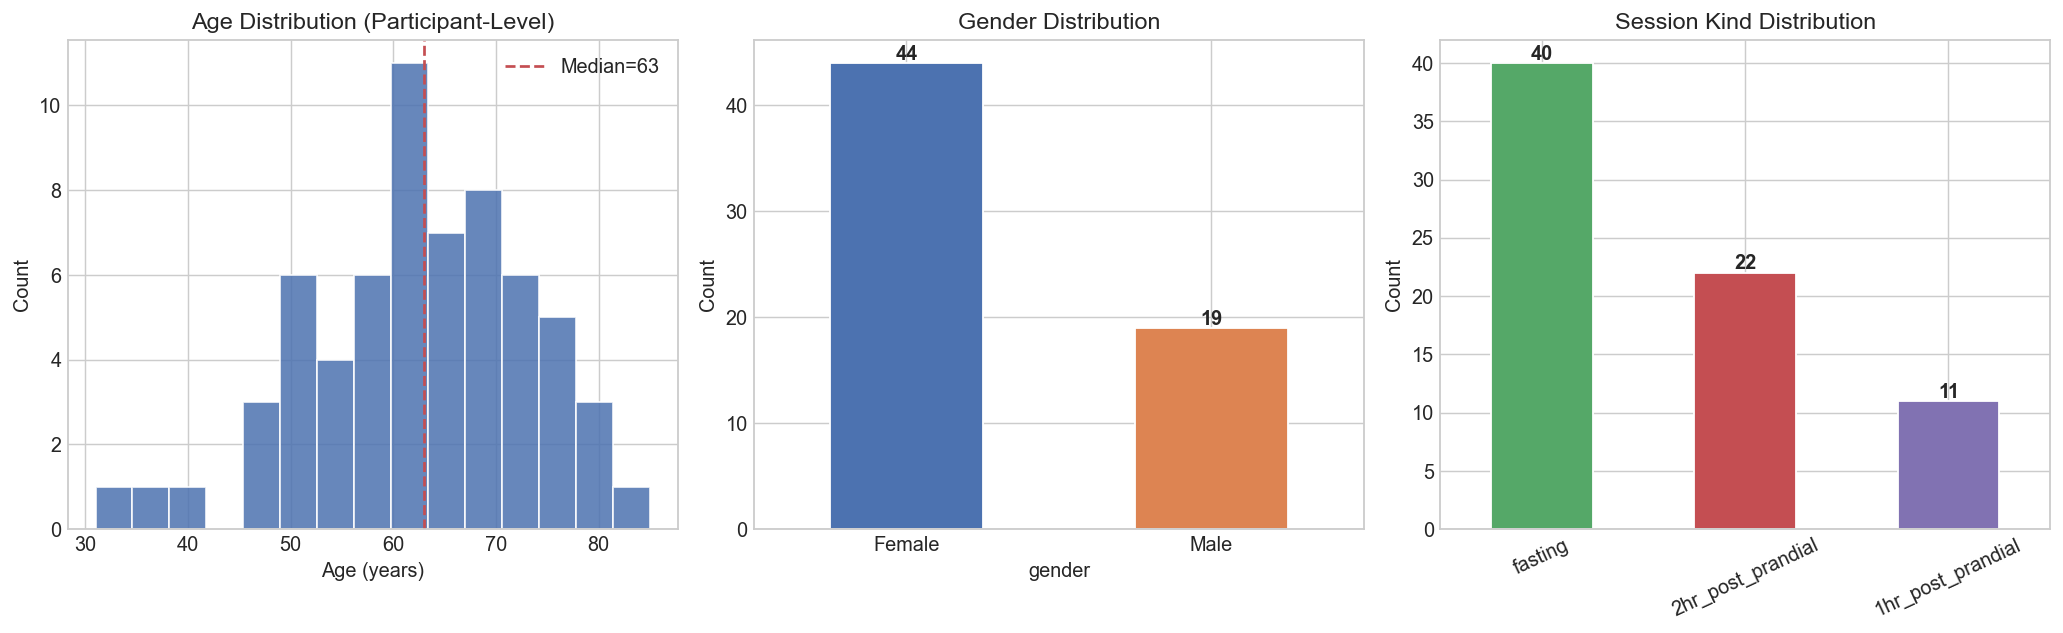

In [6]:
# Gender distribution (participant-level)
gender_counts = demo_participant['gender'].value_counts()
gender_pct = demo_participant['gender'].value_counts(normalize=True) * 100

cat_rows = []
for cat in gender_counts.index:
    cat_rows.append({
        'Variable': 'Gender',
        'Category': cat,
        'n': gender_counts[cat],
        '%': f"{gender_pct[cat]:.1f}%"
    })

# Session kind distribution (recording-level)
session_counts = demo_df['participant_id'].to_frame().merge(
    pd.DataFrame([{'participant_id': r['participant_id'],
                    'session_kind': r['demographics']['session_kind']}
                   for r in recordings]),
    on='participant_id', how='left'
)
sk_counts = pd.Series([r['demographics']['session_kind'] for r in recordings]).value_counts()
sk_pct = pd.Series([r['demographics']['session_kind'] for r in recordings]).value_counts(normalize=True) * 100
for cat in sk_counts.index:
    cat_rows.append({
        'Variable': 'Session Kind',
        'Category': cat,
        'n': sk_counts[cat],
        '%': f"{sk_pct[cat]:.1f}%"
    })

cat_table = pd.DataFrame(cat_rows)
print("=== Categorical Demographics ===")
display(cat_table.style.hide(axis='index'))

# Visualisations
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age distribution
axes[0].hist(demo_participant['age'].dropna(), bins=15, color='#4C72B0',
             edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution (Participant-Level)')
axes[0].axvline(demo_participant['age'].median(), color='#C44E52', ls='--',
                label=f"Median={demo_participant['age'].median():.0f}")
axes[0].legend()

# Gender bar chart
colors_gender = ['#4C72B0', '#DD8452']
gender_counts.plot.bar(ax=axes[1], color=colors_gender[:len(gender_counts)],
                       edgecolor='white')
axes[1].set_title('Gender Distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
for i, (cat, cnt) in enumerate(gender_counts.items()):
    axes[1].text(i, cnt + 0.3, str(cnt), ha='center', fontweight='bold')

# Session kind bar chart
colors_session = ['#55A868', '#C44E52', '#8172B2']
sk_counts.plot.bar(ax=axes[2], color=colors_session[:len(sk_counts)],
                   edgecolor='white')
axes[2].set_title('Session Kind Distribution')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=25)
for i, (cat, cnt) in enumerate(sk_counts.items()):
    axes[2].text(i, cnt + 0.3, str(cnt), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/fig1_demographics.png')
plt.show()

---
## 6. BGL Distribution Analysis

In [7]:
bgl_values = np.array([r['bgl'] for r in recordings])

bgl_stats = {
    'N': len(bgl_values),
    'Mean': np.mean(bgl_values),
    'SD': np.std(bgl_values, ddof=1),
    'Min': np.min(bgl_values),
    'Q1': np.percentile(bgl_values, 25),
    'Median': np.median(bgl_values),
    'Q3': np.percentile(bgl_values, 75),
    'Max': np.max(bgl_values),
    'IQR': np.percentile(bgl_values, 75) - np.percentile(bgl_values, 25),
    'CV (%)': (np.std(bgl_values, ddof=1) / np.mean(bgl_values)) * 100,
    'Skewness': skew(bgl_values),
    'Kurtosis': kurtosis(bgl_values),
}

print("=== TABLE 2: BGL Descriptive Statistics ===")
bgl_stats_df = pd.DataFrame([{k: f"{v:.2f}" if isinstance(v, float) else v
                               for k, v in bgl_stats.items()}])
display(bgl_stats_df.T.rename(columns={0: 'Value'}))
bgl_stats_df.to_csv('results/bgl_statistics.csv', index=False)

# Normality test
stat_sw, p_sw = shapiro(bgl_values)
print(f"\nShapiro-Wilk test: W={stat_sw:.4f}, p={p_sw:.4f}")
if p_sw < 0.05:
    print("  → BGL distribution departs significantly from normality (p < 0.05)")
else:
    print("  → No significant departure from normality (p ≥ 0.05)")

=== TABLE 2: BGL Descriptive Statistics ===


,Value
N,73
Mean,151.48
SD,55.16
Min,73.00
Q1,109.00
Median,139.00
Q3,188.00
Max,394.00
IQR,79.00
CV (%),36.41



Shapiro-Wilk test: W=0.8864, p=0.0000
  → BGL distribution departs significantly from normality (p < 0.05)


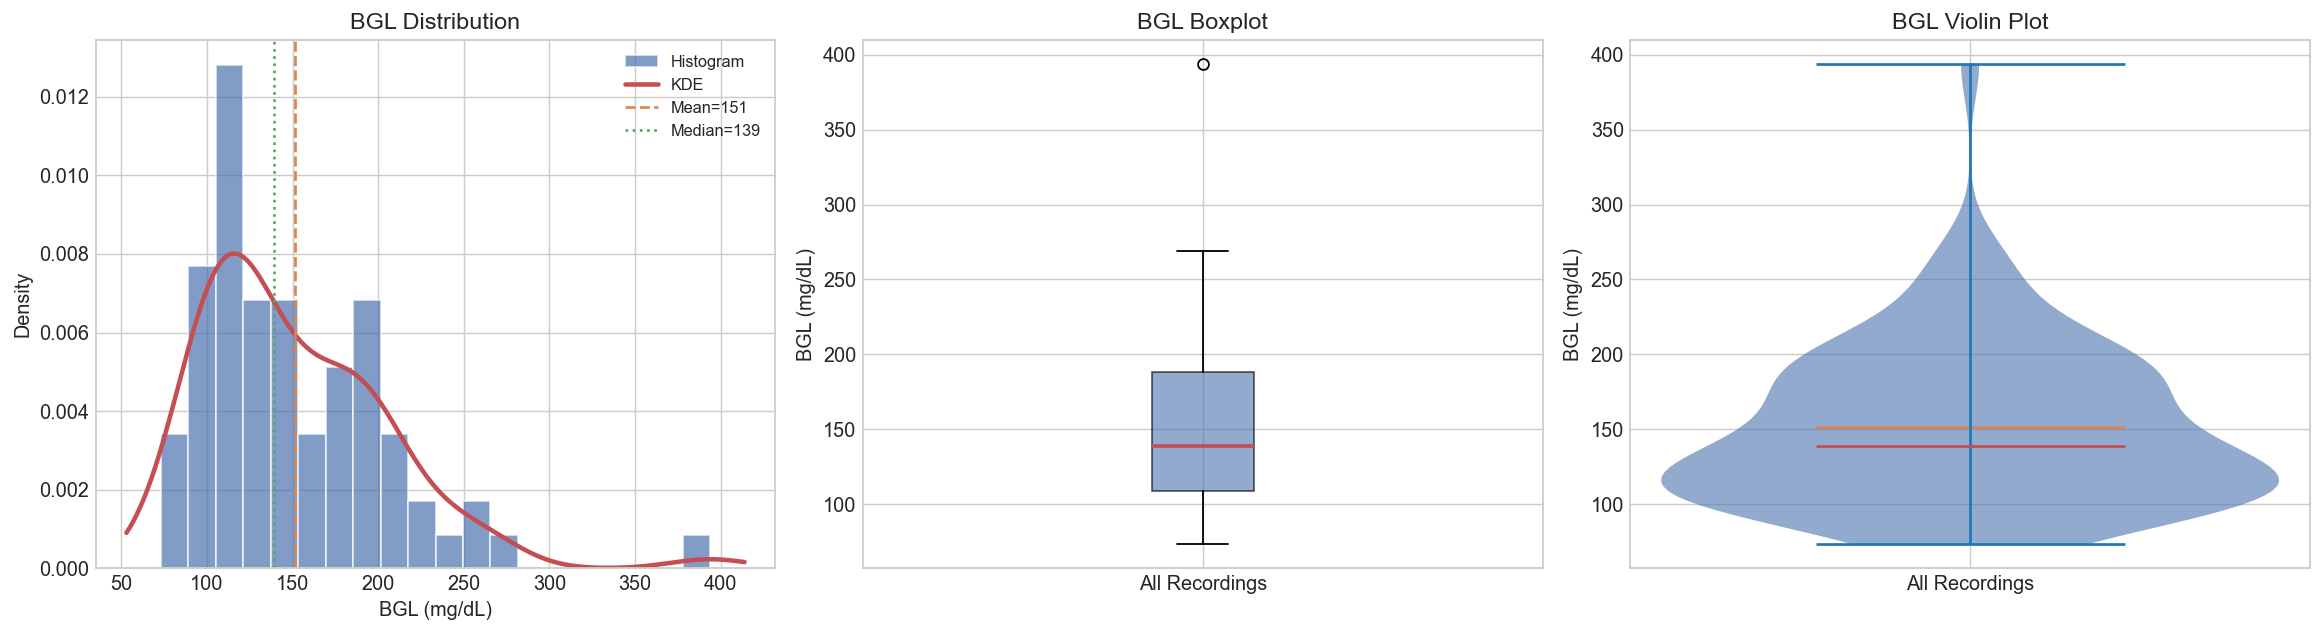


BGL Range Distribution (descriptive):
  Hypoglycemic (<70): 0 (0.0%)
  Normal (70-100): 8 (11.0%)
  Pre-diabetic (101-125): 23 (31.5%)
  Diabetic (>125): 42 (57.5%)


In [8]:
# BGL distribution visualisations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram + KDE
axes[0].hist(bgl_values, bins=20, density=True, color='#4C72B0',
             edgecolor='white', alpha=0.7, label='Histogram')
kde_x = np.linspace(bgl_values.min() - 20, bgl_values.max() + 20, 200)
from scipy.stats import gaussian_kde
kde = gaussian_kde(bgl_values)
axes[0].plot(kde_x, kde(kde_x), color='#C44E52', lw=2.5, label='KDE')
axes[0].axvline(np.mean(bgl_values), color='#DD8452', ls='--',
                label=f"Mean={np.mean(bgl_values):.0f}")
axes[0].axvline(np.median(bgl_values), color='#55A868', ls=':',
                label=f"Median={np.median(bgl_values):.0f}")
axes[0].set_xlabel('BGL (mg/dL)')
axes[0].set_ylabel('Density')
axes[0].set_title('BGL Distribution')
axes[0].legend(fontsize=9)

# Boxplot
bp = axes[1].boxplot(bgl_values, vert=True, patch_artist=True,
                      boxprops=dict(facecolor='#4C72B0', alpha=0.6),
                      medianprops=dict(color='#C44E52', lw=2))
axes[1].set_ylabel('BGL (mg/dL)')
axes[1].set_title('BGL Boxplot')
axes[1].set_xticklabels(['All Recordings'])

# Violin plot
parts = axes[2].violinplot(bgl_values, showmeans=True, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('#4C72B0')
    pc.set_alpha(0.6)
parts['cmeans'].set_color('#DD8452')
parts['cmedians'].set_color('#C44E52')
axes[2].set_ylabel('BGL (mg/dL)')
axes[2].set_title('BGL Violin Plot')
axes[2].set_xticks([1])
axes[2].set_xticklabels(['All Recordings'])

plt.tight_layout()
plt.savefig('figures/fig3_bgl_distribution.png')
plt.show()

# Clinical glucose ranges (descriptive only — NOT converting to classification)
print("\nBGL Range Distribution (descriptive):")
ranges = [
    ('Hypoglycemic (<70)', sum(bgl_values < 70)),
    ('Normal (70-100)', sum((bgl_values >= 70) & (bgl_values <= 100))),
    ('Pre-diabetic (101-125)', sum((bgl_values > 100) & (bgl_values <= 125))),
    ('Diabetic (>125)', sum(bgl_values > 125)),
]
for label, count in ranges:
    print(f"  {label}: {count} ({count/len(bgl_values)*100:.1f}%)")

## 7. BGL by Participant

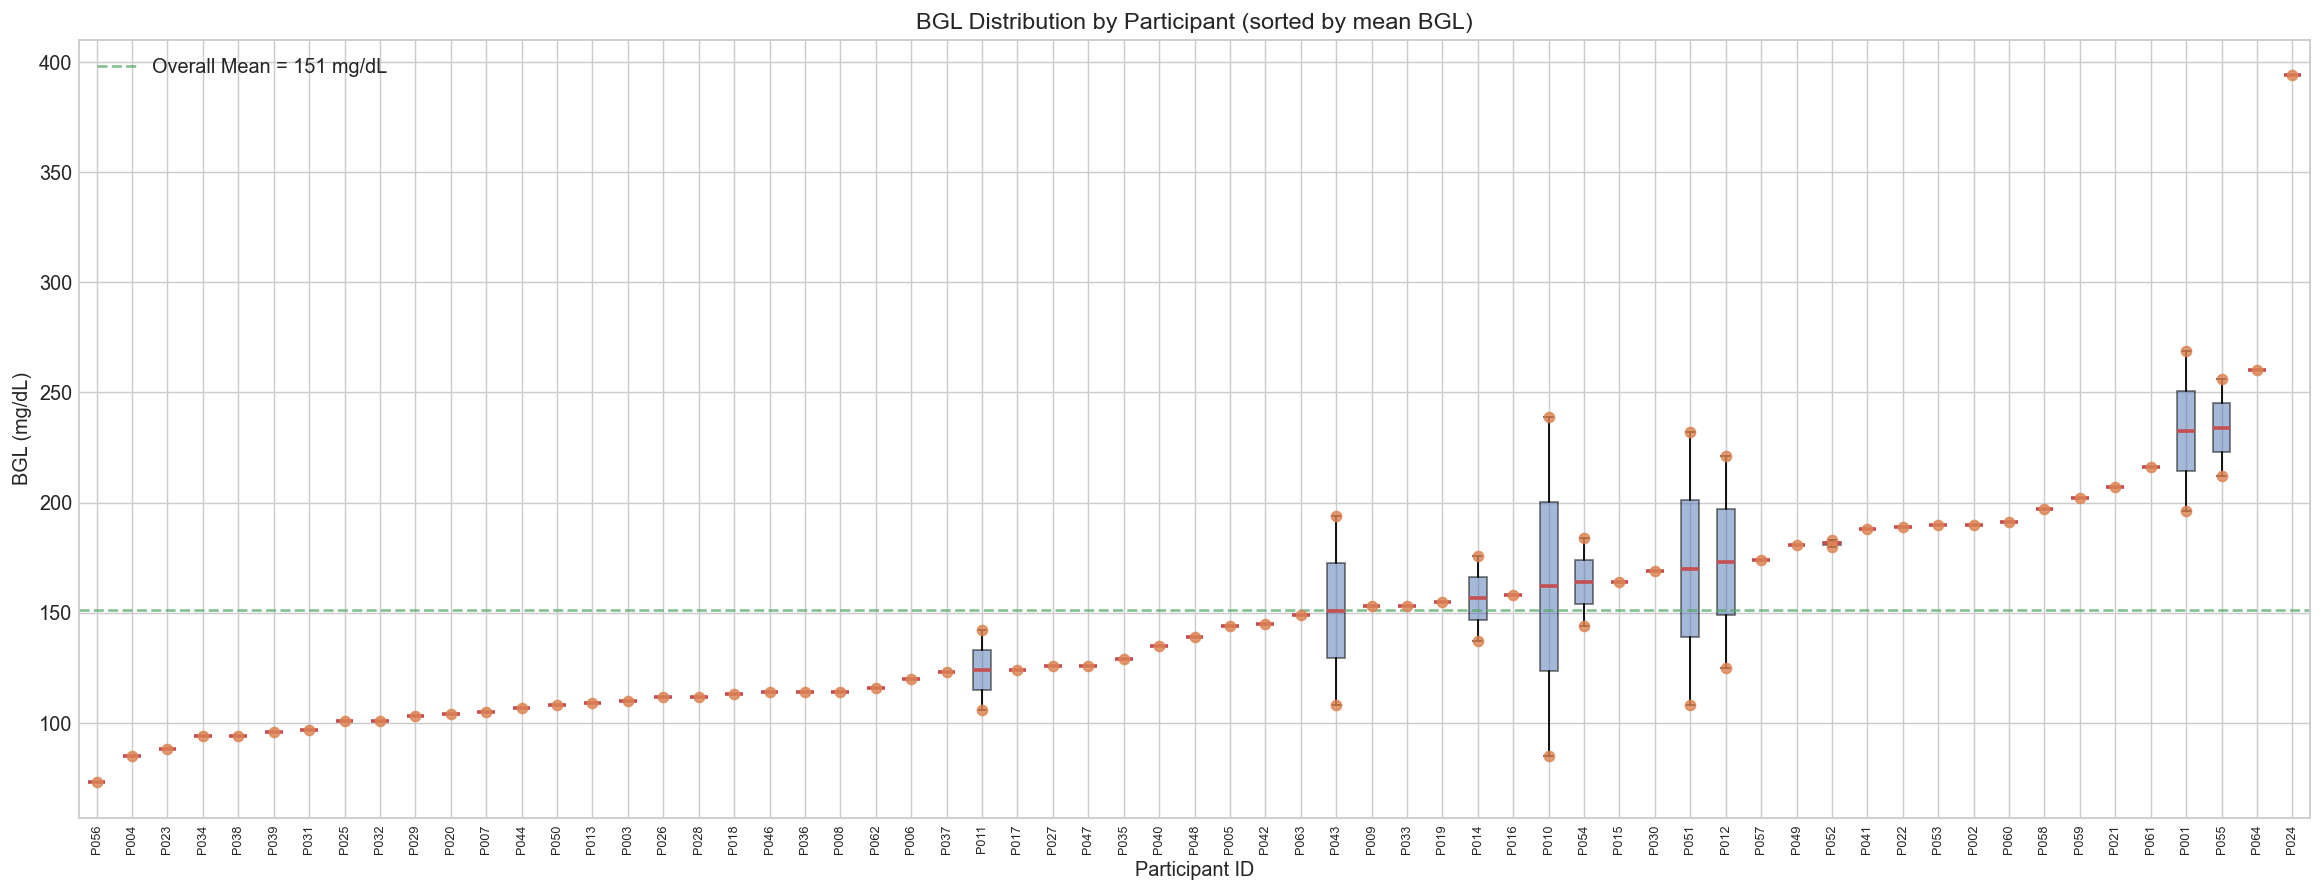


Between-participant BGL variation:
  SD of participant means: 52.1 mg/dL
  Range of participant means: 73 – 394 mg/dL


In [9]:
# Participant-level BGL analysis
participant_bgl = {}
for r in recordings:
    pid = r['participant_id']
    if pid not in participant_bgl:
        participant_bgl[pid] = []
    participant_bgl[pid].append(r['bgl'])

# Summary statistics per participant
part_stats = []
for pid in sorted(participant_bgl.keys()):
    vals = participant_bgl[pid]
    part_stats.append({
        'Participant': pid,
        'N': len(vals),
        'Mean BGL': np.mean(vals),
        'Median BGL': np.median(vals),
        'Min BGL': np.min(vals),
        'Max BGL': np.max(vals),
        'Range': np.max(vals) - np.min(vals),
    })
part_stats_df = pd.DataFrame(part_stats)

# Sort by mean BGL for visualization
part_stats_df = part_stats_df.sort_values('Mean BGL')

fig, ax = plt.subplots(figsize=(18, 7))
# Create a list of BGL values grouped by participant, sorted by mean
sorted_pids = part_stats_df['Participant'].tolist()
bgl_by_participant = [participant_bgl[pid] for pid in sorted_pids]

bp = ax.boxplot(bgl_by_participant, patch_artist=True, vert=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.5),
                medianprops=dict(color='#C44E52', lw=2),
                showfliers=True)

# For single-value participants, overlay scatter
for i, (pid, vals) in enumerate(zip(sorted_pids, bgl_by_participant)):
    ax.scatter([i + 1] * len(vals), vals, color='#DD8452', s=30,
               zorder=5, alpha=0.8)

ax.set_xticklabels(sorted_pids, rotation=90, fontsize=7)
ax.set_xlabel('Participant ID')
ax.set_ylabel('BGL (mg/dL)')
ax.set_title('BGL Distribution by Participant (sorted by mean BGL)')
ax.axhline(np.mean(bgl_values), color='#55A868', ls='--', alpha=0.7,
           label=f"Overall Mean = {np.mean(bgl_values):.0f} mg/dL")
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig4_bgl_by_participant.png')
plt.show()

print(f"\nBetween-participant BGL variation:")
participant_means = [np.mean(participant_bgl[pid]) for pid in unique_participants]
print(f"  SD of participant means: {np.std(participant_means, ddof=1):.1f} mg/dL")
print(f"  Range of participant means: {np.min(participant_means):.0f} – {np.max(participant_means):.0f} mg/dL")

## 8. BGL and Demographic Relationships

These relationships are explored descriptively. **Demographic variables are NOT used as ML predictors.**

/tmp/ipykernel_22660/2838087275.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([gender_data[g] for g in genders_sorted], patch_artist=True,


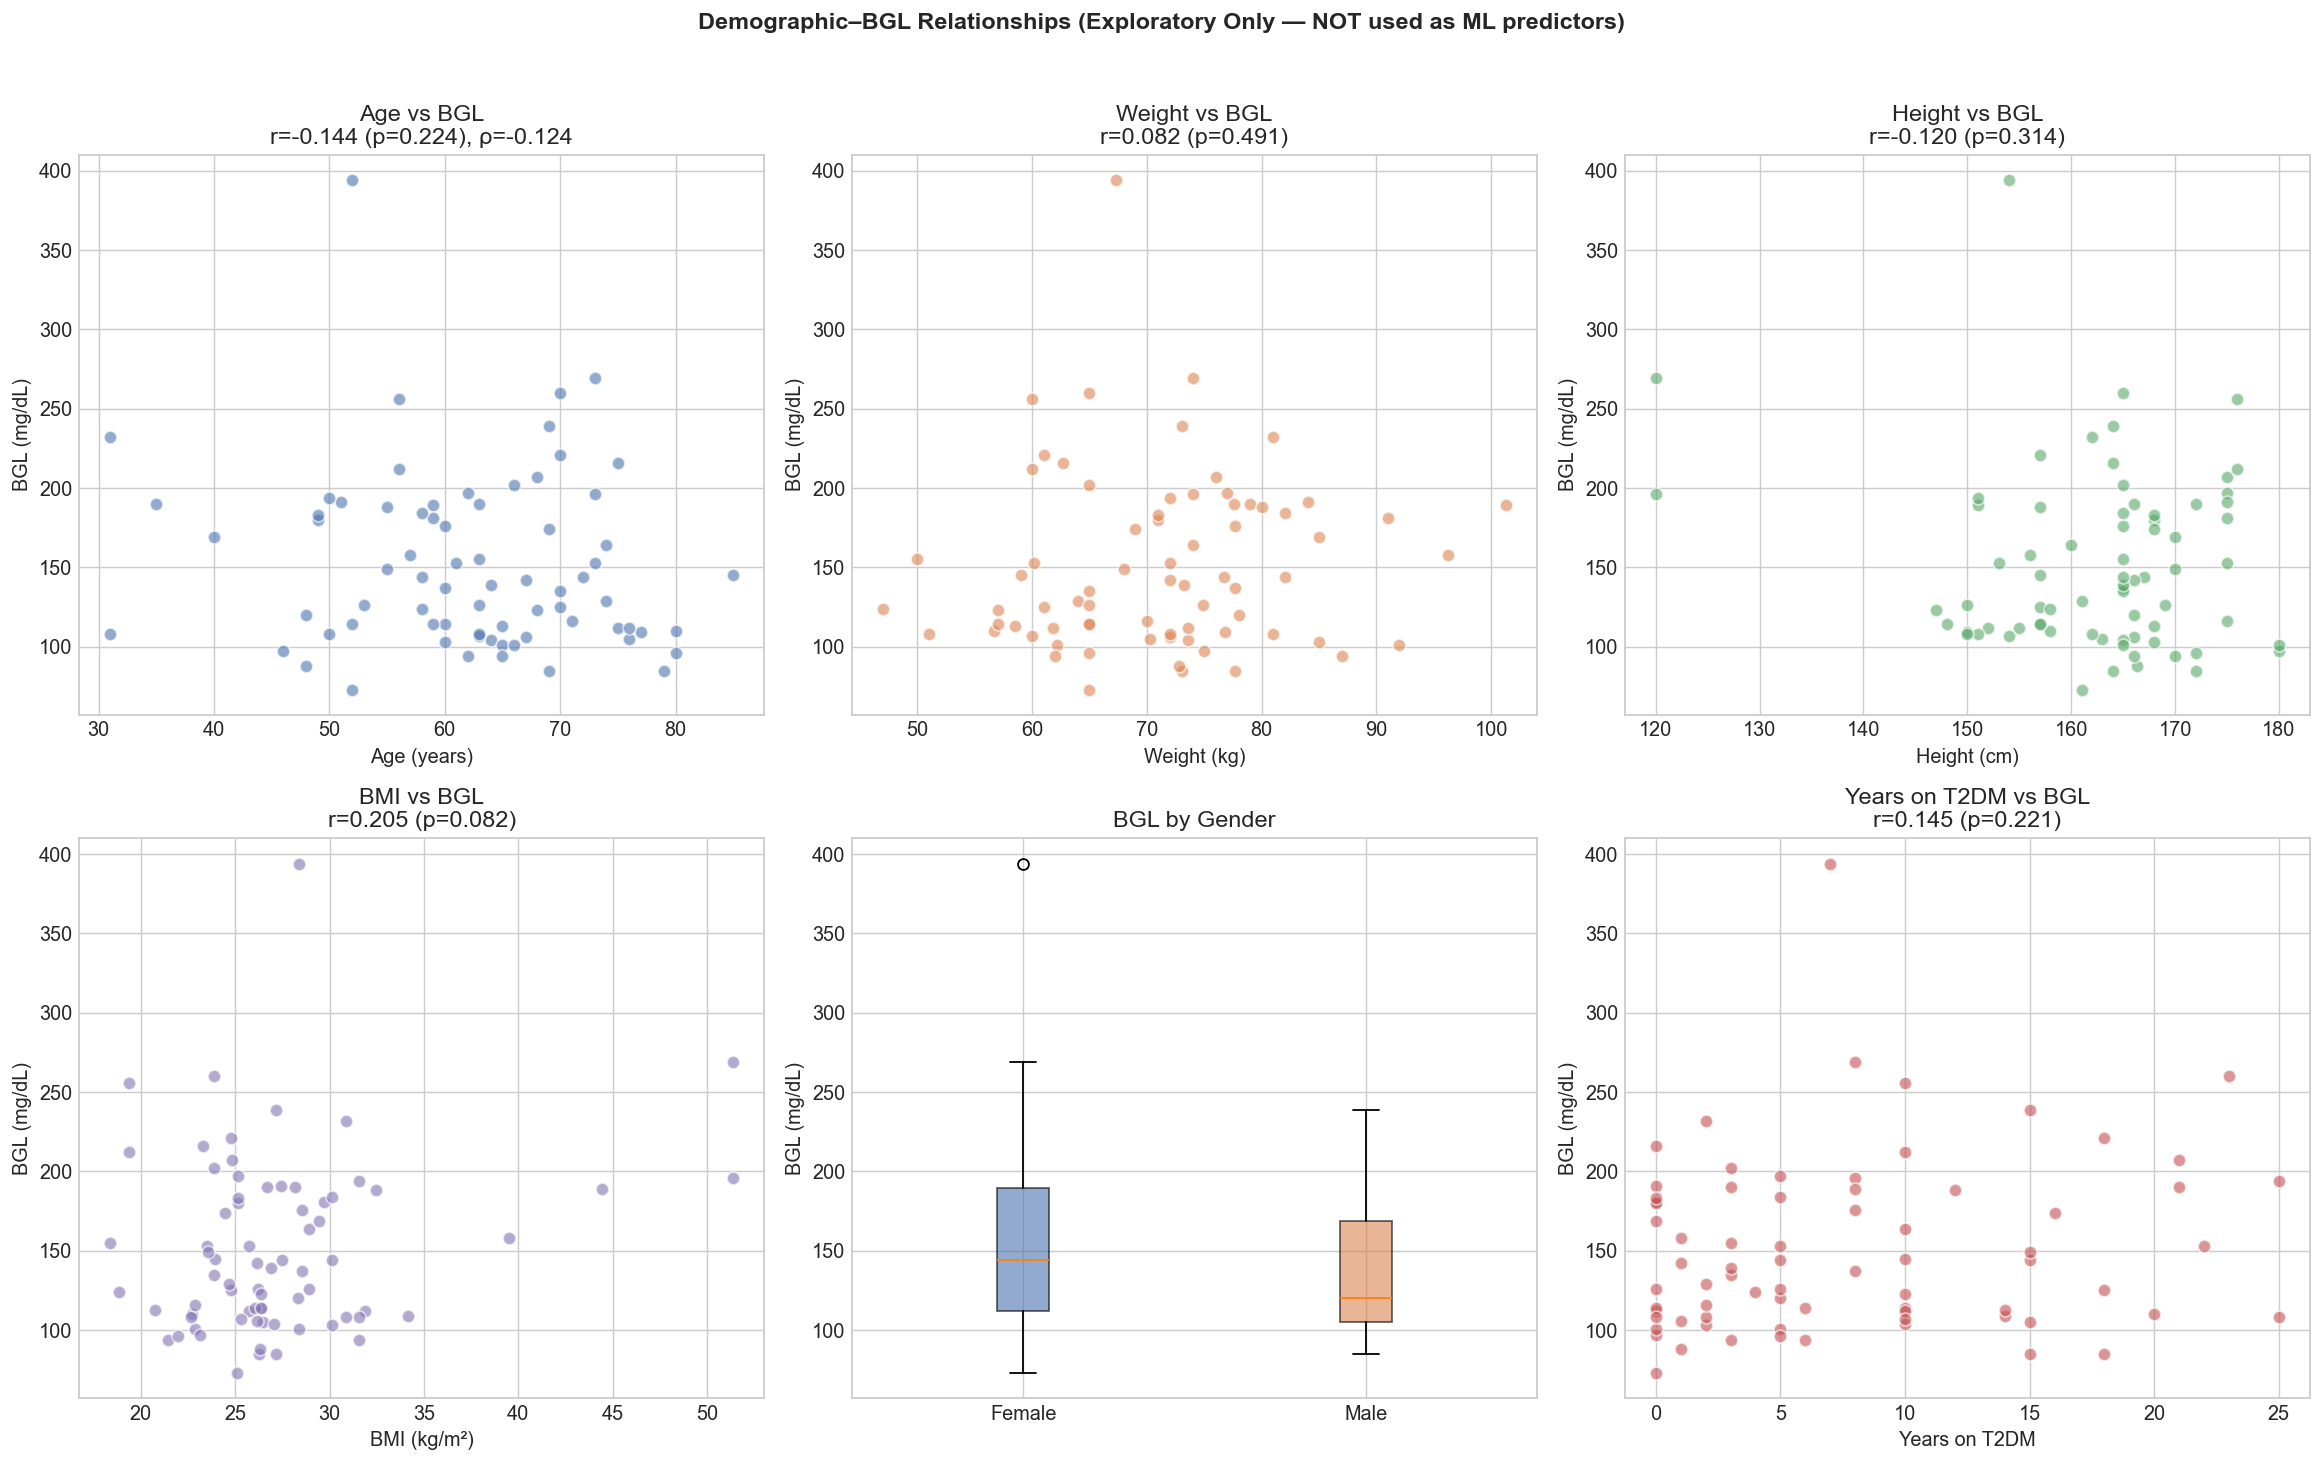


⚠ Note: These demographic variables are analysed descriptively only.
  They are NOT used as predictors in the PPG-only ML models.


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

demo_bgl = demo_participant.copy()
demo_bgl_rec = demo_df.copy()  # recording-level for BGL

# Age vs BGL
ax = axes[0, 0]
ax.scatter(demo_bgl_rec['age'], demo_bgl_rec['bgl_mgdl'], alpha=0.6,
           color='#4C72B0', edgecolor='white', s=50)
r_age, p_age = pearsonr(demo_bgl_rec['age'].dropna(), demo_bgl_rec['bgl_mgdl'])
rho_age, p_rho_age = spearmanr(demo_bgl_rec['age'].dropna(), demo_bgl_rec['bgl_mgdl'])
ax.set_xlabel('Age (years)')
ax.set_ylabel('BGL (mg/dL)')
ax.set_title(f'Age vs BGL\nr={r_age:.3f} (p={p_age:.3f}), ρ={rho_age:.3f}')

# Weight vs BGL
ax = axes[0, 1]
mask_w = demo_bgl_rec['weight_kg'].notna()
ax.scatter(demo_bgl_rec.loc[mask_w, 'weight_kg'], demo_bgl_rec.loc[mask_w, 'bgl_mgdl'],
           alpha=0.6, color='#DD8452', edgecolor='white', s=50)
if mask_w.sum() > 3:
    r_w, p_w = pearsonr(demo_bgl_rec.loc[mask_w, 'weight_kg'], demo_bgl_rec.loc[mask_w, 'bgl_mgdl'])
    ax.set_title(f'Weight vs BGL\nr={r_w:.3f} (p={p_w:.3f})')
else:
    ax.set_title('Weight vs BGL\n(insufficient data)')
ax.set_xlabel('Weight (kg)')
ax.set_ylabel('BGL (mg/dL)')

# Height vs BGL
ax = axes[0, 2]
mask_h = demo_bgl_rec['height_cm'].notna()
ax.scatter(demo_bgl_rec.loc[mask_h, 'height_cm'], demo_bgl_rec.loc[mask_h, 'bgl_mgdl'],
           alpha=0.6, color='#55A868', edgecolor='white', s=50)
if mask_h.sum() > 3:
    r_h, p_h = pearsonr(demo_bgl_rec.loc[mask_h, 'height_cm'], demo_bgl_rec.loc[mask_h, 'bgl_mgdl'])
    ax.set_title(f'Height vs BGL\nr={r_h:.3f} (p={p_h:.3f})')
else:
    ax.set_title('Height vs BGL\n(insufficient data)')
ax.set_xlabel('Height (cm)')
ax.set_ylabel('BGL (mg/dL)')

# BMI vs BGL
ax = axes[1, 0]
mask_b = demo_bgl_rec['bmi'].notna()
ax.scatter(demo_bgl_rec.loc[mask_b, 'bmi'], demo_bgl_rec.loc[mask_b, 'bgl_mgdl'],
           alpha=0.6, color='#8172B2', edgecolor='white', s=50)
if mask_b.sum() > 3:
    r_b, p_b = pearsonr(demo_bgl_rec.loc[mask_b, 'bmi'], demo_bgl_rec.loc[mask_b, 'bgl_mgdl'])
    ax.set_title(f'BMI vs BGL\nr={r_b:.3f} (p={p_b:.3f})')
else:
    ax.set_title('BMI vs BGL\n(insufficient data)')
ax.set_xlabel('BMI (kg/m²)')
ax.set_ylabel('BGL (mg/dL)')

# Gender vs BGL
ax = axes[1, 1]
gender_data = {}
for g in demo_bgl_rec['gender'].dropna().unique():
    gender_data[g] = demo_bgl_rec[demo_bgl_rec['gender'] == g]['bgl_mgdl'].values
genders_sorted = sorted(gender_data.keys())
bp = ax.boxplot([gender_data[g] for g in genders_sorted], patch_artist=True,
                labels=genders_sorted)
colors_g = ['#4C72B0', '#DD8452', '#55A868']
for patch, color in zip(bp['boxes'], colors_g):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('BGL (mg/dL)')
ax.set_title('BGL by Gender')

# Years on T2DM vs BGL
ax = axes[1, 2]
years_data = pd.DataFrame([{'years_on_t2dm': r['demographics']['years_on_t2dm'],
                             'bgl': r['bgl']} for r in recordings])
mask_y = years_data['years_on_t2dm'].notna()
ax.scatter(years_data.loc[mask_y, 'years_on_t2dm'], years_data.loc[mask_y, 'bgl'],
           alpha=0.6, color='#C44E52', edgecolor='white', s=50)
if mask_y.sum() > 3:
    r_y, p_y = pearsonr(years_data.loc[mask_y, 'years_on_t2dm'], years_data.loc[mask_y, 'bgl'])
    ax.set_title(f'Years on T2DM vs BGL\nr={r_y:.3f} (p={p_y:.3f})')
ax.set_xlabel('Years on T2DM')
ax.set_ylabel('BGL (mg/dL)')

plt.suptitle('Demographic–BGL Relationships (Exploratory Only — NOT used as ML predictors)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig_demographics_bgl.png')
plt.show()

print("\n⚠ Note: These demographic variables are analysed descriptively only.")
print("  They are NOT used as predictors in the PPG-only ML models.")

## 8b. Multi-Recording Participant PPG+BGL Comparison

For participants with more than one recording, we compare how both PPG signals and BGL values change across sessions.

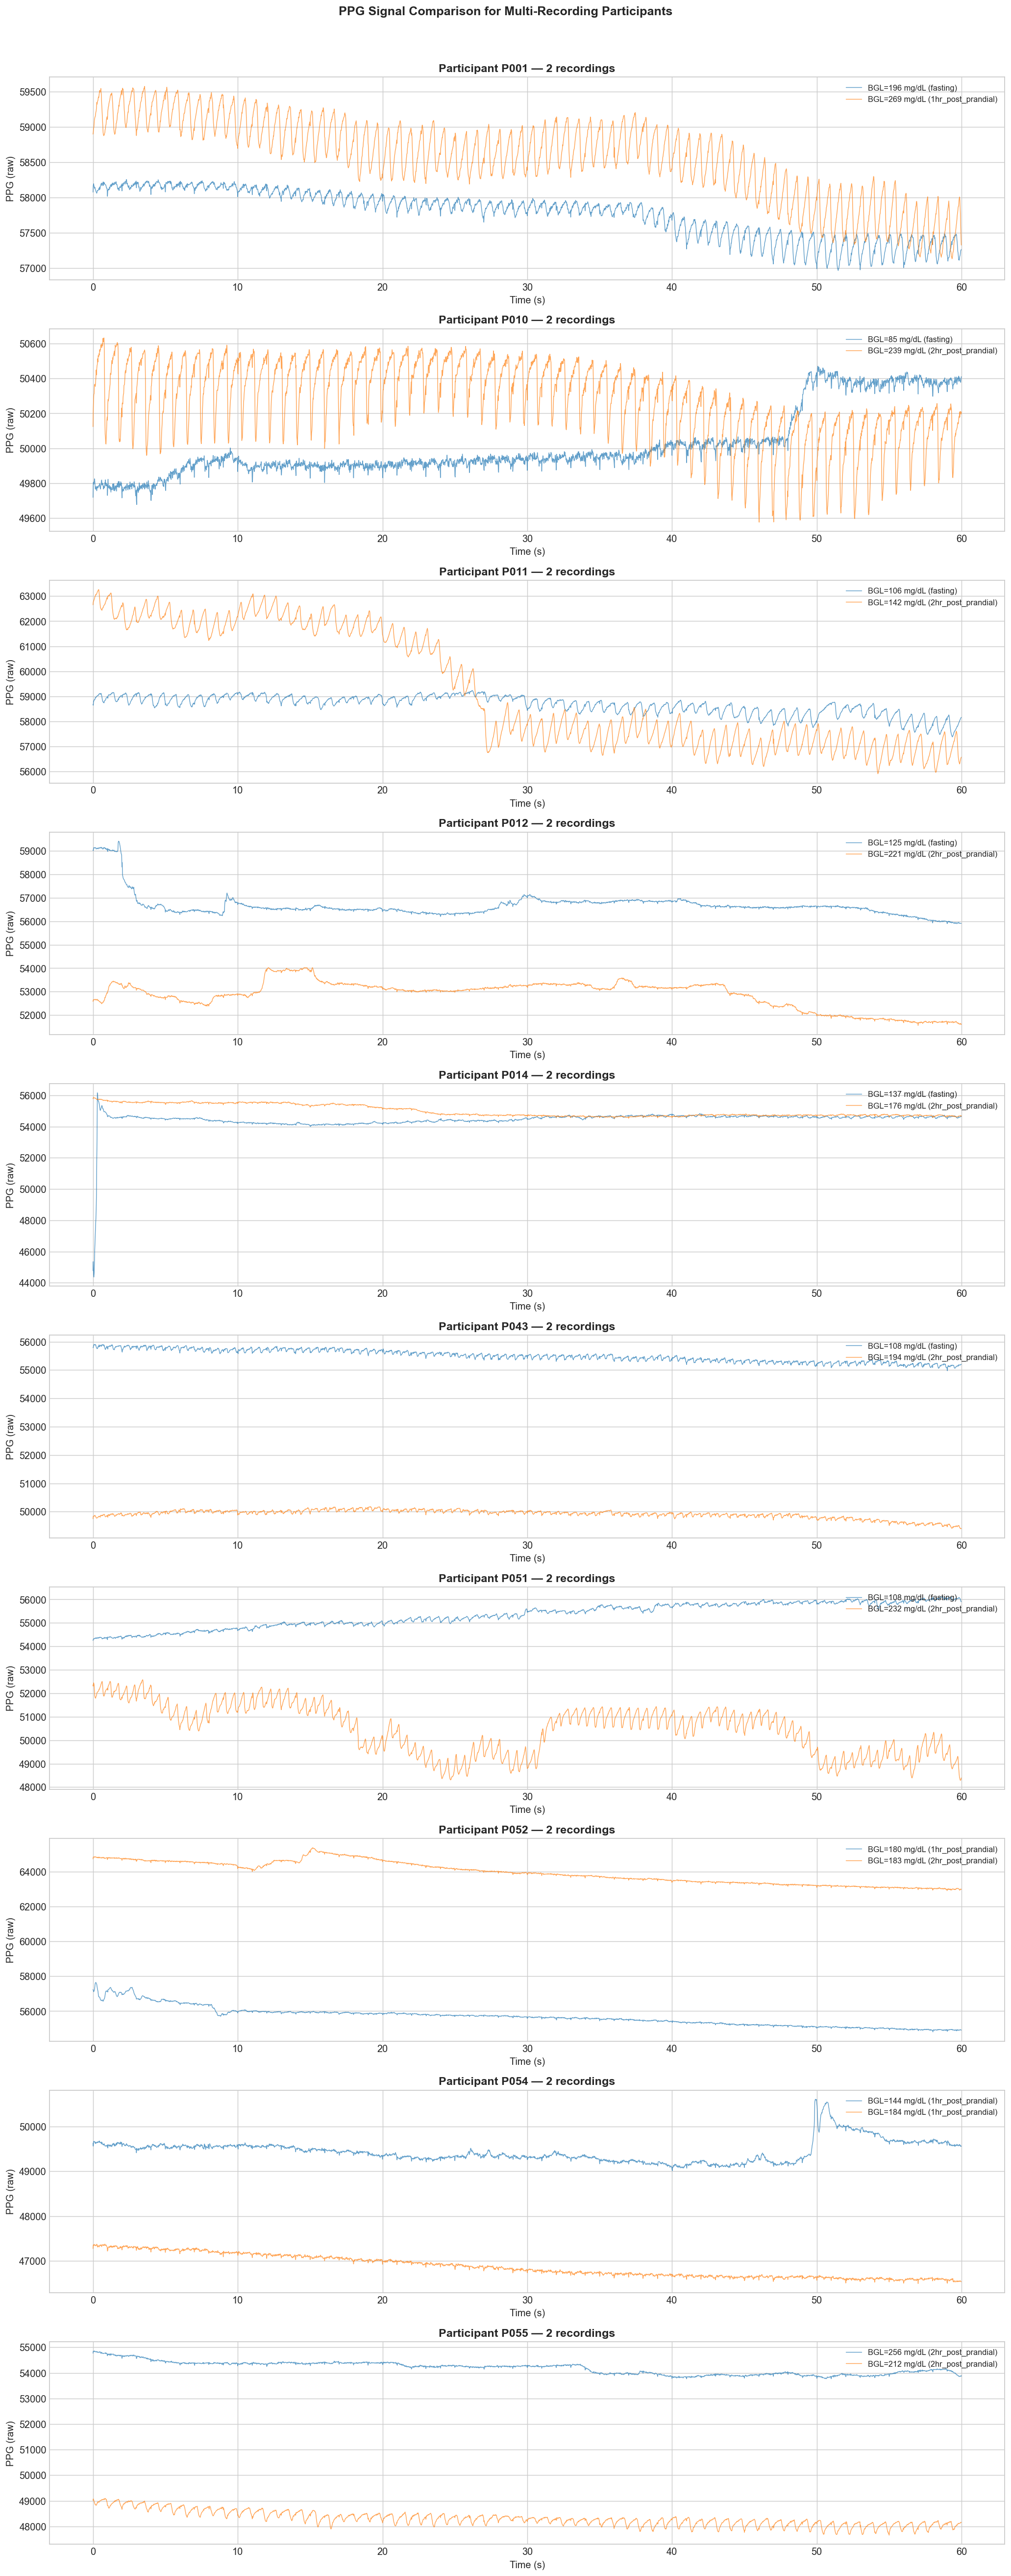


=== Multi-Recording Participant Summary ===

  P001:
    Session 1: fasting, BGL=196 mg/dL, PPG mean=57774, PPG SD=331.3
    Session 2: 1hr_post_prandial, BGL=269 mg/dL, PPG mean=58572, PPG SD=563.6
    → BGL range: 73 mg/dL, PPG mean shift: 798

  P010:
    Session 1: fasting, BGL=85 mg/dL, PPG mean=50014, PPG SD=190.5
    Session 2: 2hr_post_prandial, BGL=239 mg/dL, PPG mean=50280, PPG SD=221.8
    → BGL range: 154 mg/dL, PPG mean shift: 267

  P011:
    Session 1: fasting, BGL=106 mg/dL, PPG mean=58653, PPG SD=375.5
    Session 2: 2hr_post_prandial, BGL=142 mg/dL, PPG mean=59270, PPG SD=2344.1
    → BGL range: 36 mg/dL, PPG mean shift: 618

  P012:
    Session 1: fasting, BGL=125 mg/dL, PPG mean=56671, PPG SD=518.3
    Session 2: 2hr_post_prandial, BGL=221 mg/dL, PPG mean=52878, PPG SD=594.4
    → BGL range: 96 mg/dL, PPG mean shift: 3793

  P014:
    Session 1: fasting, BGL=137 mg/dL, PPG mean=54462, PPG SD=584.3
    Session 2: 2hr_post_prandial, BGL=176 mg/dL, PPG mean=54997, PPG

In [11]:
multi_rec_pids = [pid for pid, count in recs_per_participant.items() if count > 1]

if len(multi_rec_pids) > 0:
    n_multi = len(multi_rec_pids)
    fig, axes = plt.subplots(n_multi, 1, figsize=(16, 4 * n_multi))
    if n_multi == 1:
        axes = [axes]

    for ax_idx, pid in enumerate(sorted(multi_rec_pids)):
        ax = axes[ax_idx]
        pid_recs = [r for r in recordings if r['participant_id'] == pid]

        for i, rec in enumerate(pid_recs):
            ppg = rec['ppg_raw_full']
            # Trim to analysis window
            if len(ppg) >= EXPECTED_TOTAL_SAMPLES:
                ppg_trimmed = ppg[TRIM_SAMPLES:-TRIM_SAMPLES]
            else:
                ppg_trimmed = ppg

            time_axis = np.arange(len(ppg_trimmed)) / SAMPLING_RATE
            label = f"BGL={rec['bgl']:.0f} mg/dL ({rec['demographics']['session_kind']})"
            ax.plot(time_axis, ppg_trimmed, alpha=0.7, label=label, lw=0.8)

        ax.set_title(f"Participant {pid} — {len(pid_recs)} recordings", fontweight='bold')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('PPG (raw)')
        ax.legend(fontsize=9, loc='upper right')

    plt.suptitle('PPG Signal Comparison for Multi-Recording Participants',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('figures/fig_multi_rec_comparison.png')
    plt.show()

    # Statistical comparison
    print("\n=== Multi-Recording Participant Summary ===")
    for pid in sorted(multi_rec_pids):
        pid_recs = [r for r in recordings if r['participant_id'] == pid]
        bgls = [r['bgl'] for r in pid_recs]
        kinds = [r['demographics']['session_kind'] for r in pid_recs]
        ppg_means = [np.mean(r['ppg_raw_full'][TRIM_SAMPLES:-TRIM_SAMPLES]) for r in pid_recs]
        ppg_stds = [np.std(r['ppg_raw_full'][TRIM_SAMPLES:-TRIM_SAMPLES]) for r in pid_recs]
        print(f"\n  {pid}:")
        for i, rec in enumerate(pid_recs):
            print(f"    Session {i+1}: {kinds[i]}, BGL={bgls[i]:.0f} mg/dL, "
                  f"PPG mean={ppg_means[i]:.0f}, PPG SD={ppg_stds[i]:.1f}")
        if len(bgls) > 1:
            bgl_change = max(bgls) - min(bgls)
            ppg_mean_change = max(ppg_means) - min(ppg_means)
            print(f"    → BGL range: {bgl_change:.0f} mg/dL, PPG mean shift: {ppg_mean_change:.0f}")
else:
    print("No participants with multiple recordings found.")

---
## 9. PPG Signal Quality Analysis

Load, trim, and validate all PPG signals.

In [12]:
# Parse and trim PPG signals
for r in recordings:
    ppg_full = r['ppg_raw_full']
    if len(ppg_full) >= EXPECTED_TOTAL_SAMPLES:
        r['ppg_analysis'] = ppg_full[TRIM_SAMPLES:-TRIM_SAMPLES].copy()
    elif len(ppg_full) > 2 * TRIM_SAMPLES:
        r['ppg_analysis'] = ppg_full[TRIM_SAMPLES:-TRIM_SAMPLES].copy()
        print(f"  ⚠ {r['recording_id'][:8]}...: unexpected length {len(ppg_full)}, "
              f"trimmed to {len(r['ppg_analysis'])}")
    else:
        r['ppg_analysis'] = ppg_full.copy()
        print(f"  ⚠ {r['recording_id'][:8]}...: too short ({len(ppg_full)}), no trimming")

# Verify
analysis_lengths = [len(r['ppg_analysis']) for r in recordings]
print(f"\nAnalysis window lengths:")
print(f"  All = {ANALYSIS_SAMPLES}: {sum(1 for l in analysis_lengths if l == ANALYSIS_SAMPLES)}/{len(recordings)}")
print(f"  Range: {min(analysis_lengths)} – {max(analysis_lengths)} samples")


Analysis window lengths:
  All = 3000: 73/73
  Range: 3000 – 3000 samples


## 10. Raw PPG Visualisation

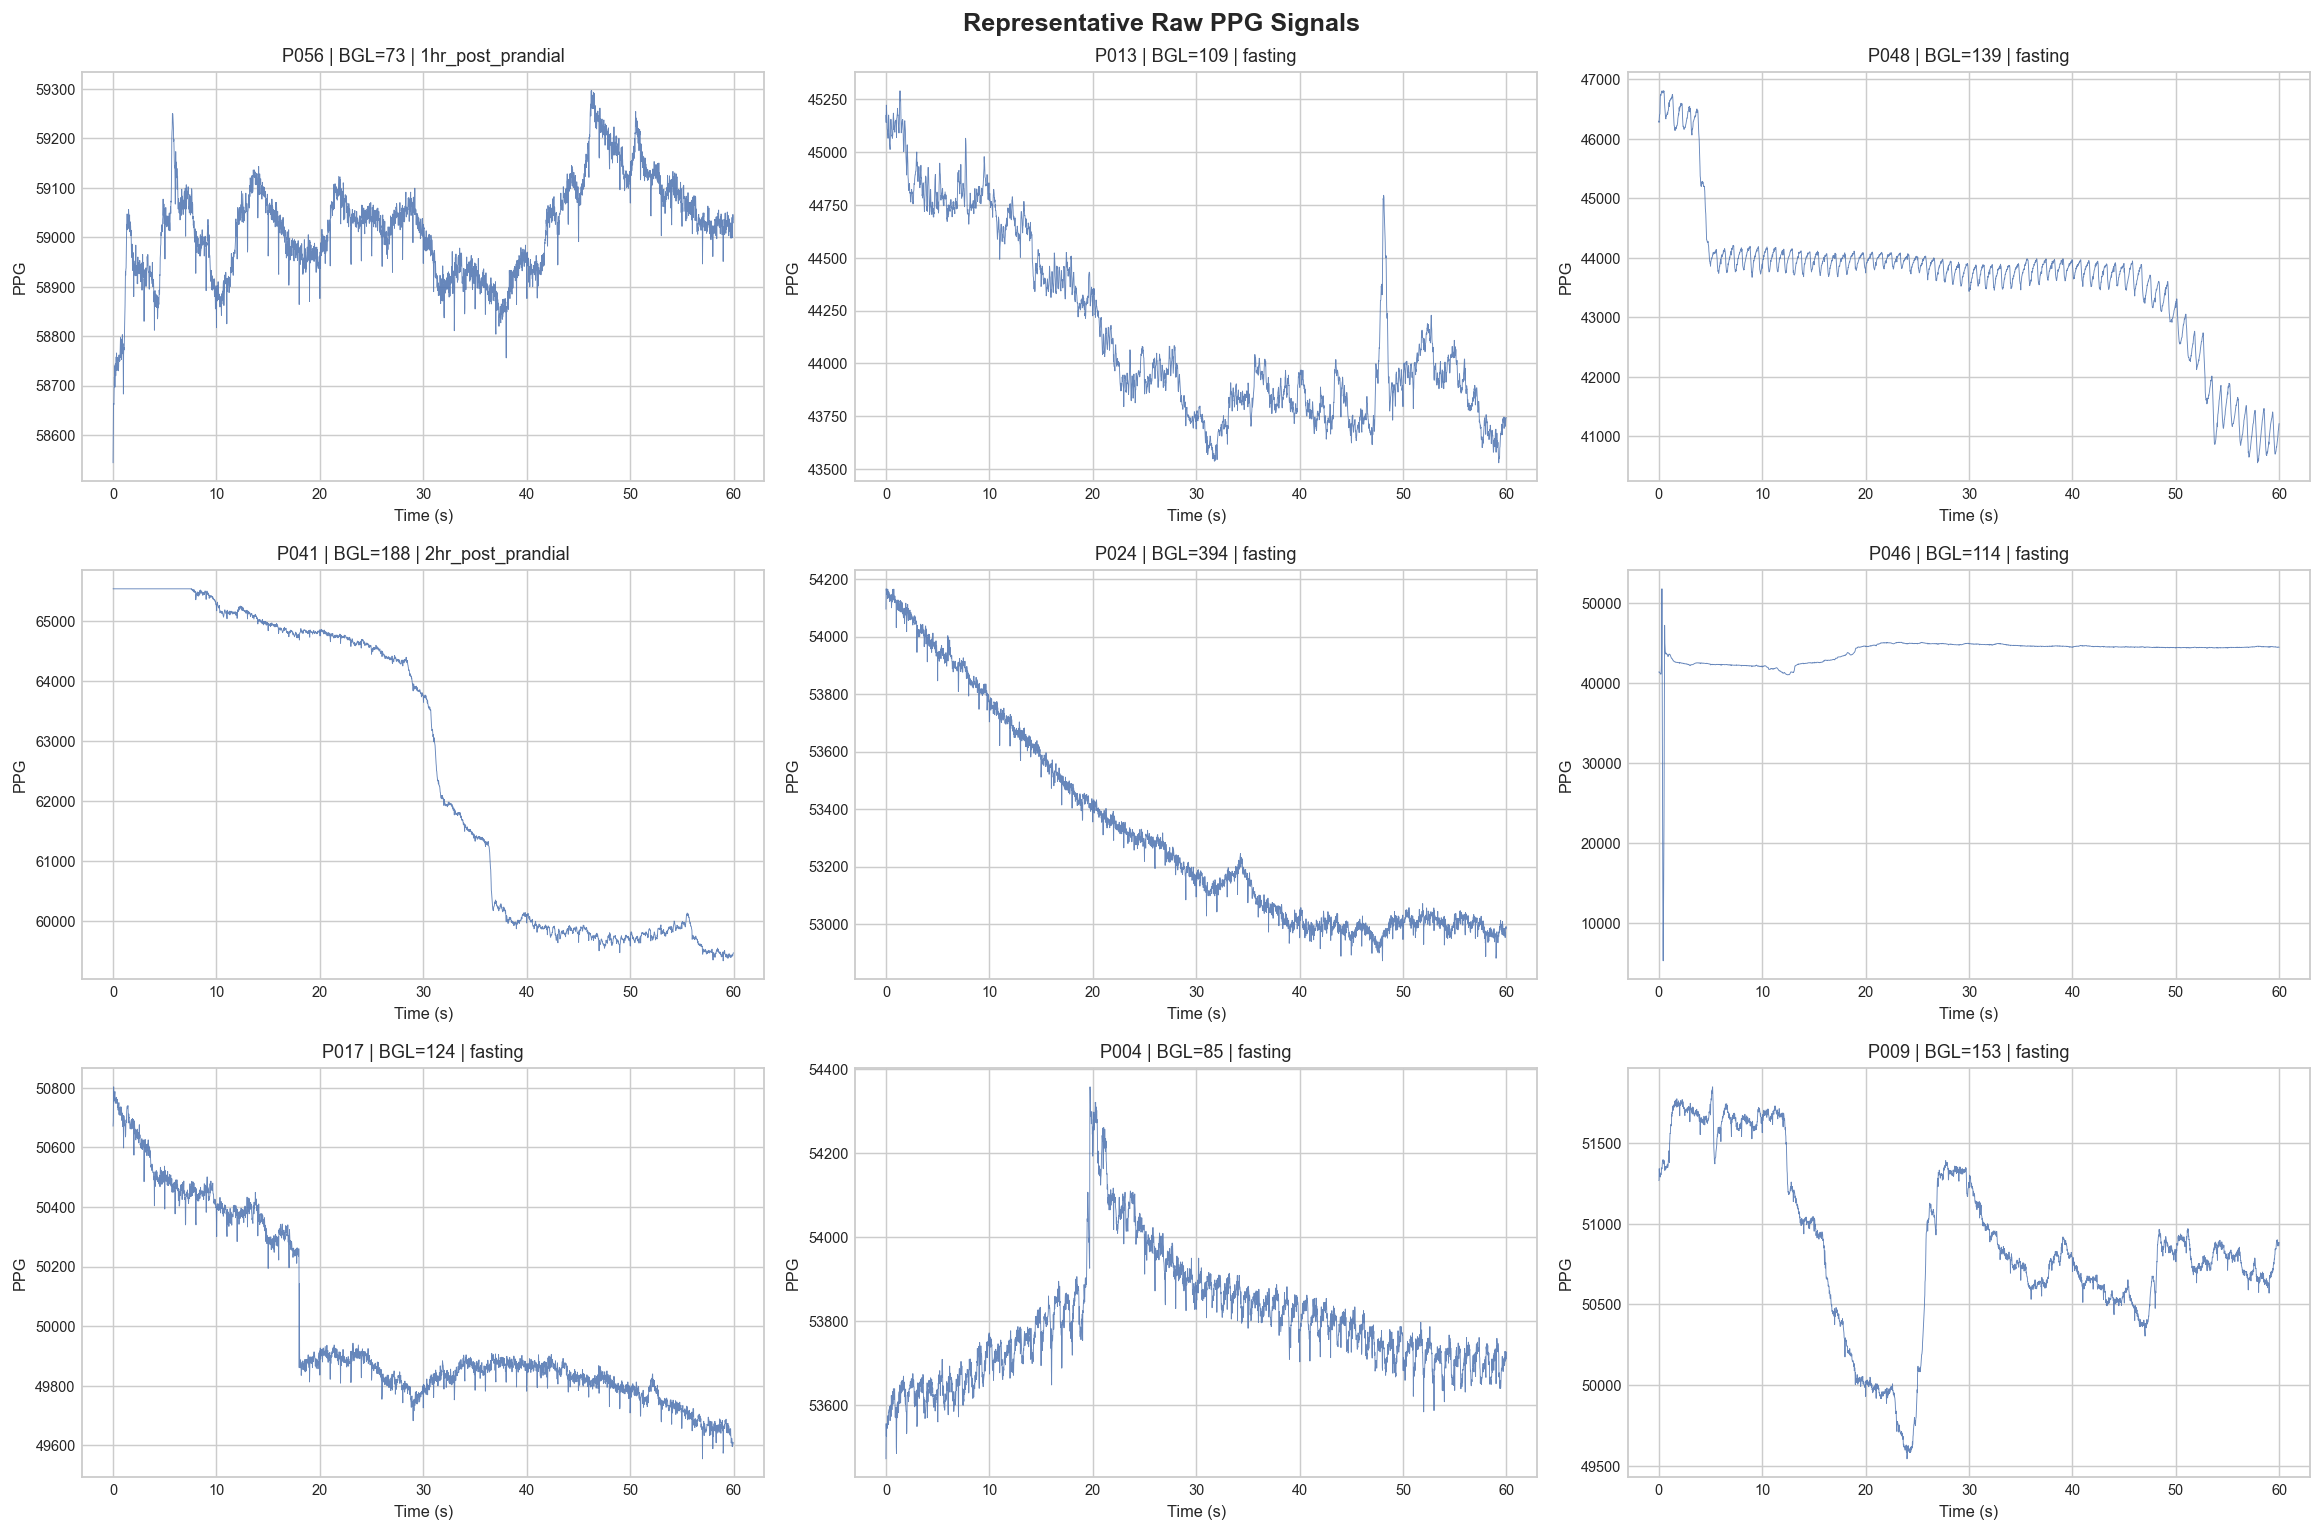

In [13]:
# Plot representative PPG signals
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

# Select diverse examples
bgl_sorted_idx = np.argsort([r['bgl'] for r in recordings])
indices_to_show = [
    bgl_sorted_idx[0],          # lowest BGL
    bgl_sorted_idx[len(bgl_sorted_idx)//4],    # Q1
    bgl_sorted_idx[len(bgl_sorted_idx)//2],    # median
    bgl_sorted_idx[3*len(bgl_sorted_idx)//4],  # Q3
    bgl_sorted_idx[-1],        # highest BGL
]
# Add some random ones
np.random.seed(RANDOM_STATE)
remaining = [i for i in range(len(recordings)) if i not in indices_to_show]
indices_to_show.extend(np.random.choice(remaining, min(4, len(remaining)), replace=False))
indices_to_show = indices_to_show[:9]

for ax_idx, rec_idx in enumerate(indices_to_show):
    ax = axes[ax_idx // 3, ax_idx % 3]
    r = recordings[rec_idx]
    ppg = r['ppg_analysis']
    t = np.arange(len(ppg)) / SAMPLING_RATE

    ax.plot(t, ppg, color='#4C72B0', lw=0.5, alpha=0.85)
    ax.set_title(f"{r['participant_id']} | BGL={r['bgl']:.0f} | "
                 f"{r['demographics']['session_kind']}", fontsize=10)
    ax.set_xlabel('Time (s)', fontsize=9)
    ax.set_ylabel('PPG', fontsize=9)
    ax.tick_params(labelsize=8)

plt.suptitle('Representative Raw PPG Signals', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig5_raw_ppg.png')
plt.show()

## 11. PPG Preprocessing Pipeline

**Pipeline:**
1. Detrending (linear)
2. Band-pass filter: Butterworth 4th-order, 0.5–8 Hz (zero-phase)
3. Min–max normalisation

**Justification:** The 0.5–8 Hz passband preserves the fundamental PPG frequency
(~0.8–2 Hz for 48–120 bpm) and its harmonics, while removing baseline drift (<0.5 Hz)
and high-frequency noise (>8 Hz). At 50 Hz sampling, the Nyquist frequency is 25 Hz,
making 8 Hz a conservative upper cutoff (Allen, 2007; Elgendi, 2012).

In [14]:
from scipy.signal import butter, filtfilt, detrend

def preprocess_ppg(ppg_raw, fs=SAMPLING_RATE, lowcut=0.5, highcut=8.0, order=4):
    """
    Preprocess PPG signal with physiologically justified pipeline.

    Parameters
    ----------
    ppg_raw : np.ndarray
        Raw PPG signal
    fs : int
        Sampling frequency in Hz
    lowcut, highcut : float
        Bandpass filter cutoff frequencies in Hz
    order : int
        Butterworth filter order

    Returns
    -------
    dict with 'detrended', 'filtered', 'normalised' signals
    """
    # Step 1: Detrend (remove linear baseline drift)
    detrended = detrend(ppg_raw, type='linear')

    # Step 2: Bandpass filter (zero-phase Butterworth)
    nyq = fs / 2.0
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    filtered = filtfilt(b, a, detrended)

    # Step 3: Min-max normalisation
    fmin, fmax = filtered.min(), filtered.max()
    if fmax - fmin > 1e-10:
        normalised = (filtered - fmin) / (fmax - fmin)
    else:
        normalised = np.zeros_like(filtered)

    return {
        'detrended': detrended,
        'filtered': filtered,
        'normalised': normalised,
    }

# Apply preprocessing to all recordings
for r in recordings:
    result = preprocess_ppg(r['ppg_analysis'])
    r['ppg_detrended'] = result['detrended']
    r['ppg_filtered'] = result['filtered']
    r['ppg_clean'] = result['normalised']

print(f"Preprocessing applied to {len(recordings)} recordings.")
print(f"  Filter: Butterworth order-4 bandpass, 0.5–8 Hz, zero-phase")
print(f"  Normalisation: min-max per recording")

Preprocessing applied to 73 recordings.
  Filter: Butterworth order-4 bandpass, 0.5–8 Hz, zero-phase
  Normalisation: min-max per recording


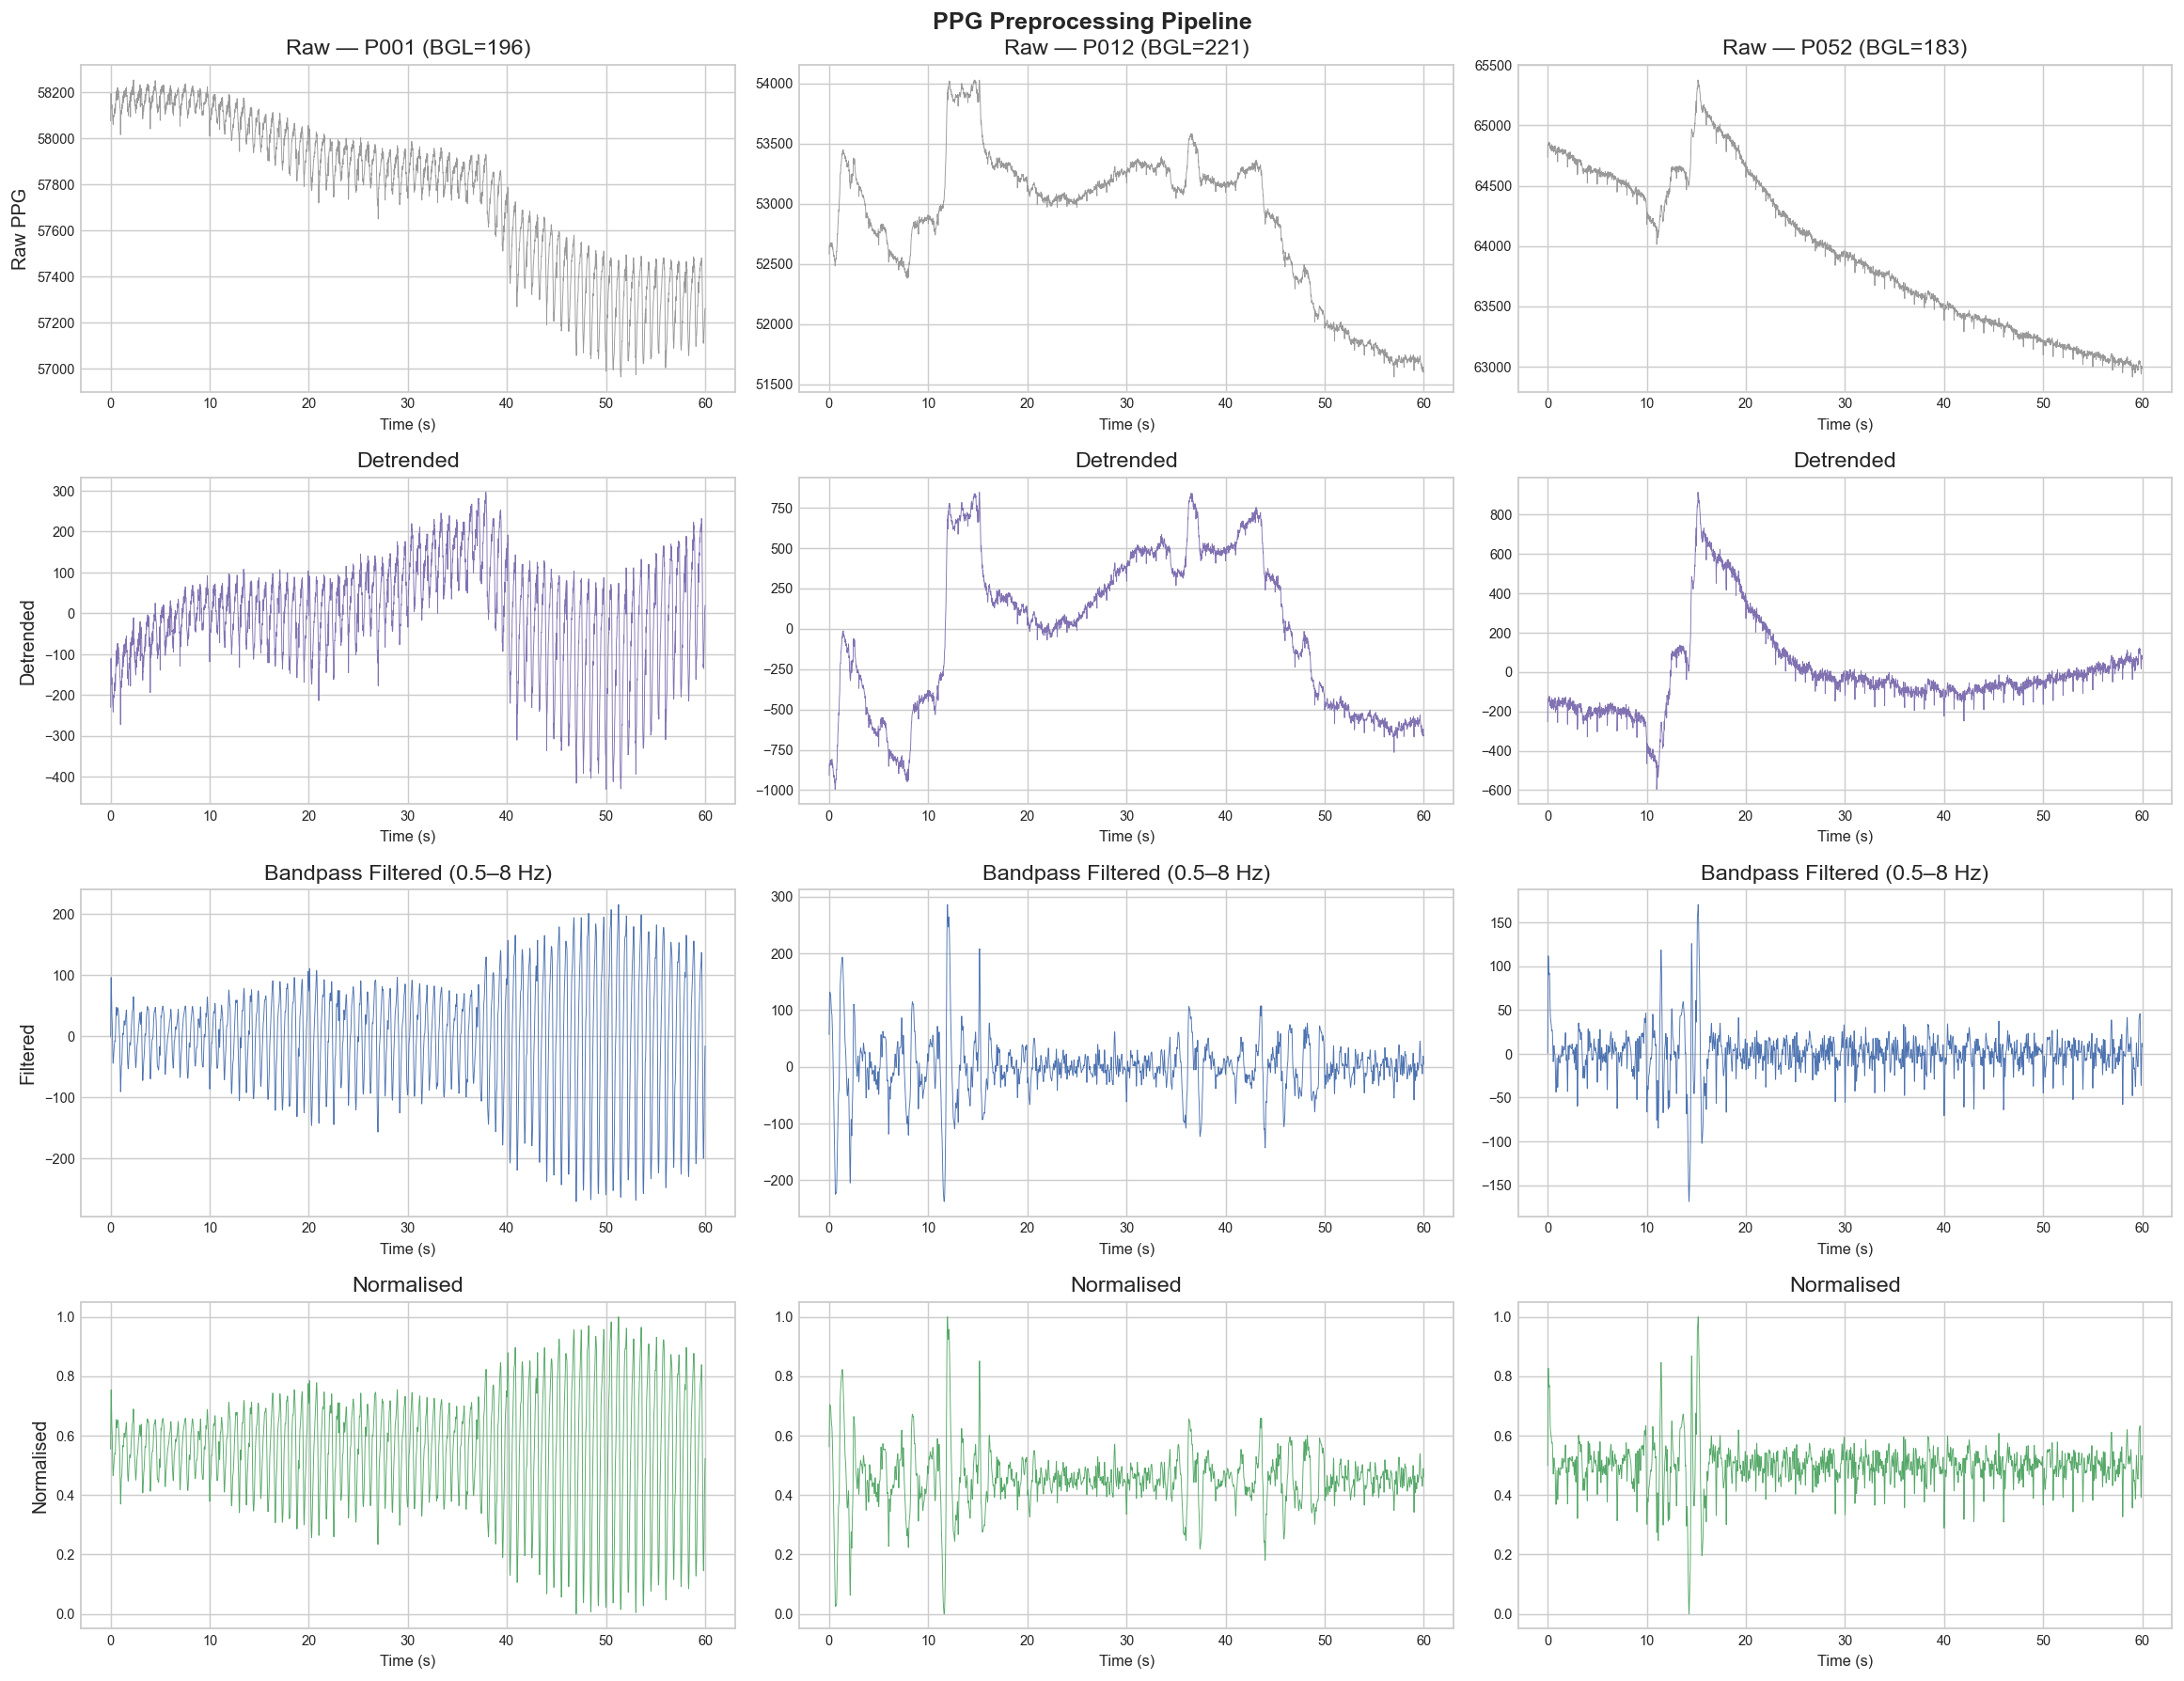

In [15]:
# Show preprocessing pipeline on representative recordings
fig, axes = plt.subplots(4, 3, figsize=(18, 14))
example_indices = [0, len(recordings)//2, -1]

for col, idx in enumerate(example_indices):
    r = recordings[idx]
    t = np.arange(len(r['ppg_analysis'])) / SAMPLING_RATE

    axes[0, col].plot(t, r['ppg_analysis'], color='#999999', lw=0.5)
    axes[0, col].set_title(f"Raw — {r['participant_id']} (BGL={r['bgl']:.0f})")

    axes[1, col].plot(t, r['ppg_detrended'], color='#8172B2', lw=0.5)
    axes[1, col].set_title('Detrended')

    axes[2, col].plot(t, r['ppg_filtered'], color='#4C72B0', lw=0.5)
    axes[2, col].set_title('Bandpass Filtered (0.5–8 Hz)')

    axes[3, col].plot(t, r['ppg_clean'], color='#55A868', lw=0.5)
    axes[3, col].set_title('Normalised')

for ax_row in axes:
    for ax in ax_row:
        ax.set_xlabel('Time (s)', fontsize=9)
        ax.tick_params(labelsize=8)

axes[0, 0].set_ylabel('Raw PPG')
axes[1, 0].set_ylabel('Detrended')
axes[2, 0].set_ylabel('Filtered')
axes[3, 0].set_ylabel('Normalised')

plt.suptitle('PPG Preprocessing Pipeline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig6_ppg_preprocessing.png')
plt.show()

## 12. PPG Signal Quality Metrics

In [16]:
quality_records = []
for r in recordings:
    ppg = r['ppg_clean']
    ppg_filt = r['ppg_filtered']
    ppg_raw = r['ppg_analysis']

    # Amplitude metrics
    amp_range = np.ptp(ppg_filt)
    amp_std = np.std(ppg_filt)

    # SNR estimate: signal power / noise power
    # Use filtered signal as "signal", difference from raw as "noise" proxy
    raw_detrended = detrend(ppg_raw.astype(float), type='linear')
    noise_est = raw_detrended - ppg_filt
    sig_power = np.mean(ppg_filt ** 2)
    noise_power = np.mean(noise_est ** 2)
    snr_db = 10 * np.log10(sig_power / (noise_power + 1e-12))

    # Pulse detection for quality assessment
    try:
        ppg_nk_clean = nk.ppg_clean(ppg_raw, sampling_rate=SAMPLING_RATE, method='elgendi')
        peaks_info = nk.ppg_findpeaks(ppg_nk_clean, sampling_rate=SAMPLING_RATE, method='elgendi')
        peaks = peaks_info['PPG_Peaks']
        n_peaks = len(peaks)

        if n_peaks > 1:
            ipi = np.diff(peaks) / SAMPLING_RATE  # inter-pulse interval in seconds
            pulse_rate = 60.0 / np.mean(ipi)
            pr_plausible = 40 <= pulse_rate <= 180
        else:
            pulse_rate = np.nan
            ipi = np.array([])
            pr_plausible = False
    except Exception:
        n_peaks = 0
        pulse_rate = np.nan
        ipi = np.array([])
        pr_plausible = False

    # Quality flags
    quality_flags = []
    if snr_db < 5:
        quality_flags.append('low_SNR')
    if n_peaks < 30:
        quality_flags.append('few_peaks')
    if not pr_plausible:
        quality_flags.append('implausible_HR')
    if amp_range < np.median([np.ptp(rec['ppg_filtered']) for rec in recordings]) * 0.1:
        quality_flags.append('low_amplitude')

    quality_records.append({
        'recording_id': r['recording_id'][:12],
        'participant_id': r['participant_id'],
        'bgl': r['bgl'],
        'amplitude_range': amp_range,
        'amplitude_sd': amp_std,
        'snr_db': snr_db,
        'n_peaks_detected': n_peaks,
        'pulse_rate_bpm': pulse_rate,
        'pulse_rate_plausible': pr_plausible,
        'quality_flags': '; '.join(quality_flags) if quality_flags else 'OK',
    })

    # Store peaks for later use
    r['peaks'] = peaks if n_peaks > 0 else np.array([])
    r['pulse_rate'] = pulse_rate
    r['n_peaks'] = n_peaks
    r['snr_db'] = snr_db

quality_df = pd.DataFrame(quality_records)
print("=== TABLE 3: PPG Signal Quality Summary ===")
display(quality_df.describe().round(2))

flagged = quality_df[quality_df['quality_flags'] != 'OK']
print(f"\nFlagged recordings: {len(flagged)}/{len(quality_df)}")
if len(flagged) > 0:
    display(flagged[['recording_id', 'participant_id', 'bgl', 'n_peaks_detected',
                      'pulse_rate_bpm', 'snr_db', 'quality_flags']])

quality_df.to_csv('results/signal_quality.csv', index=False)

=== TABLE 3: PPG Signal Quality Summary ===


,bgl,amplitude_range,amplitude_sd,snr_db,n_peaks_detected,pulse_rate_bpm
count,73.00,73.00,73.00,73.00,73.00,73.00
mean,151.48,1166.35,91.26,-9.75,75.18,76.19
std,55.16,4639.56,172.86,7.70,16.32,15.99
min,73.00,101.51,12.32,-24.79,6.00,16.23
25%,109.00,179.84,24.56,-16.26,69.00,69.98
50%,139.00,405.29,46.29,-11.20,76.00,76.95
75%,188.00,930.36,82.19,-3.39,82.00,83.88
max,394.00,39538.63,1386.53,4.75,105.00,106.34



Flagged recordings: 73/73


,recording_id,participant_id,bgl,n_peaks_detected,pulse_rate_bpm,snr_db,quality_flags
0,fce4b7a2-b3d,P001,196.0,80,80.284553,0.692342,low_SNR
1,07dc95d8-800,P001,269.0,79,78.867543,1.541664,low_SNR
2,2fb9eb9e-4f3,P002,190.0,74,73.986486,2.531834,low_SNR
3,1ed1c7c0-4f1,P003,110.0,71,71.696825,-7.636081,low_SNR
4,7ea8ce61-4fa,P004,85.0,70,69.979716,-13.171727,low_SNR
...,...,...,...,...,...,...,...
68,7bc01821-408,P063,149.0,77,78.296703,-14.356693,low_SNR
69,73314668-dc1,P064,260.0,74,74.540504,-7.044236,low_SNR
70,30a4d1bf-4b9,P043,194.0,95,95.528455,-8.170042,low_SNR
71,0d402595-652,P054,184.0,84,85.070038,-10.690374,low_SNR


## 13. Beat/Pulse Detection and Validation

Performing beat detection on all recordings...



Beat Detection Summary:
  Total recordings processed: 73
  Mean peaks detected: 76.5 ± 15.2
  Mean heart rate: 77.5 ± 14.9 bpm


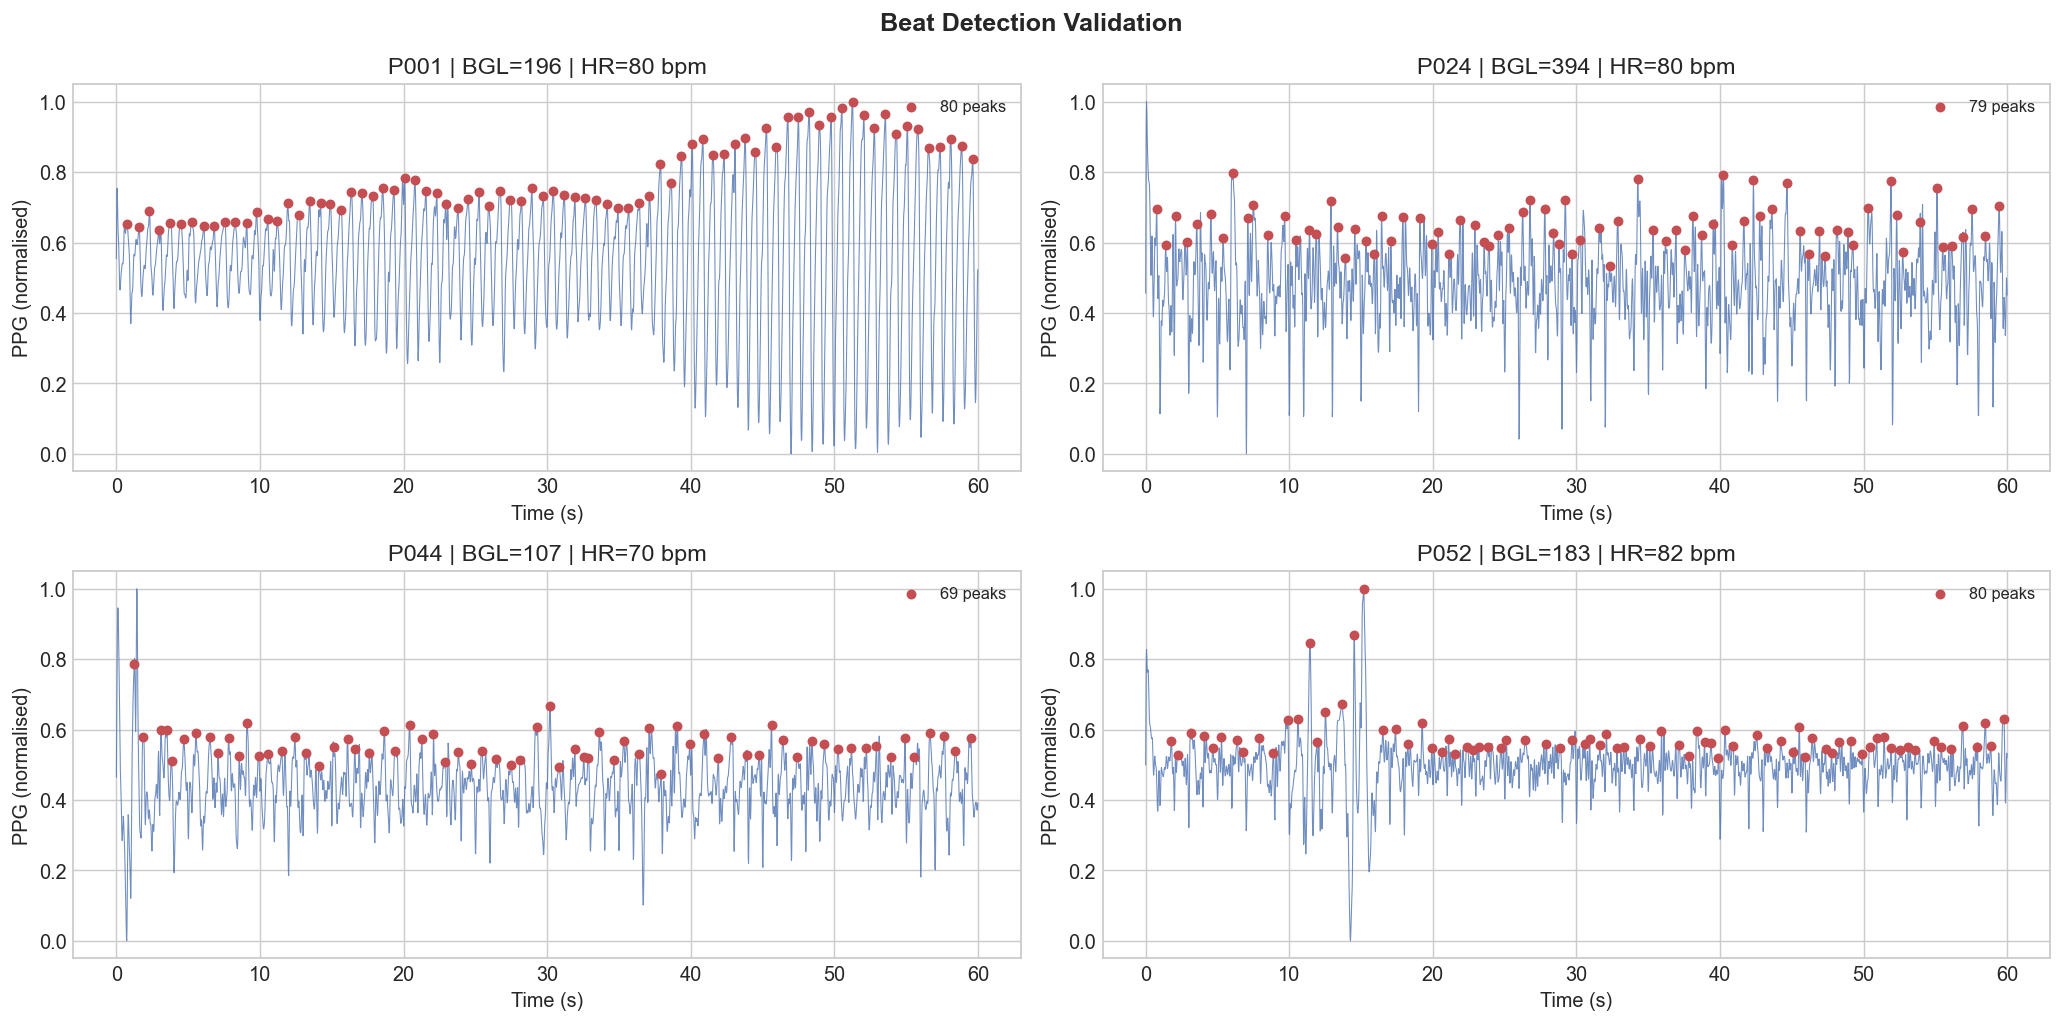

In [17]:
# Detailed beat detection using NeuroKit2
print("Performing beat detection on all recordings...")

beat_detection_summary = []
for r in recordings:
    ppg_raw = r['ppg_analysis']

    try:
        ppg_nk = nk.ppg_clean(ppg_raw, sampling_rate=SAMPLING_RATE, method='elgendi')
        signals_nk, info_nk = nk.ppg_process(ppg_nk, sampling_rate=SAMPLING_RATE, method='elgendi')
        peaks = info_nk['PPG_Peaks']
        r['nk_peaks'] = np.array(peaks)
        r['nk_clean'] = ppg_nk
        r['nk_signals'] = signals_nk

        if len(peaks) > 1:
            ipi = np.diff(peaks) / SAMPLING_RATE
            r['ipi'] = ipi
            r['mean_hr'] = 60.0 / np.mean(ipi)
            r['hr_std'] = 60.0 / np.mean(ipi) * np.std(ipi) / np.mean(ipi)
        else:
            r['ipi'] = np.array([])
            r['mean_hr'] = np.nan
            r['hr_std'] = np.nan

        beat_detection_summary.append({
            'participant_id': r['participant_id'],
            'bgl': r['bgl'],
            'n_peaks': len(peaks),
            'mean_hr': r['mean_hr'],
            'hr_std': r['hr_std'],
        })
    except Exception as e:
        r['nk_peaks'] = np.array([])
        r['nk_clean'] = ppg_raw
        r['ipi'] = np.array([])
        r['mean_hr'] = np.nan
        r['hr_std'] = np.nan
        beat_detection_summary.append({
            'participant_id': r['participant_id'],
            'bgl': r['bgl'],
            'n_peaks': 0,
            'mean_hr': np.nan,
            'hr_std': np.nan,
        })
        print(f"  ⚠ Beat detection failed for {r['participant_id']}: {e}")

beat_df = pd.DataFrame(beat_detection_summary)
print(f"\nBeat Detection Summary:")
print(f"  Total recordings processed: {len(beat_df)}")
print(f"  Mean peaks detected: {beat_df['n_peaks'].mean():.1f} ± {beat_df['n_peaks'].std():.1f}")
print(f"  Mean heart rate: {beat_df['mean_hr'].mean():.1f} ± {beat_df['mean_hr'].std():.1f} bpm")

# Visualise beat detection on a few examples
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
vis_indices = [0, len(recordings)//3, 2*len(recordings)//3, -1]

for ax_idx, rec_idx in enumerate(vis_indices):
    ax = axes[ax_idx // 2, ax_idx % 2]
    r = recordings[rec_idx]
    ppg = r['ppg_clean']
    t = np.arange(len(ppg)) / SAMPLING_RATE
    peaks = r['nk_peaks']

    ax.plot(t, ppg, color='#4C72B0', lw=0.6, alpha=0.8)
    if len(peaks) > 0:
        valid_peaks = peaks[peaks < len(ppg)]
        ax.scatter(valid_peaks / SAMPLING_RATE, ppg[valid_peaks],
                   color='#C44E52', s=20, zorder=5, label=f'{len(peaks)} peaks')
    ax.set_title(f"{r['participant_id']} | BGL={r['bgl']:.0f} | "
                 f"HR={r['mean_hr']:.0f} bpm" if not np.isnan(r['mean_hr'])
                 else f"{r['participant_id']} | BGL={r['bgl']:.0f} | HR=N/A")
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('PPG (normalised)')
    ax.legend(fontsize=9)

plt.suptitle('Beat Detection Validation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig_beat_detection.png')
plt.show()

## 13b. How PPG Changes with BGL

A key investigation: examining whether PPG signal characteristics differ
between low-BGL and high-BGL recordings.

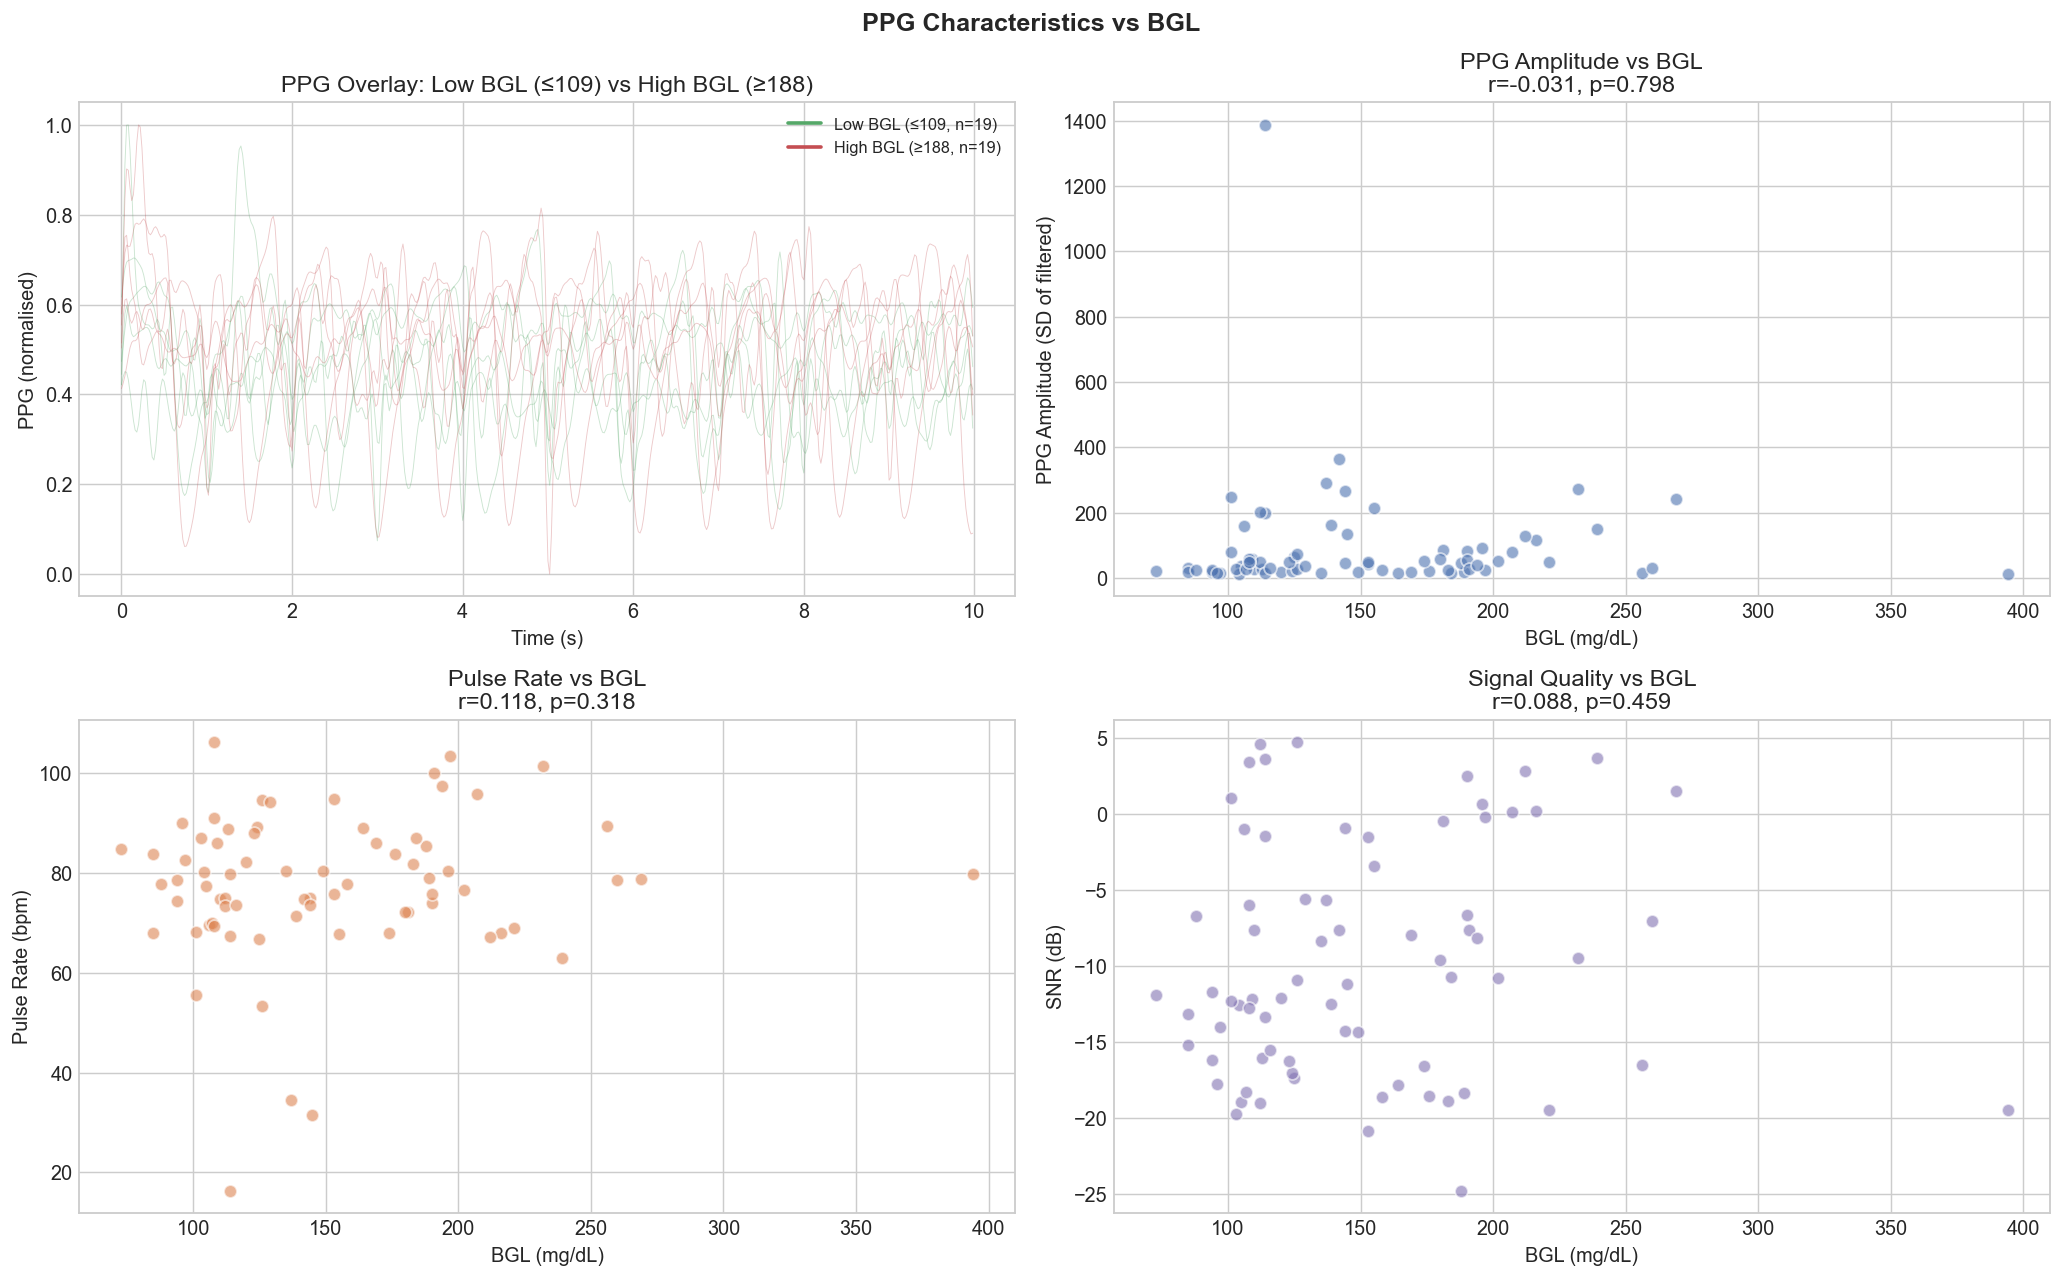

In [18]:
# Split recordings into BGL quartiles
bgl_q25, bgl_q75 = np.percentile(bgl_values, [25, 75])
low_bgl = [r for r in recordings if r['bgl'] <= bgl_q25]
high_bgl = [r for r in recordings if r['bgl'] >= bgl_q75]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Average normalised PPG waveform for low vs high BGL
ax = axes[0, 0]
# Overlay a few low-BGL and high-BGL cleaned PPG (short window)
win = slice(0, 500)  # first 10 seconds
for r in low_bgl[:5]:
    ax.plot(np.arange(500)/SAMPLING_RATE, r['ppg_clean'][win],
            color='#55A868', alpha=0.3, lw=0.5)
for r in high_bgl[:5]:
    ax.plot(np.arange(500)/SAMPLING_RATE, r['ppg_clean'][win],
            color='#C44E52', alpha=0.3, lw=0.5)
ax.set_title(f'PPG Overlay: Low BGL (≤{bgl_q25:.0f}) vs High BGL (≥{bgl_q75:.0f})')
ax.set_xlabel('Time (s)')
ax.set_ylabel('PPG (normalised)')
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], color='#55A868', lw=2, label=f'Low BGL (≤{bgl_q25:.0f}, n={len(low_bgl)})'),
    Line2D([0], [0], color='#C44E52', lw=2, label=f'High BGL (≥{bgl_q75:.0f}, n={len(high_bgl)})'),
], fontsize=9)

# PPG amplitude vs BGL
ax = axes[0, 1]
amps = [np.std(r['ppg_filtered']) for r in recordings]
bgls_plot = [r['bgl'] for r in recordings]
ax.scatter(bgls_plot, amps, alpha=0.6, color='#4C72B0', edgecolor='white', s=50)
r_corr, p_corr = pearsonr(bgls_plot, amps)
ax.set_xlabel('BGL (mg/dL)')
ax.set_ylabel('PPG Amplitude (SD of filtered)')
ax.set_title(f'PPG Amplitude vs BGL\nr={r_corr:.3f}, p={p_corr:.3f}')

# Mean HR vs BGL
ax = axes[1, 0]
hrs = [r['mean_hr'] for r in recordings if not np.isnan(r['mean_hr'])]
bgls_hr = [r['bgl'] for r in recordings if not np.isnan(r['mean_hr'])]
ax.scatter(bgls_hr, hrs, alpha=0.6, color='#DD8452', edgecolor='white', s=50)
if len(hrs) > 3:
    r_hr_bgl, p_hr_bgl = pearsonr(bgls_hr, hrs)
    ax.set_title(f'Pulse Rate vs BGL\nr={r_hr_bgl:.3f}, p={p_hr_bgl:.3f}')
ax.set_xlabel('BGL (mg/dL)')
ax.set_ylabel('Pulse Rate (bpm)')

# SNR vs BGL
ax = axes[1, 1]
snrs = [r['snr_db'] for r in recordings]
ax.scatter(bgls_plot, snrs, alpha=0.6, color='#8172B2', edgecolor='white', s=50)
r_snr, p_snr = pearsonr(bgls_plot, snrs)
ax.set_xlabel('BGL (mg/dL)')
ax.set_ylabel('SNR (dB)')
ax.set_title(f'Signal Quality vs BGL\nr={r_snr:.3f}, p={p_snr:.3f}')

plt.suptitle('PPG Characteristics vs BGL', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig_ppg_vs_bgl.png')
plt.show()

---
## 14. Literature-Informed Feature Engineering

Features are organized into families based on PPG-BGL literature:

| Feature Family | Description | Key References |
|---|---|---|
| Time-domain statistical | Mean, SD, RMS, skewness, kurtosis of PPG | Monte-Moreno (2011), Hossain et al. (2019) |
| Pulse morphology | Amplitude, duration, rise/fall time, widths | Elgendi (2012), Allen (2007) |
| Derivative (VPG/APG) | First & second derivative features, a-e waves | Takazawa et al. (1998), Imanaga et al. (1998) |
| Frequency domain | Spectral power, entropy, dominant frequency | Sel et al. (2021), Zhang et al. (2020) |
| PRV (Pulse Rate Variability) | Time/frequency HRV analogs from PPG | Gil et al. (2010), Schäfer & Vagedes (2013) |
| Nonlinear | Sample entropy, DFA, complexity measures | Richman & Moorman (2000), Peng et al. (1995) |

**Important limitations at 50 Hz:**
- Temporal resolution = 20 ms per sample
- Fine pulse morphology features (dicrotic notch timing) may be unreliable
- Frequency analysis limited to 0–25 Hz (Nyquist)
- Short 60-second windows limit frequency-domain PRV reliability

## 15–16. Time-Domain Statistical & Pulse Morphology Features

In [19]:
def extract_time_domain_features(ppg_clean, ppg_filtered):
    """Extract whole-recording statistical features from PPG signal."""
    feats = {}

    # Basic statistics on normalised signal
    feats['ppg_mean'] = np.mean(ppg_clean)
    feats['ppg_median'] = np.median(ppg_clean)
    feats['ppg_std'] = np.std(ppg_clean)
    feats['ppg_variance'] = np.var(ppg_clean)
    feats['ppg_rms'] = np.sqrt(np.mean(ppg_clean ** 2))
    feats['ppg_min'] = np.min(ppg_clean)
    feats['ppg_max'] = np.max(ppg_clean)
    feats['ppg_range'] = np.ptp(ppg_clean)
    feats['ppg_ptp'] = np.ptp(ppg_filtered)  # peak-to-peak on filtered
    feats['ppg_cv'] = np.std(ppg_clean) / (np.mean(ppg_clean) + 1e-10)
    feats['ppg_skewness'] = skew(ppg_clean)
    feats['ppg_kurtosis'] = kurtosis(ppg_clean)
    feats['ppg_p10'] = np.percentile(ppg_clean, 10)
    feats['ppg_p25'] = np.percentile(ppg_clean, 25)
    feats['ppg_p75'] = np.percentile(ppg_clean, 75)
    feats['ppg_p90'] = np.percentile(ppg_clean, 90)
    feats['ppg_iqr'] = feats['ppg_p75'] - feats['ppg_p25']
    feats['ppg_mad'] = np.median(np.abs(ppg_clean - np.median(ppg_clean)))

    # Gradient-based
    grad = np.gradient(ppg_clean)
    feats['ppg_max_slope'] = np.max(grad)
    feats['ppg_min_slope'] = np.min(grad)
    feats['ppg_mean_abs_slope'] = np.mean(np.abs(grad))
    feats['ppg_median_diff'] = np.median(np.abs(np.diff(ppg_clean)))

    # Zero-crossing rate on filtered signal
    zero_crossings = np.sum(np.diff(np.sign(ppg_filtered - np.mean(ppg_filtered))) != 0)
    feats['ppg_zcr'] = zero_crossings / len(ppg_filtered)

    return feats


def extract_pulse_morphology_features(ppg_clean, ppg_filtered, peaks, fs=SAMPLING_RATE):
    """Extract pulse/beat-level morphology features."""
    feats = {}

    if len(peaks) < 3:
        # Return NaN features if insufficient peaks
        morph_keys = [
            'pulse_amp_mean', 'pulse_amp_std', 'pulse_amp_cv',
            'pulse_dur_mean', 'pulse_dur_std', 'pulse_dur_cv',
            'pulse_rise_mean', 'pulse_fall_mean',
            'pulse_rise_ratio', 'pulse_area_mean', 'pulse_area_std',
            'pulse_width50_mean', 'pulse_width25_mean', 'pulse_width75_mean',
            'pulse_max_slope_mean', 'pulse_min_slope_mean',
            'pulse_tpeak_mean',
            'n_valid_beats', 'beat_regularity',
        ]
        return {k: np.nan for k in morph_keys}

    # Detect troughs between consecutive peaks
    troughs = []
    for i in range(len(peaks) - 1):
        p1, p2 = peaks[i], peaks[i + 1]
        if p2 - p1 > 5:
            seg = ppg_filtered[p1:p2]
            troughs.append(p1 + np.argmin(seg))

    # Extract beat-level features
    amplitudes = []
    durations = []
    rise_times = []
    fall_times = []
    areas = []
    widths_50 = []
    widths_25 = []
    widths_75 = []
    max_slopes = []
    min_slopes = []
    t_peaks = []

    for i in range(len(troughs) - 1):
        t1, t2 = troughs[i], troughs[i + 1]
        beat_len = t2 - t1
        if beat_len < 10 or beat_len > 150:
            continue

        beat = ppg_filtered[t1:t2]
        beat_norm = beat - beat.min()
        beat_max = beat_norm.max()

        if beat_max < 1e-6:
            continue

        peak_idx = np.argmax(beat_norm)
        amplitudes.append(beat_max)
        durations.append(beat_len / fs)
        rise_times.append(peak_idx / fs)
        fall_times.append((beat_len - peak_idx) / fs)
        areas.append(np.trapezoid(beat_norm) / fs)
        t_peaks.append(peak_idx / beat_len)  # relative peak position

        # Widths at different amplitudes
        for pct, storage in [(0.5, widths_50), (0.25, widths_25), (0.75, widths_75)]:
            threshold = beat_max * pct
            above = beat_norm >= threshold
            if np.any(above):
                indices = np.where(above)[0]
                storage.append((indices[-1] - indices[0]) / fs)
            else:
                storage.append(np.nan)

        # Slopes
        beat_grad = np.gradient(beat, 1.0 / fs)
        max_slopes.append(np.max(beat_grad))
        min_slopes.append(np.min(beat_grad))

    n_valid = len(amplitudes)
    feats['n_valid_beats'] = n_valid

    if n_valid < 2:
        morph_keys = [
            'pulse_amp_mean', 'pulse_amp_std', 'pulse_amp_cv',
            'pulse_dur_mean', 'pulse_dur_std', 'pulse_dur_cv',
            'pulse_rise_mean', 'pulse_fall_mean',
            'pulse_rise_ratio', 'pulse_area_mean', 'pulse_area_std',
            'pulse_width50_mean', 'pulse_width25_mean', 'pulse_width75_mean',
            'pulse_max_slope_mean', 'pulse_min_slope_mean',
            'pulse_tpeak_mean', 'beat_regularity',
        ]
        feats.update({k: np.nan for k in morph_keys})
        return feats

    amplitudes = np.array(amplitudes)
    durations = np.array(durations)

    feats['pulse_amp_mean'] = np.mean(amplitudes)
    feats['pulse_amp_std'] = np.std(amplitudes)
    feats['pulse_amp_cv'] = np.std(amplitudes) / (np.mean(amplitudes) + 1e-10)
    feats['pulse_dur_mean'] = np.mean(durations)
    feats['pulse_dur_std'] = np.std(durations)
    feats['pulse_dur_cv'] = np.std(durations) / (np.mean(durations) + 1e-10)
    feats['pulse_rise_mean'] = np.nanmean(rise_times)
    feats['pulse_fall_mean'] = np.nanmean(fall_times)
    feats['pulse_rise_ratio'] = np.nanmean(rise_times) / (np.nanmean(durations) + 1e-10)
    feats['pulse_area_mean'] = np.nanmean(areas)
    feats['pulse_area_std'] = np.nanstd(areas)
    feats['pulse_width50_mean'] = np.nanmean(widths_50)
    feats['pulse_width25_mean'] = np.nanmean(widths_25)
    feats['pulse_width75_mean'] = np.nanmean(widths_75)
    feats['pulse_max_slope_mean'] = np.nanmean(max_slopes)
    feats['pulse_min_slope_mean'] = np.nanmean(min_slopes)
    feats['pulse_tpeak_mean'] = np.nanmean(t_peaks)

    # Beat regularity: low CV of IPI = regular
    if len(durations) > 2:
        feats['beat_regularity'] = 1.0 - np.std(durations) / (np.mean(durations) + 1e-10)
    else:
        feats['beat_regularity'] = np.nan

    return feats

## 17. First and Second Derivative PPG (VPG/APG)

In [20]:
def extract_derivative_features(ppg_filtered, peaks, fs=SAMPLING_RATE):
    """Extract VPG (1st derivative) and APG (2nd derivative) features."""
    feats = {}

    # VPG and APG on the whole signal
    vpg = np.gradient(ppg_filtered, 1.0 / fs)
    apg = np.gradient(vpg, 1.0 / fs)

    feats['vpg_max'] = np.max(vpg)
    feats['vpg_min'] = np.min(vpg)
    feats['vpg_range'] = np.ptp(vpg)
    feats['vpg_std'] = np.std(vpg)
    feats['vpg_zcr'] = np.sum(np.diff(np.sign(vpg)) != 0) / len(vpg)

    feats['apg_max'] = np.max(apg)
    feats['apg_min'] = np.min(apg)
    feats['apg_range'] = np.ptp(apg)
    feats['apg_std'] = np.std(apg)

    # APG wave analysis on averaged beat
    if len(peaks) < 3:
        apg_keys = ['apg_a', 'apg_b', 'apg_c', 'apg_d', 'apg_e',
                     'b_a_ratio', 'c_a_ratio', 'd_a_ratio', 'e_a_ratio',
                     'aging_index']
        feats.update({k: np.nan for k in apg_keys})
        return feats

    # Create averaged beat
    troughs = []
    for i in range(len(peaks) - 1):
        p1, p2 = peaks[i], peaks[i + 1]
        if p2 - p1 > 5:
            troughs.append(p1 + np.argmin(ppg_filtered[p1:p2]))

    target_len = 100
    valid_beats = []
    for i in range(len(troughs) - 1):
        t1, t2 = troughs[i], troughs[i + 1]
        beat_len = t2 - t1
        if 15 <= beat_len <= 100:
            beat = ppg_filtered[t1:t2]
            x_old = np.linspace(0, 1, len(beat))
            x_new = np.linspace(0, 1, target_len)
            beat_resampled = interp1d(x_old, beat, kind='cubic')(x_new)
            b_min, b_max = beat_resampled.min(), beat_resampled.max()
            if b_max - b_min > 1e-6:
                valid_beats.append((beat_resampled - b_min) / (b_max - b_min))

    if len(valid_beats) < 2:
        apg_keys = ['apg_a', 'apg_b', 'apg_c', 'apg_d', 'apg_e',
                     'b_a_ratio', 'c_a_ratio', 'd_a_ratio', 'e_a_ratio',
                     'aging_index']
        feats.update({k: np.nan for k in apg_keys})
        return feats

    # Outlier-rejected average beat
    valid_arr = np.array(valid_beats)
    median_beat = np.median(valid_arr, axis=0)
    corrs = [np.corrcoef(b, median_beat)[0, 1] for b in valid_arr]
    clean = [b for b, c in zip(valid_arr, corrs) if c > 0.7]
    avg_beat = np.mean(clean, axis=0) if len(clean) >= 2 else median_beat

    # Compute APG of averaged beat
    vpg_avg = np.gradient(avg_beat)
    apg_avg = np.gradient(vpg_avg)
    L = len(avg_beat)

    # Detect a, b, c, d, e waves
    try:
        a_idx = np.argmax(apg_avg[:int(L * 0.35)])
        a_val = apg_avg[a_idx]
        if a_val <= 0:
            a_val = 1e-6

        b_end = min(int(L * 0.5), L)
        b_idx = a_idx + np.argmin(apg_avg[a_idx:b_end]) if b_end > a_idx + 2 else a_idx
        b_val = apg_avg[b_idx]

        c_end = min(int(L * 0.65), L)
        c_idx = b_idx + np.argmax(apg_avg[b_idx:c_end]) if c_end > b_idx + 1 else b_idx
        c_val = apg_avg[c_idx]

        d_end = min(int(L * 0.8), L)
        d_idx = c_idx + np.argmin(apg_avg[c_idx:d_end]) if d_end > c_idx + 1 else c_idx
        d_val = apg_avg[d_idx]

        e_idx = d_idx + np.argmax(apg_avg[d_idx:]) if L > d_idx + 1 else d_idx
        e_val = apg_avg[e_idx]

        feats['apg_a'] = a_val
        feats['apg_b'] = b_val
        feats['apg_c'] = c_val
        feats['apg_d'] = d_val
        feats['apg_e'] = e_val
        feats['b_a_ratio'] = b_val / a_val
        feats['c_a_ratio'] = c_val / a_val
        feats['d_a_ratio'] = d_val / a_val
        feats['e_a_ratio'] = e_val / a_val
        feats['aging_index'] = (b_val - c_val - d_val - e_val) / a_val
    except Exception:
        apg_keys = ['apg_a', 'apg_b', 'apg_c', 'apg_d', 'apg_e',
                     'b_a_ratio', 'c_a_ratio', 'd_a_ratio', 'e_a_ratio',
                     'aging_index']
        feats.update({k: np.nan for k in apg_keys})

    # Store averaged beat for later use
    feats['_avg_beat'] = avg_beat  # internal, removed before final dataset

    return feats

## 18. Frequency-Domain Features

In [21]:
def extract_frequency_features(ppg_filtered, fs=SAMPLING_RATE):
    """Extract frequency-domain features using Welch's method."""
    from scipy.signal import welch
    feats = {}

    # Welch PSD
    nperseg = min(256, len(ppg_filtered) // 2)
    freqs, psd = welch(ppg_filtered, fs=fs, nperseg=nperseg, noverlap=nperseg//2)

    # Total power
    total_power = np.trapezoid(psd, freqs)
    feats['freq_total_power'] = total_power

    # Dominant frequency
    feats['freq_dominant'] = freqs[np.argmax(psd)]

    # Spectral centroid
    feats['freq_centroid'] = np.sum(freqs * psd) / (np.sum(psd) + 1e-12)

    # Spectral bandwidth
    centroid = feats['freq_centroid']
    feats['freq_bandwidth'] = np.sqrt(np.sum(((freqs - centroid) ** 2) * psd) / (np.sum(psd) + 1e-12))

    # Spectral entropy
    psd_norm = psd / (np.sum(psd) + 1e-12)
    feats['freq_spectral_entropy'] = -np.sum(psd_norm * np.log2(psd_norm + 1e-12))

    # Band powers (physiologically motivated)
    # Cardiac band: 0.5-4 Hz (fundamental + harmonics for 30-240 bpm)
    cardiac_mask = (freqs >= 0.5) & (freqs <= 4.0)
    feats['freq_cardiac_power'] = np.trapezoid(psd[cardiac_mask], freqs[cardiac_mask]) if np.any(cardiac_mask) else 0

    # Respiratory band: 0.15-0.5 Hz
    resp_mask = (freqs >= 0.15) & (freqs <= 0.5)
    feats['freq_resp_power'] = np.trapezoid(psd[resp_mask], freqs[resp_mask]) if np.any(resp_mask) else 0

    # High frequency: 4-8 Hz
    hf_mask = (freqs >= 4.0) & (freqs <= 8.0)
    feats['freq_hf_power'] = np.trapezoid(psd[hf_mask], freqs[hf_mask]) if np.any(hf_mask) else 0

    # Relative powers
    feats['freq_cardiac_rel'] = feats['freq_cardiac_power'] / (total_power + 1e-12)
    feats['freq_resp_rel'] = feats['freq_resp_power'] / (total_power + 1e-12)
    feats['freq_hf_rel'] = feats['freq_hf_power'] / (total_power + 1e-12)

    return feats

## 19. PRV (Pulse Rate Variability) Features

**Important distinction:** These are Pulse Rate Variability (PRV) features derived from PPG
inter-pulse intervals, NOT ECG-derived HRV. While PRV approximates HRV under resting conditions
(Schäfer & Vagedes, 2013), they are not identical.

**Limitations of 60-second recordings:**
- SDNN-type measures require ≥5 minutes for standardised interpretation (Task Force, 1996)
- Frequency-domain LF power (0.04–0.15 Hz) requires ≥2 minutes
- Our 60-second windows provide limited but still informative PRV estimates

In [22]:
def extract_prv_features(ipi_seconds):
    """Extract Pulse Rate Variability features from inter-pulse intervals."""
    feats = {}

    if len(ipi_seconds) < 3:
        prv_keys = [
            'prv_mean_ipi', 'prv_sdnn', 'prv_rmssd', 'prv_pnn50', 'prv_pnn20',
            'prv_mean_hr', 'prv_std_hr', 'prv_cv_ipi',
            'prv_sd1', 'prv_sd2', 'prv_sd_ratio',
        ]
        return {k: np.nan for k in prv_keys}

    ipi = ipi_seconds.copy()

    # Time-domain PRV
    feats['prv_mean_ipi'] = np.mean(ipi)
    feats['prv_sdnn'] = np.std(ipi, ddof=1)
    diff_ipi = np.diff(ipi)
    feats['prv_rmssd'] = np.sqrt(np.mean(diff_ipi ** 2))

    # pNN50 and pNN20
    feats['prv_pnn50'] = np.sum(np.abs(diff_ipi) > 0.050) / len(diff_ipi) * 100
    feats['prv_pnn20'] = np.sum(np.abs(diff_ipi) > 0.020) / len(diff_ipi) * 100

    # Heart rate statistics
    hr = 60.0 / ipi
    feats['prv_mean_hr'] = np.mean(hr)
    feats['prv_std_hr'] = np.std(hr)
    feats['prv_cv_ipi'] = np.std(ipi) / (np.mean(ipi) + 1e-10)

    # Poincaré plot features
    if len(ipi) > 3:
        ipi1 = ipi[:-1]
        ipi2 = ipi[1:]
        sd1 = np.std(ipi2 - ipi1, ddof=1) / np.sqrt(2)
        sd2 = np.std(ipi2 + ipi1, ddof=1) / np.sqrt(2)
        feats['prv_sd1'] = sd1
        feats['prv_sd2'] = sd2
        feats['prv_sd_ratio'] = sd1 / (sd2 + 1e-10)
    else:
        feats['prv_sd1'] = np.nan
        feats['prv_sd2'] = np.nan
        feats['prv_sd_ratio'] = np.nan

    return feats

## 20. Nonlinear Features

Selected nonlinear features appropriate for 60-second PPG at 50 Hz.
Features requiring longer time series (e.g., multifractal DFA, higher-order correlations)
are omitted due to insufficient data length.

In [23]:
def extract_nonlinear_features(ppg_clean, ipi_seconds):
    """Extract nonlinear complexity features from PPG."""
    feats = {}

    # Sample Entropy on PPG signal (downsampled for efficiency)
    try:
        # Use a subset for computational efficiency
        ppg_sub = ppg_clean[::2]  # downsample by 2
        se = nk.entropy_sample(ppg_sub, dimension=2, tolerance=0.2 * np.std(ppg_sub))
        feats['ppg_sample_entropy'] = float(se) if np.isfinite(se) else np.nan
    except Exception:
        feats['ppg_sample_entropy'] = np.nan

    # Approximate Entropy
    try:
        ae = nk.entropy_approximate(ppg_sub, dimension=2, tolerance=0.2 * np.std(ppg_sub))
        feats['ppg_approx_entropy'] = float(ae) if np.isfinite(ae) else np.nan
    except Exception:
        feats['ppg_approx_entropy'] = np.nan

    # Permutation Entropy
    try:
        pe = nk.entropy_permutation(ppg_clean, dimension=3, delay=1)
        feats['ppg_perm_entropy'] = float(pe) if np.isfinite(pe) else np.nan
    except Exception:
        feats['ppg_perm_entropy'] = np.nan

    # DFA alpha1 (short-term fluctuations)
    try:
        dfa_result = nk.fractal_dfa(ppg_clean, scale=np.arange(4, 17))
        if hasattr(dfa_result, '__iter__') and len(dfa_result) > 0:
            alpha1 = float(dfa_result[0]) if np.isfinite(dfa_result[0]) else np.nan
        else:
            alpha1 = float(dfa_result) if np.isfinite(float(dfa_result)) else np.nan
        feats['ppg_dfa_alpha1'] = alpha1
    except Exception:
        feats['ppg_dfa_alpha1'] = np.nan

    # Lempel-Ziv Complexity
    try:
        binary = (ppg_clean > np.median(ppg_clean)).astype(int)
        lzc = nk.complexity_lempelziv(binary)
        feats['ppg_lzc'] = float(lzc) if np.isfinite(lzc) else np.nan
    except Exception:
        feats['ppg_lzc'] = np.nan

    # PRV-based nonlinear features
    if len(ipi_seconds) > 10:
        try:
            se_ipi = nk.entropy_sample(ipi_seconds, dimension=2,
                                        tolerance=0.2 * np.std(ipi_seconds))
            feats['prv_sample_entropy'] = float(se_ipi) if np.isfinite(se_ipi) else np.nan
        except Exception:
            feats['prv_sample_entropy'] = np.nan

        try:
            dfa_ipi = nk.fractal_dfa(ipi_seconds, scale=np.arange(4, min(len(ipi_seconds)//4, 12)))
            if hasattr(dfa_ipi, '__iter__'):
                feats['prv_dfa_alpha1'] = float(dfa_ipi[0]) if np.isfinite(dfa_ipi[0]) else np.nan
            else:
                feats['prv_dfa_alpha1'] = float(dfa_ipi) if np.isfinite(float(dfa_ipi)) else np.nan
        except Exception:
            feats['prv_dfa_alpha1'] = np.nan
    else:
        feats['prv_sample_entropy'] = np.nan
        feats['prv_dfa_alpha1'] = np.nan

    return feats

## 21. Master Feature Dataset Assembly

In [24]:
print("=" * 65)
print("  FEATURE EXTRACTION — Processing all recordings")
print("=" * 65)

all_features = []
for i, r in enumerate(recordings):
    if (i + 1) % 10 == 0 or i == 0:
        print(f"  Processing recording {i+1}/{len(recordings)} ({r['participant_id']})...")

    row = {
        'recording_id': r['recording_id'],
        'participant_id': r['participant_id'],
        'bgl_mgdl': r['bgl'],
    }

    ppg_clean = r['ppg_clean']
    ppg_filtered = r['ppg_filtered']
    peaks = r.get('nk_peaks', np.array([]))
    ipi = r.get('ipi', np.array([]))

    # Time-domain features
    td_feats = extract_time_domain_features(ppg_clean, ppg_filtered)
    row.update(td_feats)

    # Pulse morphology features
    pm_feats = extract_pulse_morphology_features(ppg_clean, ppg_filtered, peaks)
    row.update(pm_feats)

    # Derivative features
    deriv_feats = extract_derivative_features(ppg_filtered, peaks)
    # Remove internal _avg_beat
    avg_beat = deriv_feats.pop('_avg_beat', None)
    row.update(deriv_feats)

    # Frequency-domain features
    freq_feats = extract_frequency_features(ppg_filtered)
    row.update(freq_feats)

    # PRV features
    prv_feats = extract_prv_features(ipi)
    row.update(prv_feats)

    # Nonlinear features
    nl_feats = extract_nonlinear_features(ppg_clean, ipi)
    row.update(nl_feats)

    all_features.append(row)

feature_df = pd.DataFrame(all_features)

# Identify metadata vs feature columns
meta_cols = ['recording_id', 'participant_id', 'bgl_mgdl']
feature_cols = [c for c in feature_df.columns if c not in meta_cols]

print(f"\n{'=' * 65}")
print(f"  FEATURE EXTRACTION COMPLETE")
print(f"  Recordings: {len(feature_df)}")
print(f"  Features:   {len(feature_cols)}")
print(f"  Columns:    {list(feature_df.columns[:10])} ... (total {len(feature_df.columns)})")
print(f"{'=' * 65}")

# Save master feature dataset
feature_df.to_csv('results/master_feature_dataset.csv', index=False)

  FEATURE EXTRACTION — Processing all recordings
  Processing recording 1/73 (P001)...


  Processing recording 10/73 (P009)...


  Processing recording 20/73 (P019)...


  Processing recording 30/73 (P029)...


  Processing recording 40/73 (P035)...


  Processing recording 50/73 (P046)...


  Processing recording 60/73 (P056)...


  Processing recording 70/73 (P064)...



  FEATURE EXTRACTION COMPLETE
  Recordings: 73
  Features:   90
  Columns:    ['recording_id', 'participant_id', 'bgl_mgdl', 'ppg_mean', 'ppg_median', 'ppg_std', 'ppg_variance', 'ppg_rms', 'ppg_min', 'ppg_max'] ... (total 93)


---
## 22. Feature Quality Analysis

In [25]:
# Comprehensive feature quality report
quality_rows = []
for col in feature_cols:
    s = feature_df[col]
    n_total = len(s)
    n_missing = s.isna().sum()
    s_clean = s.dropna()

    row = {
        'Feature': col,
        'Missing (%)': f"{n_missing / n_total * 100:.1f}",
        'N valid': len(s_clean),
    }

    if len(s_clean) > 1:
        row.update({
            'Mean': f"{s_clean.mean():.4g}",
            'SD': f"{s_clean.std():.4g}",
            'Min': f"{s_clean.min():.4g}",
            'Q1': f"{s_clean.quantile(0.25):.4g}",
            'Median': f"{s_clean.median():.4g}",
            'Q3': f"{s_clean.quantile(0.75):.4g}",
            'Max': f"{s_clean.max():.4g}",
            'Skewness': f"{skew(s_clean):.2f}",
            'Kurtosis': f"{kurtosis(s_clean):.2f}",
            'Unique': s_clean.nunique(),
        })
    quality_rows.append(row)

feature_quality_df = pd.DataFrame(quality_rows)
print("=== TABLE 4: Feature Quality Summary (first 30 features) ===")
display(feature_quality_df.head(30))
feature_quality_df.to_csv('results/feature_statistics.csv', index=False)

# Identify problematic features
constant_feats = [r['Feature'] for r in quality_rows
                  if r.get('Unique', 0) <= 1 and isinstance(r.get('Unique'), int)]
high_missing = [r['Feature'] for r in quality_rows
                if float(r['Missing (%)']) > 50]
print(f"\nConstant features (will be dropped): {constant_feats}")
print(f"High-missing features (>50%): {high_missing}")

# Drop constant features
drop_feats = set(constant_feats)
feature_cols_clean = [c for c in feature_cols if c not in drop_feats]
print(f"\nRetained features: {len(feature_cols_clean)}/{len(feature_cols)}")

=== TABLE 4: Feature Quality Summary (first 30 features) ===


,Feature,Missing (%),N valid,Mean,SD,Min,Q1,Median,Q3,Max,Skewness,Kurtosis,Unique
0,ppg_mean,0.0,73,0.4854,0.08288,0.2274,0.4432,0.4832,0.5327,0.8043,0.29,2.55,73.0
1,ppg_median,0.0,73,0.4937,0.08956,0.2265,0.4446,0.4849,0.5311,0.8047,0.31,1.60,73.0
2,ppg_std,0.0,73,0.1221,0.05365,0.03507,0.0836,0.1137,0.1499,0.253,0.61,-0.58,73.0
3,ppg_variance,0.0,73,0.01774,0.01514,0.00123,0.006988,0.01293,0.02247,0.06402,1.19,0.47,73.0
4,ppg_rms,0.0,73,0.5027,0.0868,0.2311,0.4516,0.5086,0.5533,0.805,0.07,1.67,73.0
5,ppg_min,0.0,73,0,0,0,0,0,0,0,nan,nan,1.0
6,ppg_max,0.0,73,1,0,1,1,1,1,1,nan,nan,1.0
7,ppg_range,0.0,73,1,0,1,1,1,1,1,nan,nan,1.0
8,ppg_ptp,0.0,73,1166,4640,101.5,179.8,405.3,930.4,3.954e+04,7.94,62.93,73.0
9,ppg_cv,0.0,73,0.2507,0.09982,0.0436,0.1809,0.2321,0.2831,0.5295,0.86,0.54,73.0



Constant features (will be dropped): ['ppg_min', 'ppg_max', 'ppg_range']
High-missing features (>50%): ['ppg_sample_entropy', 'ppg_approx_entropy', 'ppg_perm_entropy', 'ppg_lzc', 'prv_sample_entropy']

Retained features: 87/90


---
## 23. Feature–BGL Correlation Analysis

Investigating whether PPG-derived features contain information related to BGL.
A correlation does NOT establish that the feature physiologically causes or determines BGL.

In [26]:
# Calculate Pearson and Spearman correlations with BGL
corr_results = []
for col in feature_cols_clean:
    s = feature_df[col].dropna()
    bgl_matched = feature_df.loc[s.index, 'bgl_mgdl']

    if len(s) < 10:
        continue

    try:
        r_pearson, p_pearson = pearsonr(s, bgl_matched)
        r_spearman, p_spearman = spearmanr(s, bgl_matched)
    except Exception:
        continue

    corr_results.append({
        'Feature': col,
        'Pearson r': r_pearson,
        'Pearson p': p_pearson,
        'Spearman ρ': r_spearman,
        'Spearman p': p_spearman,
        'Abs Pearson': abs(r_pearson),
        'Abs Spearman': abs(r_spearman),
    })

corr_df = pd.DataFrame(corr_results).sort_values('Abs Pearson', ascending=False)

print("=== TABLE 5: Feature-BGL Correlations (Top 30 by |Pearson r|) ===")
display(corr_df.head(30)[['Feature', 'Pearson r', 'Pearson p', 'Spearman ρ', 'Spearman p']])
corr_df.to_csv('results/feature_bgl_correlations.csv', index=False)

=== TABLE 5: Feature-BGL Correlations (Top 30 by |Pearson r|) ===


,Feature,Pearson r,Pearson p,Spearman ρ,Spearman p
56,e_a_ratio,0.260092,0.027352,0.225295,0.057070
53,b_a_ratio,0.245078,0.037994,0.309988,0.008051
16,ppg_min_slope,-0.224810,0.055853,-0.225546,0.055034
17,ppg_mean_abs_slope,0.207291,0.078459,0.187315,0.112541
2,ppg_std,0.199523,0.090577,0.247485,0.034774
25,pulse_dur_std,-0.199234,0.091054,-0.248750,0.033828
65,freq_hf_power,0.196760,0.095225,0.164512,0.164278
72,prv_pnn50,-0.189407,0.108510,-0.194254,0.099601
38,beat_regularity,0.185475,0.118801,0.232885,0.048991
52,apg_e,0.185106,0.119549,0.134074,0.261512


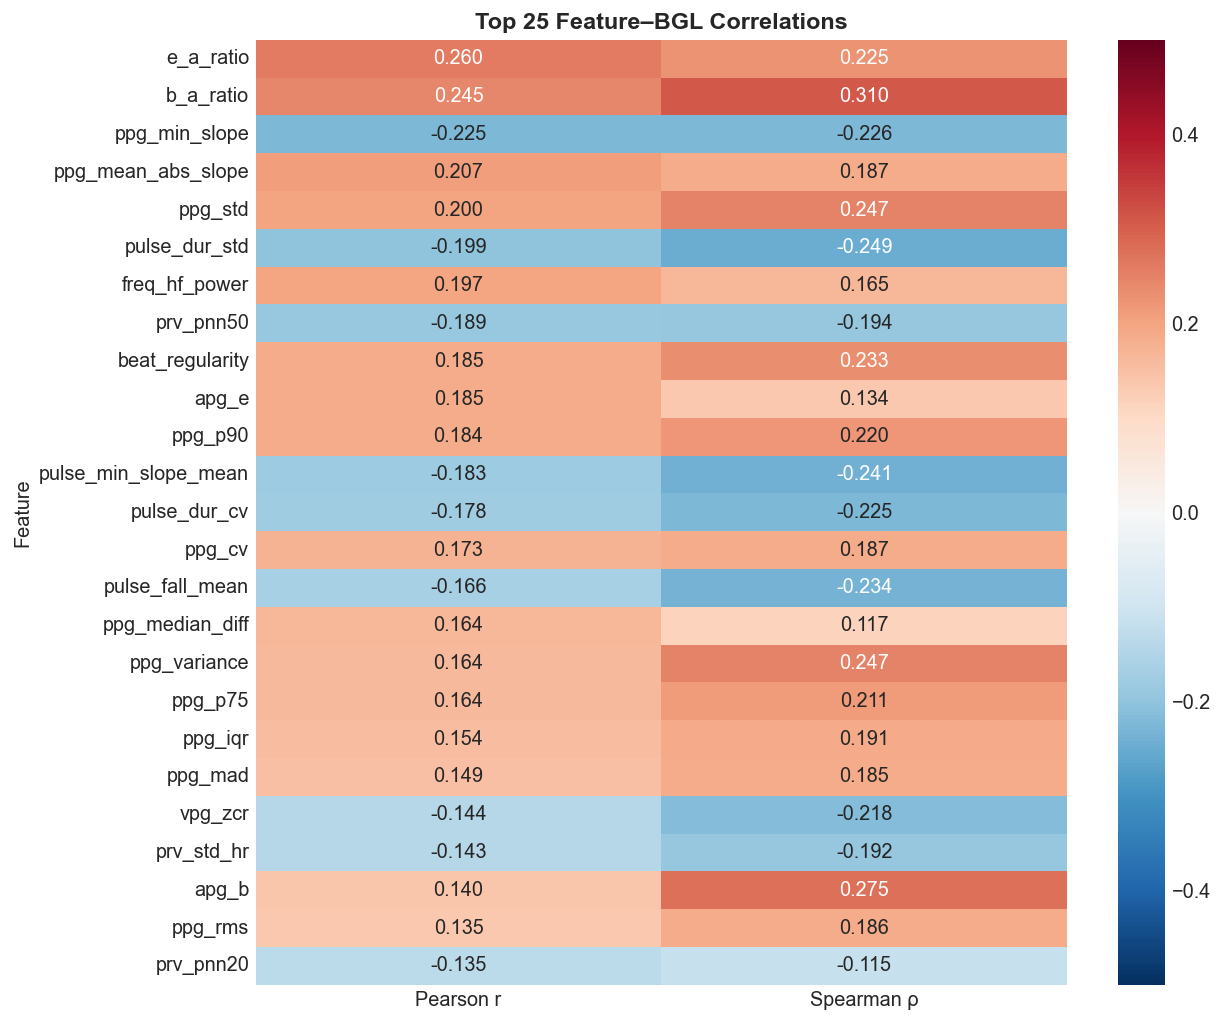

In [27]:
# Correlation heatmap (top features)
top_n = min(25, len(corr_df))
top_features = corr_df.head(top_n)['Feature'].tolist()

fig, ax = plt.subplots(figsize=(10, 8))
corr_vals = corr_df.head(top_n).set_index('Feature')[['Pearson r', 'Spearman ρ']]
sns.heatmap(corr_vals, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            ax=ax, vmin=-0.5, vmax=0.5)
ax.set_title(f'Top {top_n} Feature–BGL Correlations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig7_correlation_heatmap.png')
plt.show()

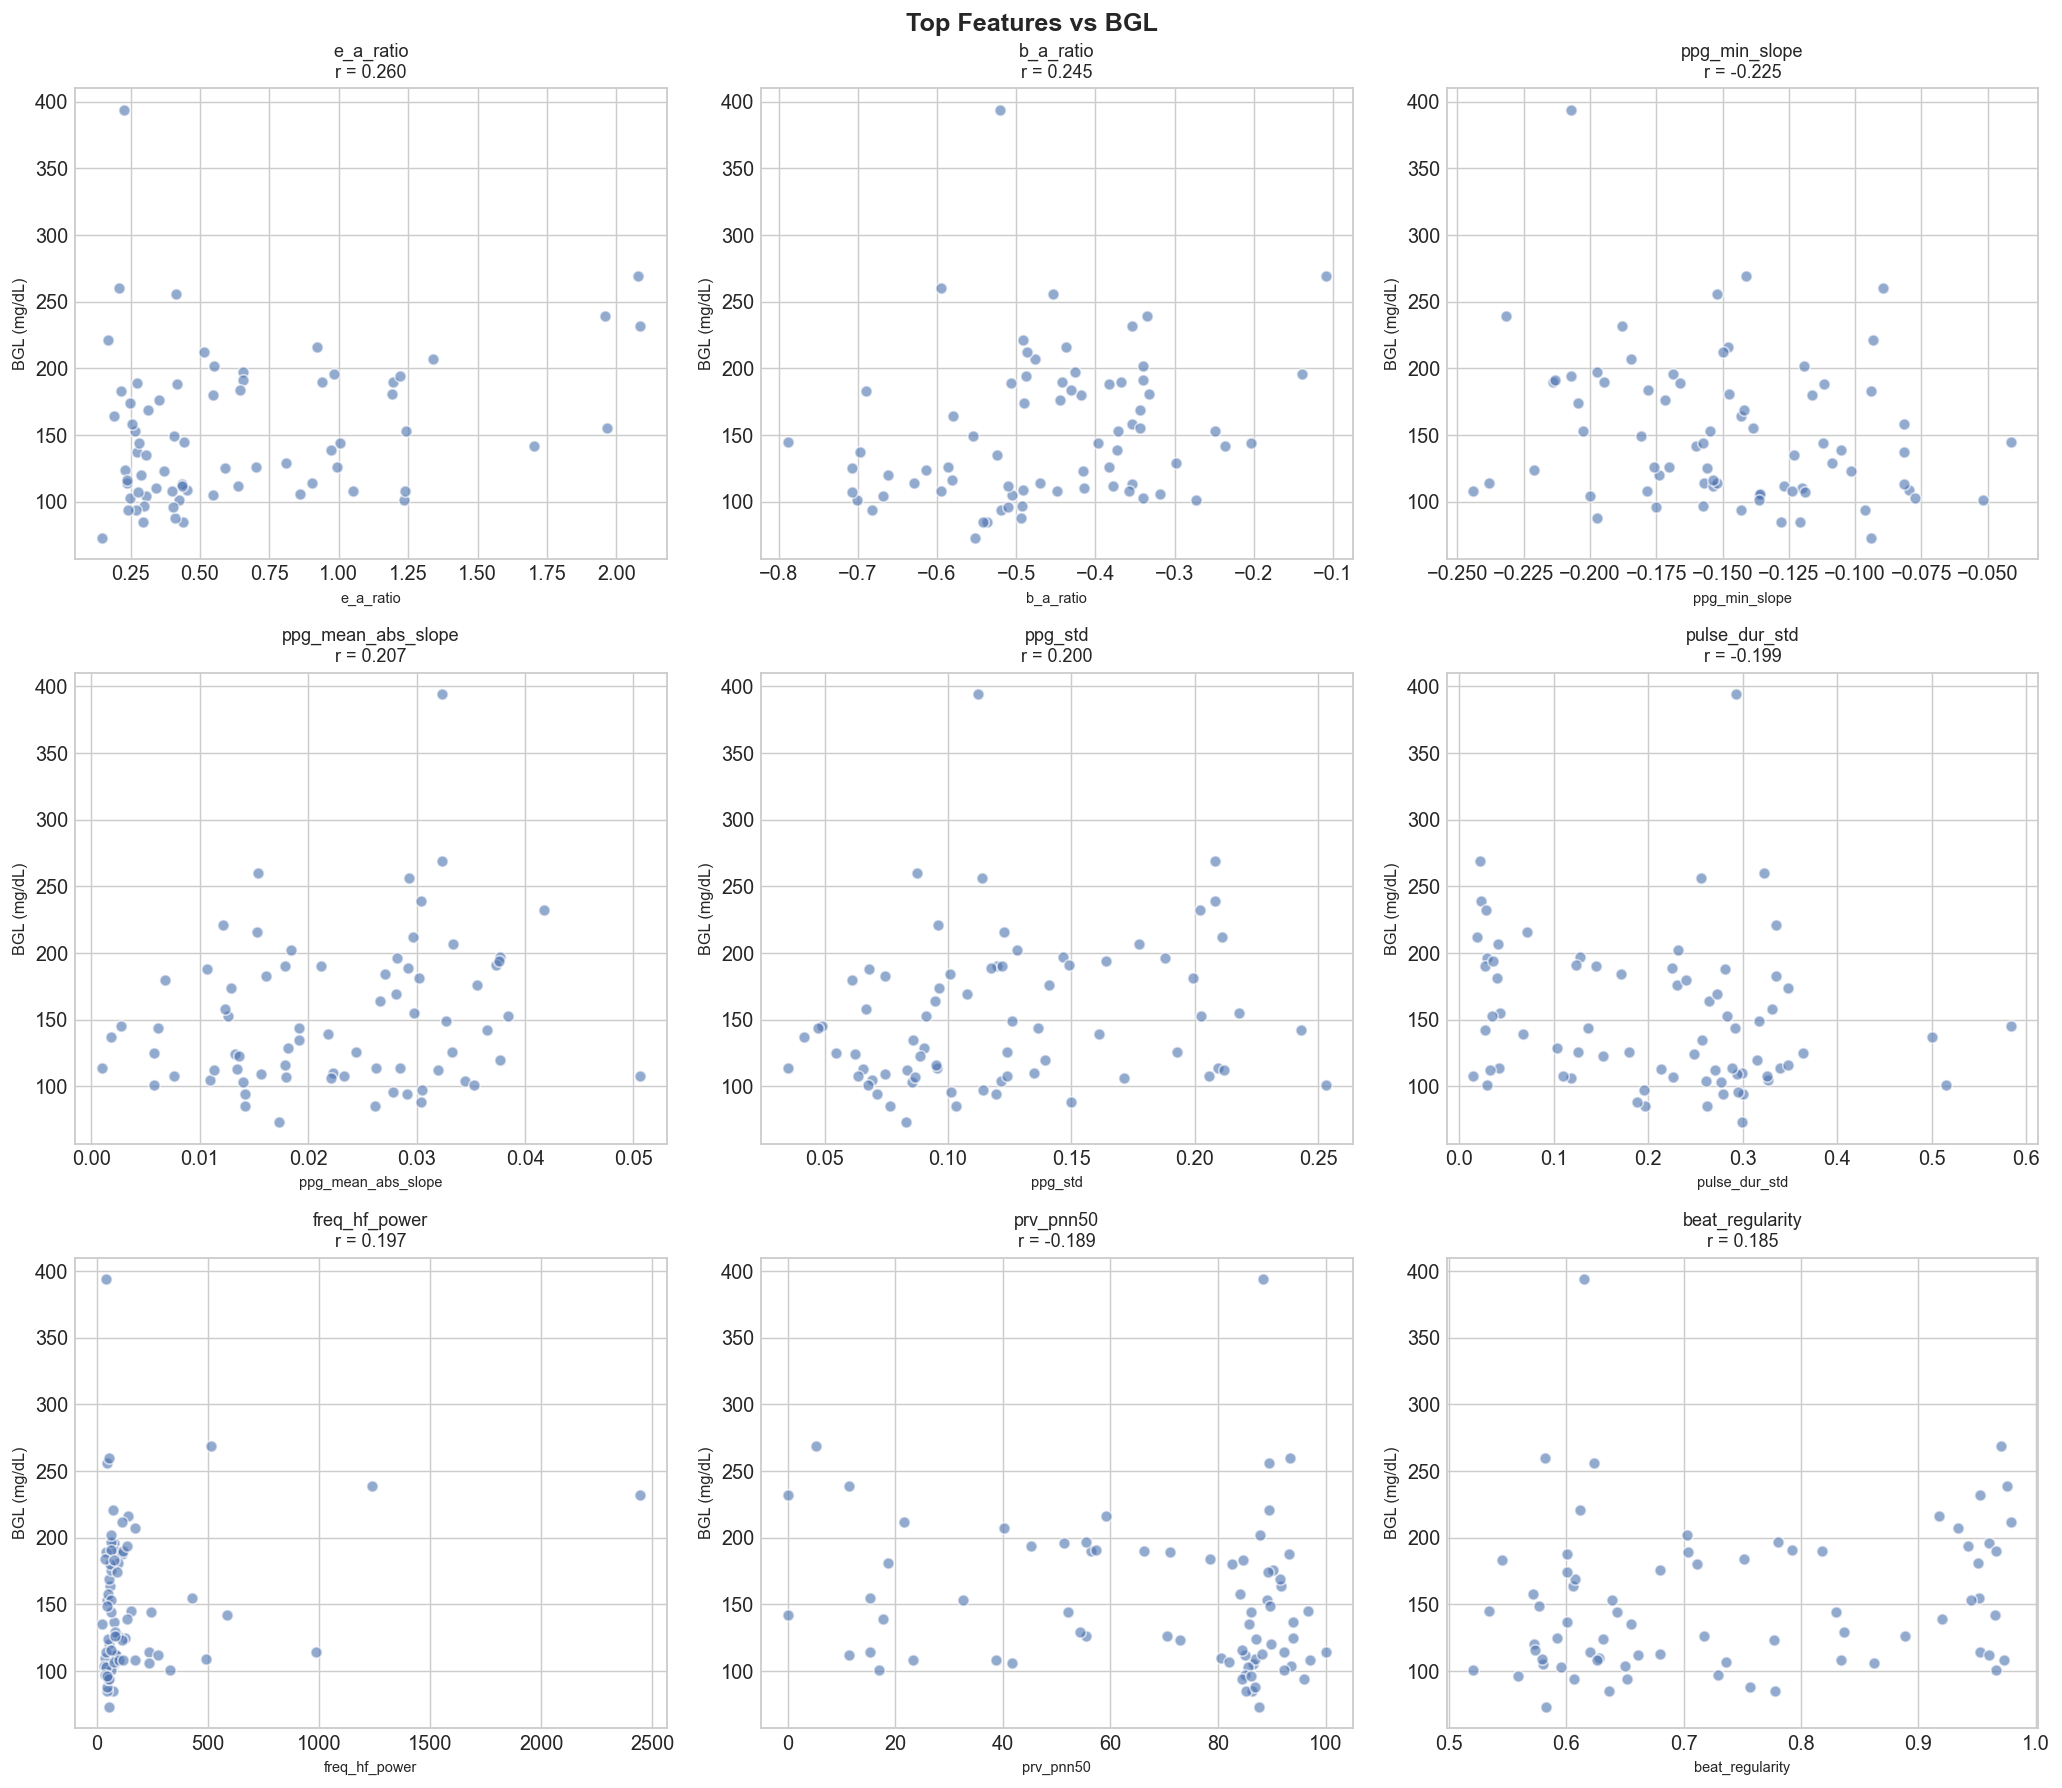

In [28]:
# Feature vs BGL scatterplots for top features
n_plot = min(9, len(top_features))
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
for i in range(n_plot):
    ax = axes[i // 3, i % 3]
    feat = top_features[i]
    x = feature_df[feat].values
    y = feature_df['bgl_mgdl'].values
    mask = ~np.isnan(x)
    ax.scatter(x[mask], y[mask], alpha=0.6, color='#4C72B0', edgecolor='white', s=40)
    r_val = corr_df[corr_df['Feature'] == feat]['Pearson r'].values[0]
    ax.set_title(f'{feat}\nr = {r_val:.3f}', fontsize=10)
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel('BGL (mg/dL)', fontsize=9)

for i in range(n_plot, 9):
    axes[i // 3, i % 3].set_visible(False)

plt.suptitle('Top Features vs BGL', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig8_feature_bgl_scatter.png')
plt.show()

## 24. Nonlinear Feature-BGL Relationships

Correlation alone may miss nonlinear relationships. Mutual information captures
both linear and nonlinear dependencies.

  Dropping 5 all-NaN columns for MI: ['ppg_sample_entropy', 'ppg_approx_entropy', 'ppg_perm_entropy', 'ppg_lzc', 'prv_sample_entropy']


=== Mutual Information: Top 20 Features ===


,Feature,MI Score
50,apg_c,0.192149
81,prv_dfa_alpha1,0.188283
49,apg_b,0.180699
63,freq_cardiac_power,0.147731
53,b_a_ratio,0.137650
48,apg_a,0.134974
47,apg_std,0.127473
79,prv_sd_ratio,0.126509
59,freq_dominant,0.103515
68,freq_hf_rel,0.100081


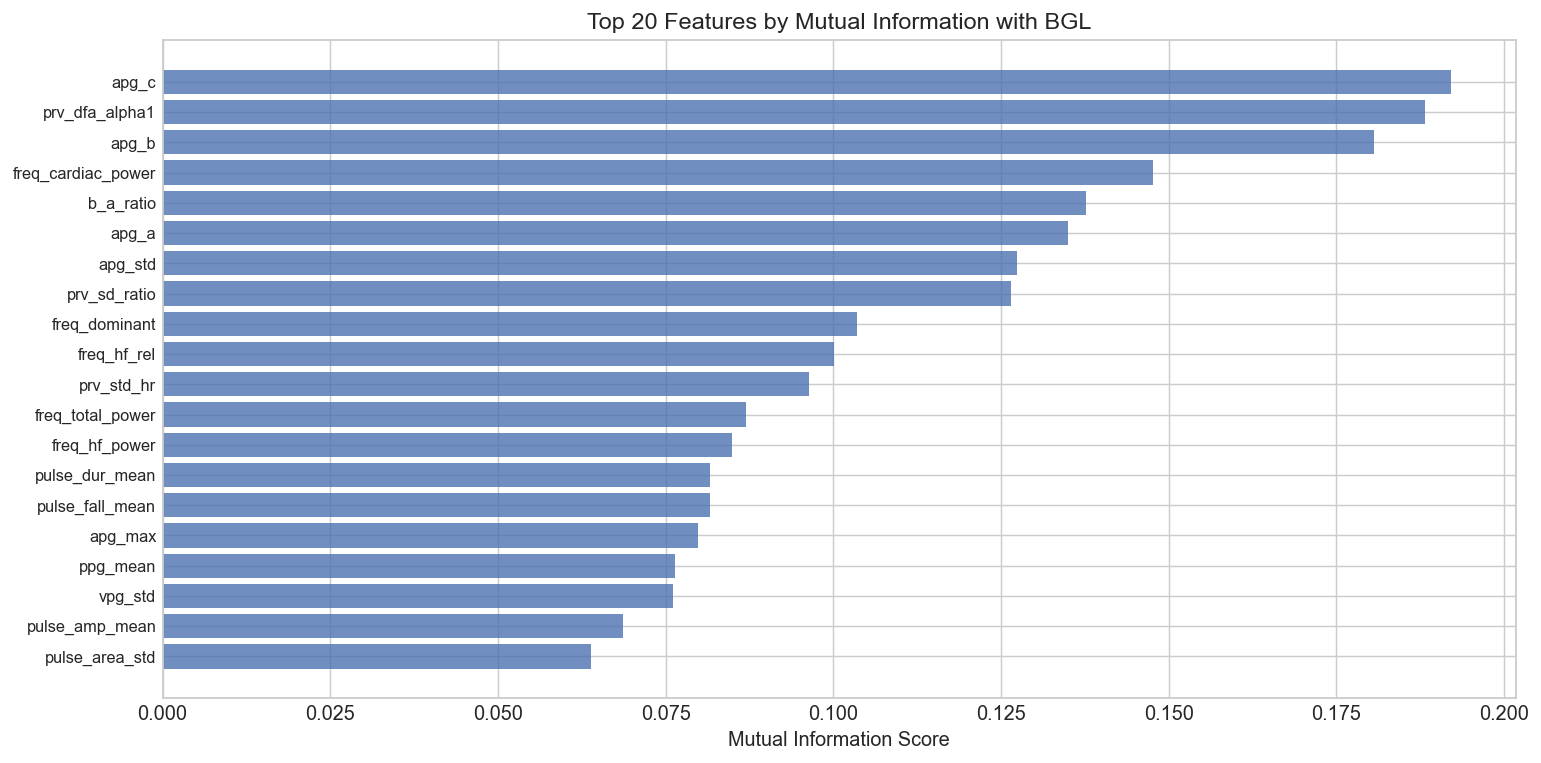

In [29]:
# Mutual information between features and BGL
from sklearn.feature_selection import mutual_info_regression

# Prepare data (impute NaN for MI calculation)
# Drop columns that are entirely NaN first — SimpleImputer can't handle them
X_mi_raw = feature_df[feature_cols_clean].copy()
all_nan_cols = [c for c in feature_cols_clean if X_mi_raw[c].isna().all()]
if all_nan_cols:
    print(f"  Dropping {len(all_nan_cols)} all-NaN columns for MI: {all_nan_cols}")
feature_cols_mi = [c for c in feature_cols_clean if c not in all_nan_cols]

X_mi = X_mi_raw[feature_cols_mi].copy()
imputer_mi = SimpleImputer(strategy='median')
X_mi_imputed = pd.DataFrame(
    imputer_mi.fit_transform(X_mi),
    columns=feature_cols_mi
)
y_mi = feature_df['bgl_mgdl'].values

mi_scores = mutual_info_regression(X_mi_imputed, y_mi, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({
    'Feature': feature_cols_mi,
    'MI Score': mi_scores
}).sort_values('MI Score', ascending=False)

print("=== Mutual Information: Top 20 Features ===")
display(mi_df.head(20))

# Compare MI ranking with correlation ranking
fig, ax = plt.subplots(figsize=(12, 6))
top_mi = mi_df.head(20)
ax.barh(range(len(top_mi)), top_mi['MI Score'].values, color='#4C72B0', alpha=0.8)
ax.set_yticks(range(len(top_mi)))
ax.set_yticklabels(top_mi['Feature'].values, fontsize=9)
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top 20 Features by Mutual Information with BGL')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/fig_mi_scores.png')
plt.show()

## 25. Feature-to-Feature Relationships (Multicollinearity)

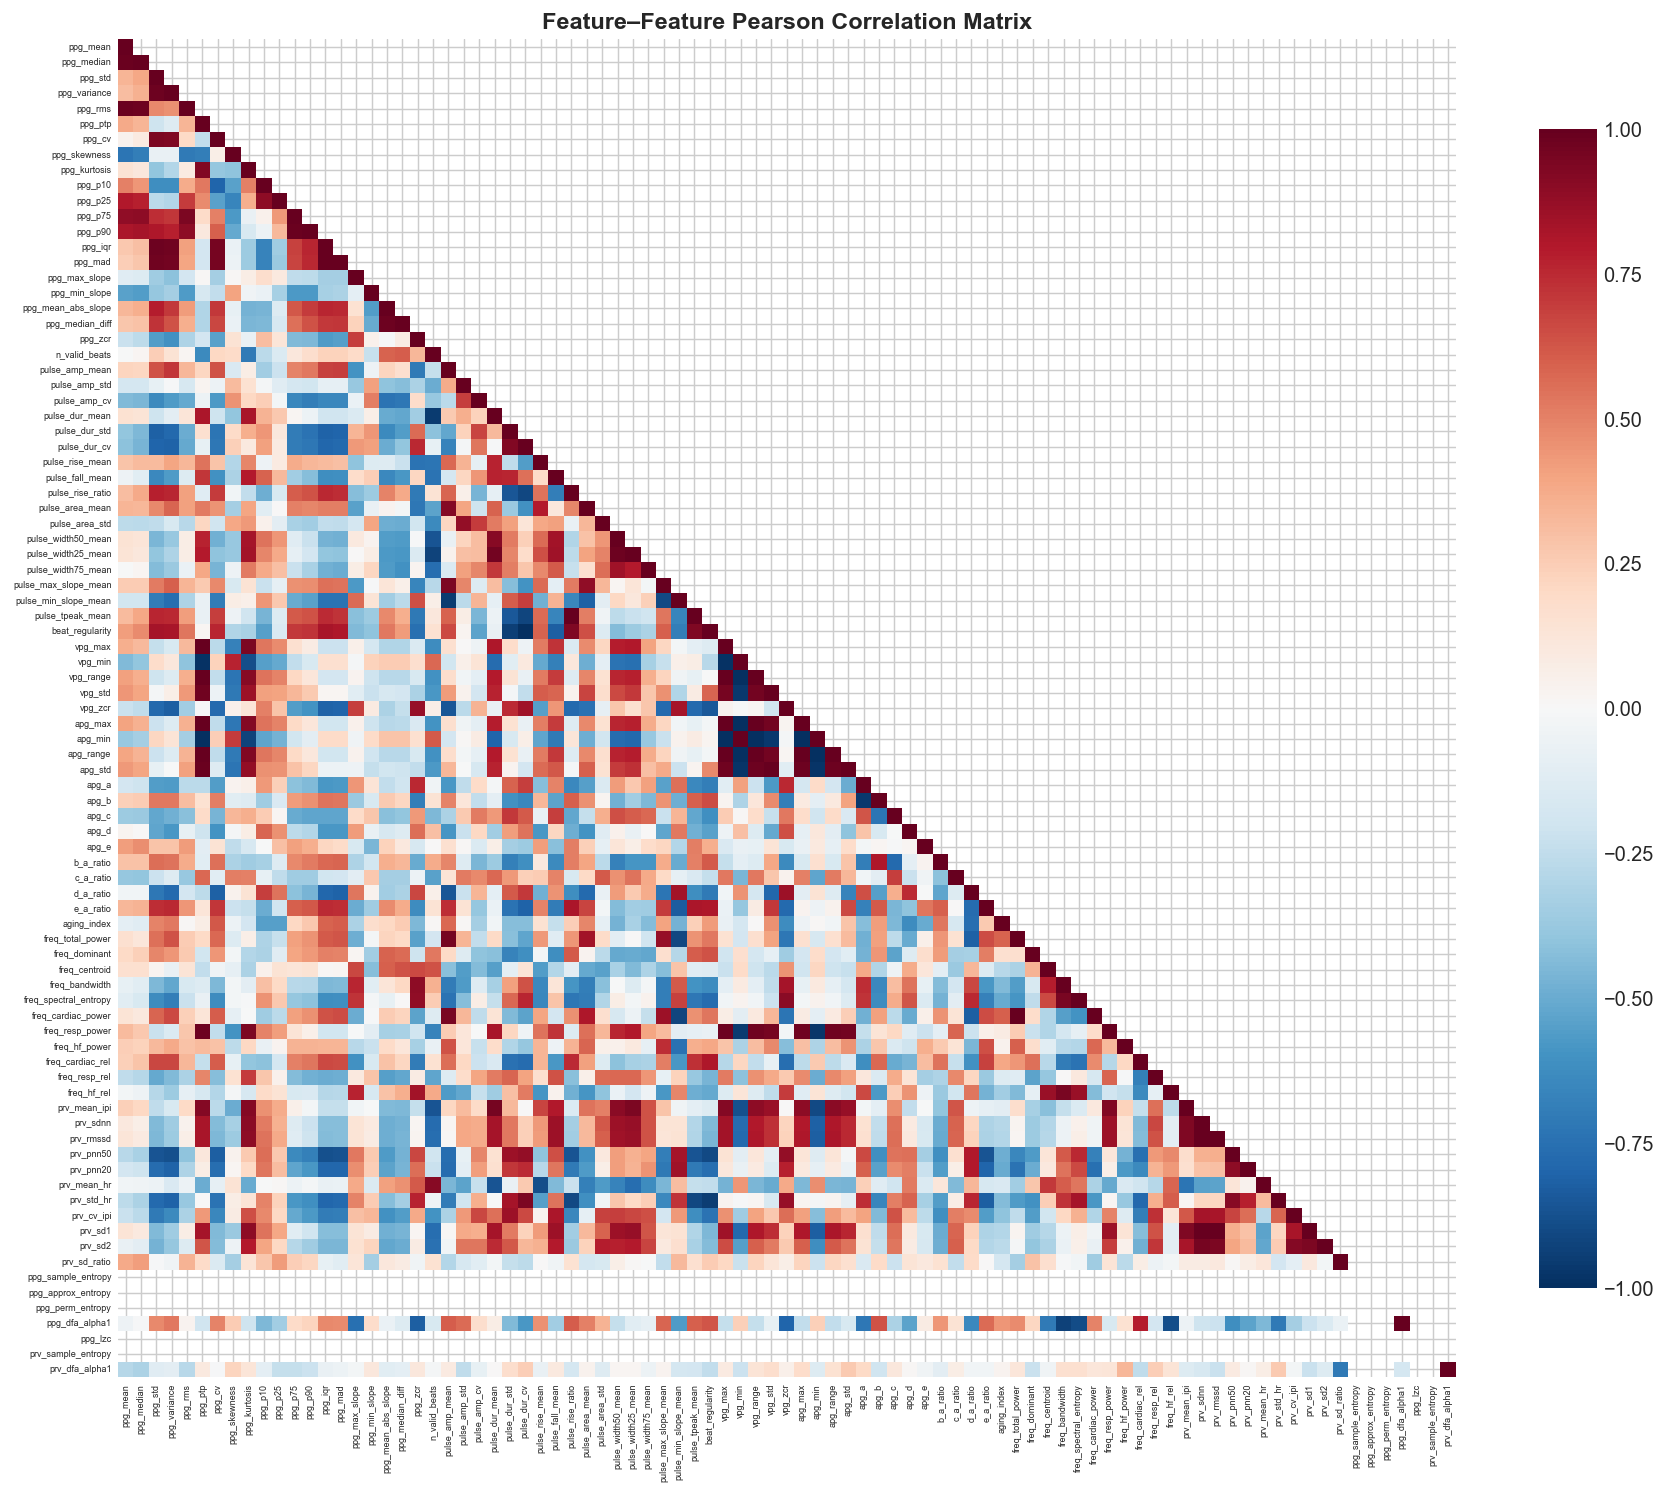


Highly correlated feature pairs (|r| > 0.9): 120


,Feature A,Feature B,Pearson r
50,pulse_dur_cv,beat_regularity,-1.000000
115,prv_rmssd,prv_sd1,0.999935
95,apg_min,apg_range,-0.999791
92,apg_max,apg_range,0.999789
81,vpg_range,apg_max,0.999539
83,vpg_range,apg_range,0.999219
91,apg_max,apg_min,-0.999159
68,vpg_max,apg_min,-0.999050
82,vpg_range,apg_min,-0.998481
112,prv_sdnn,prv_rmssd,0.998383


In [30]:
# Feature correlation matrix
X_corr = feature_df[feature_cols_clean].copy()
pearson_matrix = X_corr.corr(method='pearson')
spearman_matrix = X_corr.corr(method='spearman')

# Heatmap of feature-feature correlations
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(pearson_matrix, dtype=bool), k=1)
sns.heatmap(pearson_matrix, mask=mask, cmap='RdBu_r', center=0,
            square=True, ax=ax, vmin=-1, vmax=1,
            xticklabels=True, yticklabels=True,
            cbar_kws={'shrink': 0.8})
ax.set_xticklabels(ax.get_xticklabels(), fontsize=5, rotation=90)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=5)
ax.set_title('Feature–Feature Pearson Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig_feature_correlation_matrix.png')
plt.show()

# Identify highly correlated feature groups
high_corr_pairs = []
for i in range(len(feature_cols_clean)):
    for j in range(i + 1, len(feature_cols_clean)):
        r = pearson_matrix.iloc[i, j]
        if abs(r) > 0.9 and not np.isnan(r):
            high_corr_pairs.append({
                'Feature A': feature_cols_clean[i],
                'Feature B': feature_cols_clean[j],
                'Pearson r': r,
            })

if high_corr_pairs:
    hc_df = pd.DataFrame(high_corr_pairs).sort_values('Pearson r', ascending=False, key=abs)
    print(f"\nHighly correlated feature pairs (|r| > 0.9): {len(hc_df)}")
    display(hc_df.head(20))
else:
    print("No feature pairs with |r| > 0.9 found.")

## 26. Participant-Specific Feature Patterns

Investigating whether PPG features cluster by participant is critical because
participant-specific variation explains why random KFold and GroupKFold produce
different results.

=== Participant-Specific Feature Patterns ===
Participants with multiple recordings: 10

  e_a_ratio:
    Between-participant variance: 0.174603
    Mean within-participant variance: 0.154457
    ICC proxy: 0.531

  b_a_ratio:
    Between-participant variance: 0.0171269
    Mean within-participant variance: 0.00654337
    ICC proxy: 0.724

  ppg_min_slope:
    Between-participant variance: 0.00190889
    Mean within-participant variance: 0.000663433
    ICC proxy: 0.742

  ppg_mean_abs_slope:
    Between-participant variance: 9.73301e-05
    Mean within-participant variance: 6.16803e-05
    ICC proxy: 0.612



  ppg_std:
    Between-participant variance: 0.00242538
    Mean within-participant variance: 0.00121227
    ICC proxy: 0.667


/tmp/ipykernel_22660/2675555055.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_pid, labels=labels, vert=True, patch_artist=True,


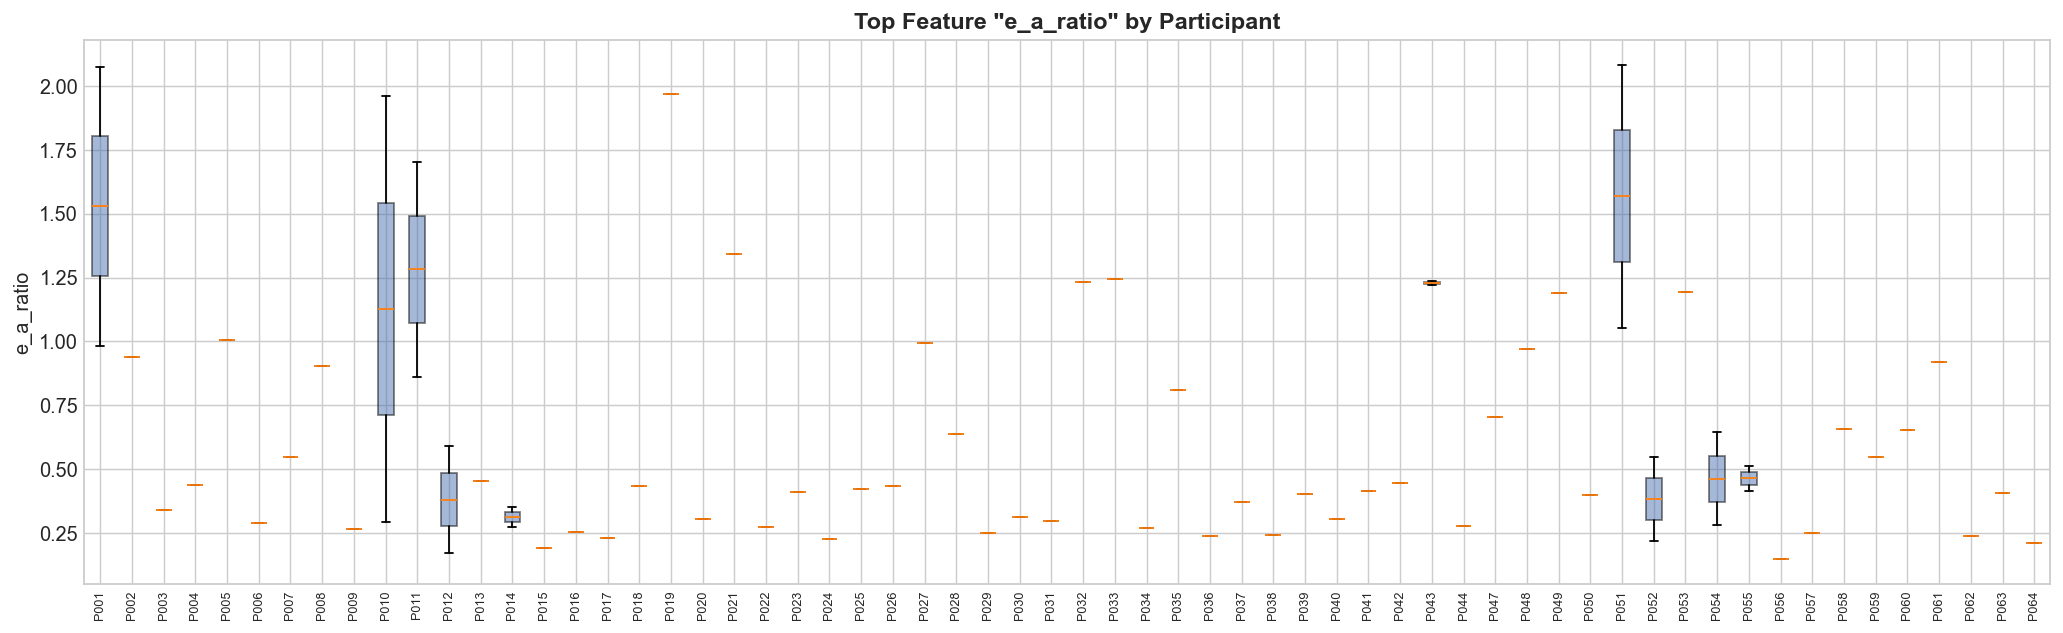

In [31]:
# For top features, examine within- vs between-participant variation
multi_pids_analysis = [pid for pid in unique_participants
                        if sum(1 for r in recordings if r['participant_id'] == pid) > 1]

top5_features = corr_df.head(5)['Feature'].tolist()

if len(multi_pids_analysis) > 0:
    print("=== Participant-Specific Feature Patterns ===")
    print(f"Participants with multiple recordings: {len(multi_pids_analysis)}")

    for feat in top5_features:
        within_vars = []
        between_vals = []
        for pid in unique_participants:
            vals = feature_df[feature_df['participant_id'] == pid][feat].dropna().values
            if len(vals) > 0:
                between_vals.append(np.mean(vals))
            if len(vals) > 1:
                within_vars.append(np.var(vals))

        between_var = np.var(between_vals) if len(between_vals) > 1 else 0
        mean_within_var = np.mean(within_vars) if within_vars else 0
        icc_proxy = between_var / (between_var + mean_within_var + 1e-12)

        print(f"\n  {feat}:")
        print(f"    Between-participant variance: {between_var:.6g}")
        print(f"    Mean within-participant variance: {mean_within_var:.6g}")
        print(f"    ICC proxy: {icc_proxy:.3f}")
else:
    print("Insufficient multi-recording participants for within/between analysis.")

# Feature distributions by participant for top feature
if len(top5_features) > 0:
    feat_to_plot = top5_features[0]
    fig, ax = plt.subplots(figsize=(16, 5))
    data_by_pid = []
    labels = []
    for pid in sorted(unique_participants):
        vals = feature_df[feature_df['participant_id'] == pid][feat_to_plot].dropna().values
        if len(vals) > 0:
            data_by_pid.append(vals)
            labels.append(pid)

    ax.boxplot(data_by_pid, labels=labels, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#4C72B0', alpha=0.5))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_ylabel(feat_to_plot)
    ax.set_title(f'Top Feature "{feat_to_plot}" by Participant', fontweight='bold')
    plt.tight_layout()
    plt.savefig('figures/fig_participant_feature_pattern.png')
    plt.show()

---
## 27. Baseline Model

A simple baseline that always predicts the mean training BGL.
This establishes whether ML models learn anything beyond the mean predictor.

In [32]:
class MeanBaselineRegressor(BaseEstimator, RegressorMixin):
    """Baseline that always predicts the mean of training BGL."""
    def fit(self, X, y):
        self.mean_ = np.mean(y)
        return self

    def predict(self, X):
        return np.full(len(X), self.mean_)

## 28–29. Feature Set Definitions and ML Pipeline Setup

In [33]:
# Define feature families for feature set experiments
time_domain_feats = [c for c in feature_cols_clean if c.startswith('ppg_') and
                     not c.startswith('ppg_sample_') and not c.startswith('ppg_approx_') and
                     not c.startswith('ppg_perm_') and not c.startswith('ppg_dfa_') and
                     not c.startswith('ppg_lzc')]
morphology_feats = [c for c in feature_cols_clean if c.startswith('pulse_') or
                    c.startswith('n_valid_') or c.startswith('beat_')]
derivative_feats = [c for c in feature_cols_clean if c.startswith('vpg_') or
                    c.startswith('apg_') or c.endswith('_ratio') or c == 'aging_index']
frequency_feats = [c for c in feature_cols_clean if c.startswith('freq_')]
prv_feats = [c for c in feature_cols_clean if c.startswith('prv_')]
nonlinear_feats = [c for c in feature_cols_clean if any(c.startswith(p) for p in
                   ['ppg_sample_entropy', 'ppg_approx_entropy', 'ppg_perm_entropy',
                    'ppg_dfa_', 'ppg_lzc', 'prv_sample_entropy', 'prv_dfa_'])]

# Feature sets
feature_sets = {
    'A: Statistical': time_domain_feats,
    'B: Stat+Morph': time_domain_feats + morphology_feats,
    'C: Stat+Morph+Deriv': time_domain_feats + morphology_feats + derivative_feats,
    'D: Stat+Morph+Spectral': time_domain_feats + morphology_feats + frequency_feats,
    'E: All Features': feature_cols_clean,
}

print("=== Feature Set Definitions ===")
for name, feats in feature_sets.items():
    # Remove duplicates while preserving order
    feats_unique = list(dict.fromkeys(feats))
    feature_sets[name] = feats_unique
    print(f"  {name}: {len(feats_unique)} features")

# Feature Set F: Selected features (top by correlation + MI)
top_corr_features = corr_df.head(15)['Feature'].tolist()
top_mi_features = mi_df.head(15)['Feature'].tolist()
selected_features = list(dict.fromkeys(top_corr_features + top_mi_features))
feature_sets['F: Selected'] = selected_features
print(f"  F: Selected: {len(selected_features)} features")

=== Feature Set Definitions ===
  A: Statistical: 20 features
  B: Stat+Morph: 39 features
  C: Stat+Morph+Deriv: 59 features
  D: Stat+Morph+Spectral: 50 features
  E: All Features: 87 features
  F: Selected: 27 features


In [34]:
# Define models
def get_models():
    """Return dictionary of model name -> model instance."""
    models = {
        'Mean Baseline': MeanBaselineRegressor(),
        'Linear Regression': LinearRegression(),
        'Ridge': Ridge(alpha=1.0, random_state=RANDOM_STATE),
        'Lasso': Lasso(alpha=0.1, random_state=RANDOM_STATE, max_iter=5000),
        'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=5000),
        'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE),
        'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=8,
                                                random_state=RANDOM_STATE, n_jobs=-1),
        'Extra Trees': ExtraTreesRegressor(n_estimators=100, max_depth=8,
                                            random_state=RANDOM_STATE, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=4,
                                                        learning_rate=0.1,
                                                        random_state=RANDOM_STATE),
        'HistGBR': HistGradientBoostingRegressor(max_iter=100, max_depth=5,
                                                  learning_rate=0.1,
                                                  random_state=RANDOM_STATE),
        'XGBoost': xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                                     random_state=RANDOM_STATE, verbosity=0),
        'SVR (RBF)': SVR(kernel='rbf', C=10.0, gamma='scale'),
    }

    if HAS_LIGHTGBM:
        models['LightGBM'] = lgb.LGBMRegressor(n_estimators=100, max_depth=5,
                                                 learning_rate=0.1, verbosity=-1,
                                                 random_state=RANDOM_STATE)

    if HAS_CATBOOST:
        models['CatBoost'] = cb.CatBoostRegressor(iterations=100, depth=5,
                                                    learning_rate=0.1, verbose=0,
                                                    random_state=RANDOM_STATE)

    return models


def needs_scaling(model_name):
    """Check if a model requires feature scaling."""
    return model_name in ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet', 'SVR (RBF)']


def build_pipeline(model, model_name):
    """Build a pipeline with imputation and optional scaling."""
    steps = [('imputer', SimpleImputer(strategy='median'))]
    if needs_scaling(model_name):
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', model))
    return Pipeline(steps)


def calculate_metrics(y_true, y_pred):
    """Calculate regression metrics."""
    mask = np.isfinite(y_pred)
    y_t = y_true[mask]
    y_p = y_pred[mask]

    mae = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    r2 = r2_score(y_t, y_p)
    medae = median_absolute_error(y_t, y_p)

    # MARD (Mean Absolute Relative Difference)
    denom = np.abs(y_t)
    denom[denom < 1] = 1  # avoid division by near-zero BGL
    mard = np.mean(np.abs(y_t - y_p) / denom) * 100

    return {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MedAE': medae, 'MARD': mard}

## 30–32. ML Experiments

Three evaluation strategies:
- **Experiment A (In-Sample):** Train and predict on all data. NOT generalisation performance.
- **Experiment B (Random KFold):** Standard 5-fold CV. Recordings randomly split.
- **Experiment C (GroupKFold):** Participant-wise 5-fold CV. PRIMARY generalisation metric.

In [35]:
# Prepare data
X_full = feature_df[feature_cols_clean].copy()
y_full = feature_df['bgl_mgdl'].values
groups_full = feature_df['participant_id'].values
recording_ids = feature_df['recording_id'].values

print(f"ML Dataset: {X_full.shape[0]} samples × {X_full.shape[1]} features")
print(f"Target: BGL range = {y_full.min():.0f}–{y_full.max():.0f} mg/dL")

ML Dataset: 73 samples × 87 features
Target: BGL range = 73–394 mg/dL


### Experiment A — In-Sample Performance

**WARNING:** This is NOT generalisation performance. It only measures model fitting capacity.

In [36]:
print("=" * 65)
print("  EXPERIMENT A — IN-SAMPLE PERFORMANCE")
print("  (Training performance — NOT generalisation)")
print("=" * 65)

insample_results = []
models_dict = get_models()

for fs_name, fs_feats in feature_sets.items():
    X_fs = X_full[fs_feats].values

    for model_name, model in models_dict.items():
        pipe = build_pipeline(model, model_name)
        try:
            pipe.fit(X_fs, y_full)
            y_pred = pipe.predict(X_fs)
            metrics = calculate_metrics(y_full, y_pred)
            metrics['Model'] = model_name
            metrics['Feature Set'] = fs_name
            metrics['Validation'] = 'In-Sample'
            insample_results.append(metrics)
        except Exception as e:
            print(f"  ⚠ {model_name} on {fs_name}: {e}")

insample_df = pd.DataFrame(insample_results)
# Show best results per model (using feature set E)
insample_E = insample_df[insample_df['Feature Set'] == 'E: All Features']
insample_E_sorted = insample_E.sort_values('R²', ascending=False)
print("\nIn-Sample Results (Feature Set E: All Features):")
display(insample_E_sorted[['Model', 'MAE', 'RMSE', 'R²', 'MedAE', 'MARD']].round(3))

  EXPERIMENT A — IN-SAMPLE PERFORMANCE
  (Training performance — NOT generalisation)


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.625e+01, tolerance: 2.191e+01
  model = cd_fast.enet_coordinate_descent(


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values:

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values:

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values:

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(



In-Sample Results (Feature Set E: All Features):


,Model,MAE,RMSE,R²,MedAE,MARD
57,Linear Regression,0.000,0.000,1.000,0.000,0.000
64,Gradient Boosting,0.413,0.497,1.000,0.366,0.306
66,XGBoost,0.617,0.841,1.000,0.428,0.456
63,Extra Trees,4.397,5.812,0.989,3.998,3.475
69,CatBoost,6.857,8.597,0.975,5.498,5.093
62,Random Forest,17.326,22.875,0.826,13.418,12.682
61,Decision Tree,18.914,24.580,0.799,15.696,14.432
65,HistGBR,18.046,24.869,0.794,14.190,12.371
68,LightGBM,21.095,27.710,0.744,17.482,14.503
59,Lasso,21.146,30.656,0.687,16.000,14.361


### Experiment B — Random 5-Fold KFold

In [37]:
print("=" * 65)
print("  EXPERIMENT B — RANDOM 5-FOLD CROSS-VALIDATION")
print("=" * 65)

kfold = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
kfold_results = []
oof_predictions_kfold = []

for fs_name, fs_feats in feature_sets.items():
    X_fs = X_full[fs_feats].values

    for model_name, model_template in models_dict.items():
        fold_metrics = []
        oof_preds = np.full(len(y_full), np.nan)

        for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_fs)):
            X_tr, X_val = X_fs[train_idx], X_fs[val_idx]
            y_tr, y_val = y_full[train_idx], y_full[val_idx]

            from sklearn.base import clone
            pipe = build_pipeline(clone(model_template), model_name)
            try:
                pipe.fit(X_tr, y_tr)
                y_pred = pipe.predict(X_val)
                oof_preds[val_idx] = y_pred

                fm = calculate_metrics(y_val, y_pred)
                fm['fold'] = fold_idx
                fold_metrics.append(fm)
            except Exception:
                continue

        if len(fold_metrics) > 0:
            fm_df = pd.DataFrame(fold_metrics)
            mean_metrics = {
                'Model': model_name,
                'Feature Set': fs_name,
                'Validation': 'Random KFold',
                'MAE': fm_df['MAE'].mean(),
                'MAE_std': fm_df['MAE'].std(),
                'RMSE': fm_df['RMSE'].mean(),
                'RMSE_std': fm_df['RMSE'].std(),
                'R²': fm_df['R²'].mean(),
                'R²_std': fm_df['R²'].std(),
                'MedAE': fm_df['MedAE'].mean(),
                'MARD': fm_df['MARD'].mean(),
            }
            kfold_results.append(mean_metrics)

            # Save OOF predictions for best feature set only
            if fs_name == 'E: All Features':
                for i in range(len(y_full)):
                    if not np.isnan(oof_preds[i]):
                        oof_predictions_kfold.append({
                            'recording_id': recording_ids[i],
                            'participant_id': groups_full[i],
                            'actual_bgl': y_full[i],
                            'predicted_bgl': oof_preds[i],
                            'residual': y_full[i] - oof_preds[i],
                            'model': model_name,
                            'validation': 'Random KFold',
                        })

kfold_df = pd.DataFrame(kfold_results)
kfold_E = kfold_df[kfold_df['Feature Set'] == 'E: All Features'].sort_values('R²', ascending=False)
print("\nRandom KFold Results (Feature Set E):")
display(kfold_E[['Model', 'MAE', 'MAE_std', 'RMSE', 'RMSE_std', 'R²', 'R²_std']].round(3))

  EXPERIMENT B — RANDOM 5-FOLD CROSS-VALIDATION


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.872e+02, tolerance: 1.891e+01
  model = cd_fast.enet_coordinate_descent(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.329e+01, tolerance: 1.954e+01
  model = cd_fast.enet_coordinate_descent(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check t

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.207e+02, tolerance: 1.891e+01
  model = cd_fast.enet_coordinate_descent(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.501e+01, tolerance: 1.954e+01
  model = cd_fast.enet_coordinate_descent(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check t

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.925e+02, tolerance: 1.891e+01
  model = cd_fast.enet_coordinate_descent(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.789e+02, tolerance: 1.954e+01
  model = cd_fast.enet_coordinate_descent(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check t

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values:

...

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values:

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.394e+01, tolerance: 1.316e+01
  model = cd_fast.enet_coordinate_descent(



Random KFold Results (Feature Set E):


,Model,MAE,MAE_std,RMSE,RMSE_std,R²,R²_std
56,Mean Baseline,43.428,7.771,53.771,15.193,-0.036,0.025
67,SVR (RBF),43.692,7.465,56.651,18.427,-0.141,0.154
68,LightGBM,47.379,11.873,60.768,19.935,-0.335,0.400
62,Random Forest,47.228,10.209,61.640,19.176,-0.349,0.160
63,Extra Trees,46.721,8.193,61.134,17.820,-0.349,0.262
69,CatBoost,47.516,8.360,61.237,16.848,-0.352,0.165
65,HistGBR,48.077,11.635,61.783,19.208,-0.385,0.404
66,XGBoost,50.468,16.328,69.752,24.297,-0.848,1.001
64,Gradient Boosting,53.658,13.021,73.039,20.448,-1.040,0.879
58,Ridge,61.362,15.441,81.216,22.600,-1.572,1.237


### Experiment C — Participant-Wise GroupKFold

**This is the most important validation experiment.**
No participant appears in both training and validation within the same fold.

In [38]:
print("=" * 65)
print("  EXPERIMENT C — PARTICIPANT-WISE GROUP K-FOLD")
print("  (Primary generalisation assessment)")
print("=" * 65)

gkf = GroupKFold(n_splits=N_SPLITS)
gkf_results = []
oof_predictions_gkf = []

for fs_name, fs_feats in feature_sets.items():
    X_fs = X_full[fs_feats].values

    for model_name, model_template in models_dict.items():
        fold_metrics = []
        oof_preds = np.full(len(y_full), np.nan)

        for fold_idx, (train_idx, val_idx) in enumerate(gkf.split(X_fs, y_full, groups_full)):
            X_tr, X_val = X_fs[train_idx], X_fs[val_idx]
            y_tr, y_val = y_full[train_idx], y_full[val_idx]

            pipe = build_pipeline(clone(model_template), model_name)
            try:
                pipe.fit(X_tr, y_tr)
                y_pred = pipe.predict(X_val)
                oof_preds[val_idx] = y_pred

                fm = calculate_metrics(y_val, y_pred)
                fm['fold'] = fold_idx
                fm['train_participants'] = len(set(groups_full[train_idx]))
                fm['val_participants'] = len(set(groups_full[val_idx]))
                fold_metrics.append(fm)
            except Exception:
                continue

        if len(fold_metrics) > 0:
            fm_df = pd.DataFrame(fold_metrics)
            mean_metrics = {
                'Model': model_name,
                'Feature Set': fs_name,
                'Validation': 'GroupKFold',
                'MAE': fm_df['MAE'].mean(),
                'MAE_std': fm_df['MAE'].std(),
                'RMSE': fm_df['RMSE'].mean(),
                'RMSE_std': fm_df['RMSE'].std(),
                'R²': fm_df['R²'].mean(),
                'R²_std': fm_df['R²'].std(),
                'MedAE': fm_df['MedAE'].mean(),
                'MARD': fm_df['MARD'].mean(),
            }
            gkf_results.append(mean_metrics)

            if fs_name == 'E: All Features':
                for i in range(len(y_full)):
                    if not np.isnan(oof_preds[i]):
                        oof_predictions_gkf.append({
                            'recording_id': recording_ids[i],
                            'participant_id': groups_full[i],
                            'actual_bgl': y_full[i],
                            'predicted_bgl': oof_preds[i],
                            'residual': y_full[i] - oof_preds[i],
                            'model': model_name,
                            'validation': 'GroupKFold',
                        })

gkf_df = pd.DataFrame(gkf_results)
gkf_E = gkf_df[gkf_df['Feature Set'] == 'E: All Features'].sort_values('R²', ascending=False)
print("\nGroupKFold Results (Feature Set E):")
display(gkf_E[['Model', 'MAE', 'MAE_std', 'RMSE', 'RMSE_std', 'R²', 'R²_std']].round(3))

  EXPERIMENT C — PARTICIPANT-WISE GROUP K-FOLD
  (Primary generalisation assessment)


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.024e+01, tolerance: 1.827e+01
  model = cd_fast.enet_coordinate_descent(


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.566e+01, tolerance: 1.827e+01
  model = cd_fast.enet_coordinate_descent(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.761e+01, tolerance: 1.780e+01
  model = cd_fast.enet_coordinate_descent(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check t

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.688e+02, tolerance: 1.827e+01
  model = cd_fast.enet_coordinate_descent(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.075e+02, tolerance: 1.859e+01
  model = cd_fast.enet_coordinate_descent(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check t

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.131e+02, tolerance: 1.827e+01
  model = cd_fast.enet_coordinate_descent(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.817e+02, tolerance: 1.780e+01
  model = cd_fast.enet_coordinate_descent(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check t

...

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(



GroupKFold Results (Feature Set E):


,Model,MAE,MAE_std,RMSE,RMSE_std,R²,R²_std
56,Mean Baseline,44.732,4.568,55.498,13.003,-0.259,0.285
67,SVR (RBF),44.583,6.622,57.723,17.626,-0.316,0.224
63,Extra Trees,46.670,7.374,59.094,17.604,-0.387,0.232
69,CatBoost,45.598,6.003,59.193,16.535,-0.399,0.214
65,HistGBR,46.986,4.974,59.676,15.999,-0.436,0.292
62,Random Forest,46.125,5.590,59.602,16.254,-0.437,0.319
68,LightGBM,46.941,4.503,59.952,15.366,-0.446,0.213
66,XGBoost,48.657,8.746,64.714,18.214,-0.748,0.704
64,Gradient Boosting,48.661,7.384,65.418,16.525,-0.781,0.589
61,Decision Tree,56.136,11.023,71.205,18.868,-1.134,0.832


### Experiment: Leave-One-Group-Out (LOGO)

In [39]:
print("=" * 65)
print("  LEAVE-ONE-GROUP-OUT (LOGO) — Selected Models")
print("=" * 65)

logo = LeaveOneGroupOut()

# Run LOGO only on top models (computationally expensive)
top_gkf_models = gkf_E.head(5)['Model'].tolist()
logo_results = []
logo_participant_results = []

X_E = X_full[feature_sets['E: All Features']].values

for model_name in top_gkf_models:
    model_template = models_dict[model_name]
    oof_preds = np.full(len(y_full), np.nan)

    for train_idx, val_idx in logo.split(X_E, y_full, groups_full):
        X_tr, X_val = X_E[train_idx], X_E[val_idx]
        y_tr, y_val = y_full[train_idx], y_full[val_idx]

        pipe = build_pipeline(clone(model_template), model_name)
        try:
            pipe.fit(X_tr, y_tr)
            y_pred = pipe.predict(X_val)
            oof_preds[val_idx] = y_pred
        except Exception:
            continue

    mask = ~np.isnan(oof_preds)
    if mask.sum() > 0:
        metrics = calculate_metrics(y_full[mask], oof_preds[mask])
        metrics['Model'] = model_name
        metrics['Validation'] = 'LOGO'
        metrics['Feature Set'] = 'E: All Features'
        logo_results.append(metrics)

        # Participant-level metrics
        for pid in np.unique(groups_full):
            pid_mask = (groups_full == pid) & mask
            if pid_mask.sum() > 0:
                pid_metrics = calculate_metrics(y_full[pid_mask], oof_preds[pid_mask])
                pid_metrics['participant_id'] = pid
                pid_metrics['model'] = model_name
                pid_metrics['n_recordings'] = pid_mask.sum()
                logo_participant_results.append(pid_metrics)

logo_df = pd.DataFrame(logo_results)
print("\nLOGO Results (Feature Set E):")
display(logo_df[['Model', 'MAE', 'RMSE', 'R²', 'MedAE', 'MARD']].round(3))

if logo_participant_results:
    logo_part_df = pd.DataFrame(logo_participant_results)
    logo_part_df.to_csv('results/participant_performance.csv', index=False)
    print(f"\nParticipant-level LOGO results saved ({len(logo_part_df)} entries).")

  LEAVE-ONE-GROUP-OUT (LOGO) — Selected Models


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values:

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values:

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values:

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values:

...

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values:


LOGO Results (Feature Set E):


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/hom

,Model,MAE,RMSE,R²,MedAE,MARD
0,Mean Baseline,43.793,55.542,-0.028,40.028,30.799
1,SVR (RBF),42.397,57.957,-0.119,37.366,26.686
2,Extra Trees,46.771,60.534,-0.221,40.330,32.984
3,CatBoost,44.567,59.271,-0.171,34.962,31.108
4,HistGBR,48.206,61.304,-0.252,38.176,33.710



Participant-level LOGO results saved (315 entries).


### Nested GroupKFold (Top Models Only)

Outer loop: GroupKFold for evaluation. Inner loop: GroupKFold for hyperparameter tuning.
This provides the strongest estimate of model generalisation.

In [40]:
print("=" * 65)
print("  NESTED GROUP CROSS-VALIDATION (Top 3 Models)")
print("=" * 65)

# Hyperparameter search spaces
param_spaces = {
    'Random Forest': {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [3, 5, 8, 12],
        'model__min_samples_split': [2, 5, 10],
    },
    'XGBoost': {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [3, 5, 7],
        'model__learning_rate': [0.01, 0.05, 0.1],
    },
    'Gradient Boosting': {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [3, 4, 6],
        'model__learning_rate': [0.01, 0.05, 0.1],
    },
    'Ridge': {
        'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
    },
    'Lasso': {
        'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
    },
    'SVR (RBF)': {
        'model__C': [0.1, 1.0, 10.0, 100.0],
        'model__gamma': ['scale', 'auto'],
    },
}

top_nested_models = gkf_E.head(3)['Model'].tolist()
nested_results = []
outer_gkf = GroupKFold(n_splits=N_SPLITS)

for model_name in top_nested_models:
    if model_name not in param_spaces:
        print(f"  Skipping {model_name} (no param space defined)")
        continue

    model_template = models_dict[model_name]
    fold_metrics = []

    for fold_idx, (train_idx, val_idx) in enumerate(outer_gkf.split(X_E, y_full, groups_full)):
        X_tr, X_val = X_E[train_idx], X_E[val_idx]
        y_tr, y_val = y_full[train_idx], y_full[val_idx]
        g_tr = groups_full[train_idx]

        pipe = build_pipeline(clone(model_template), model_name)

        inner_gkf = GroupKFold(n_splits=min(3, len(np.unique(g_tr))))
        try:
            search = RandomizedSearchCV(
                pipe, param_spaces[model_name],
                n_iter=min(15, len(param_spaces[model_name])),
                cv=inner_gkf, scoring='neg_mean_absolute_error',
                random_state=RANDOM_STATE, n_jobs=-1, refit=True,
            )
            search.fit(X_tr, y_tr, groups=g_tr)
            y_pred = search.predict(X_val)
            fm = calculate_metrics(y_val, y_pred)
            fm['fold'] = fold_idx
            fm['best_params'] = str(search.best_params_)
            fold_metrics.append(fm)
        except Exception as e:
            print(f"  ⚠ Nested CV fold {fold_idx} failed for {model_name}: {e}")

    if fold_metrics:
        fm_df = pd.DataFrame(fold_metrics)
        nested_results.append({
            'Model': model_name,
            'Feature Set': 'E: All Features',
            'Validation': 'Nested GroupKFold',
            'MAE': fm_df['MAE'].mean(),
            'MAE_std': fm_df['MAE'].std(),
            'RMSE': fm_df['RMSE'].mean(),
            'R²': fm_df['R²'].mean(),
            'R²_std': fm_df['R²'].std(),
            'MedAE': fm_df['MedAE'].mean(),
            'MARD': fm_df['MARD'].mean(),
        })

nested_df = pd.DataFrame(nested_results)
if len(nested_df) > 0:
    print("\nNested GroupKFold Results:")
    display(nested_df[['Model', 'MAE', 'RMSE', 'R²', 'R²_std']].round(3))

  NESTED GROUP CROSS-VALIDATION (Top 3 Models)
  Skipping Mean Baseline (no param space defined)


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values:

  Skipping Extra Trees (no param space defined)

Nested GroupKFold Results:


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values:

,Model,MAE,RMSE,R²,R²_std
0,SVR (RBF),44.701,57.724,-0.312,0.203


---
## 39. Actual vs Predicted Plots

In [41]:
# Select best model from GroupKFold for detailed analysis
best_gkf_model_name = gkf_E.iloc[0]['Model']
print(f"Best GroupKFold model: {best_gkf_model_name}")

# Re-run best model to get OOF predictions for all 3 strategies
best_model_template = models_dict[best_gkf_model_name]
X_E_arr = X_E.copy()

# In-sample predictions
pipe_insample = build_pipeline(clone(best_model_template), best_gkf_model_name)
pipe_insample.fit(X_E_arr, y_full)
y_pred_insample = pipe_insample.predict(X_E_arr)

# Random KFold OOF
kf_oof = np.full(len(y_full), np.nan)
for train_idx, val_idx in kfold.split(X_E_arr):
    pipe_kf = build_pipeline(clone(best_model_template), best_gkf_model_name)
    pipe_kf.fit(X_E_arr[train_idx], y_full[train_idx])
    kf_oof[val_idx] = pipe_kf.predict(X_E_arr[val_idx])

# GroupKFold OOF
gkf_oof = np.full(len(y_full), np.nan)
for train_idx, val_idx in gkf.split(X_E_arr, y_full, groups_full):
    pipe_gkf = build_pipeline(clone(best_model_template), best_gkf_model_name)
    pipe_gkf.fit(X_E_arr[train_idx], y_full[train_idx])
    gkf_oof[val_idx] = pipe_gkf.predict(X_E_arr[val_idx])

Best GroupKFold model: Mean Baseline


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values:

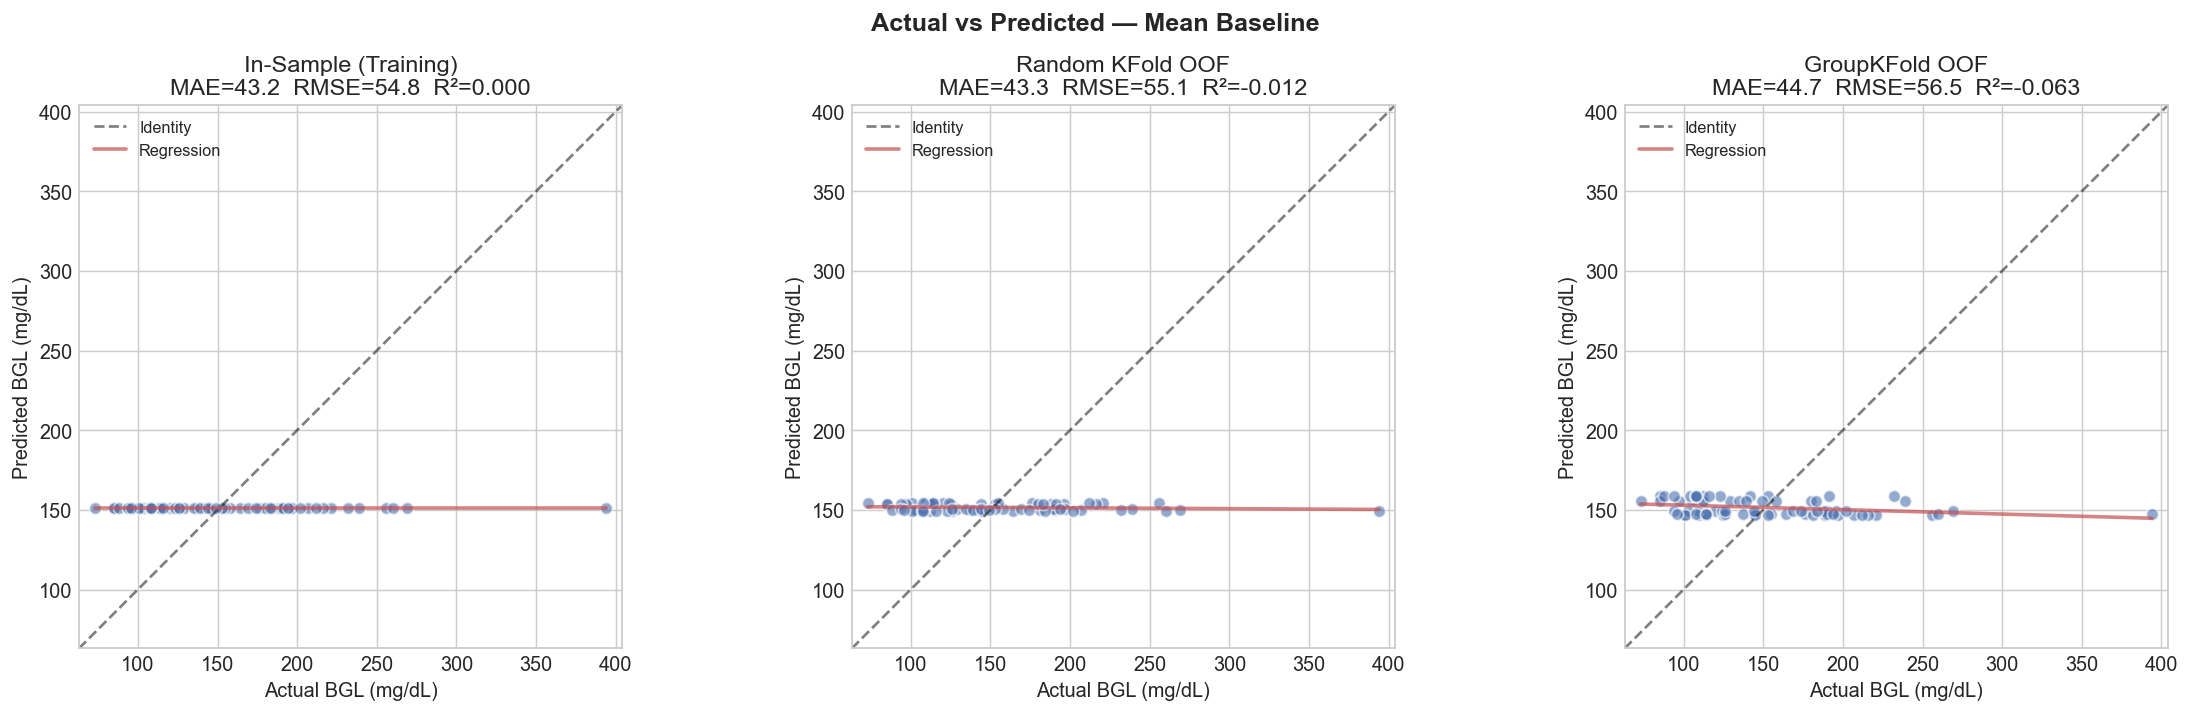

In [42]:
# Actual vs Predicted plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
plot_data = [
    ('In-Sample (Training)', y_full, y_pred_insample),
    ('Random KFold OOF', y_full, kf_oof),
    ('GroupKFold OOF', y_full, gkf_oof),
]

for ax_idx, (title, y_true, y_pred) in enumerate(plot_data):
    ax = axes[ax_idx]
    mask = np.isfinite(y_pred)
    yt, yp = y_true[mask], y_pred[mask]

    ax.scatter(yt, yp, alpha=0.6, color='#4C72B0', edgecolor='white', s=45)

    # Identity line
    lims = [min(yt.min(), yp.min()) - 10, max(yt.max(), yp.max()) + 10]
    ax.plot(lims, lims, 'k--', alpha=0.5, lw=1.5, label='Identity')

    # Regression line
    if len(yt) > 2:
        z = np.polyfit(yt, yp, 1)
        p = np.poly1d(z)
        ax.plot(sorted(yt), p(sorted(yt)), color='#C44E52', lw=2, alpha=0.7, label='Regression')

    metrics = calculate_metrics(yt, yp)
    ax.set_xlabel('Actual BGL (mg/dL)')
    ax.set_ylabel('Predicted BGL (mg/dL)')
    ax.set_title(f'{title}\nMAE={metrics["MAE"]:.1f}  RMSE={metrics["RMSE"]:.1f}  R²={metrics["R²"]:.3f}')
    ax.legend(fontsize=9)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')

plt.suptitle(f'Actual vs Predicted — {best_gkf_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig9_actual_vs_predicted.png')
plt.show()

## 40. Residual Analysis

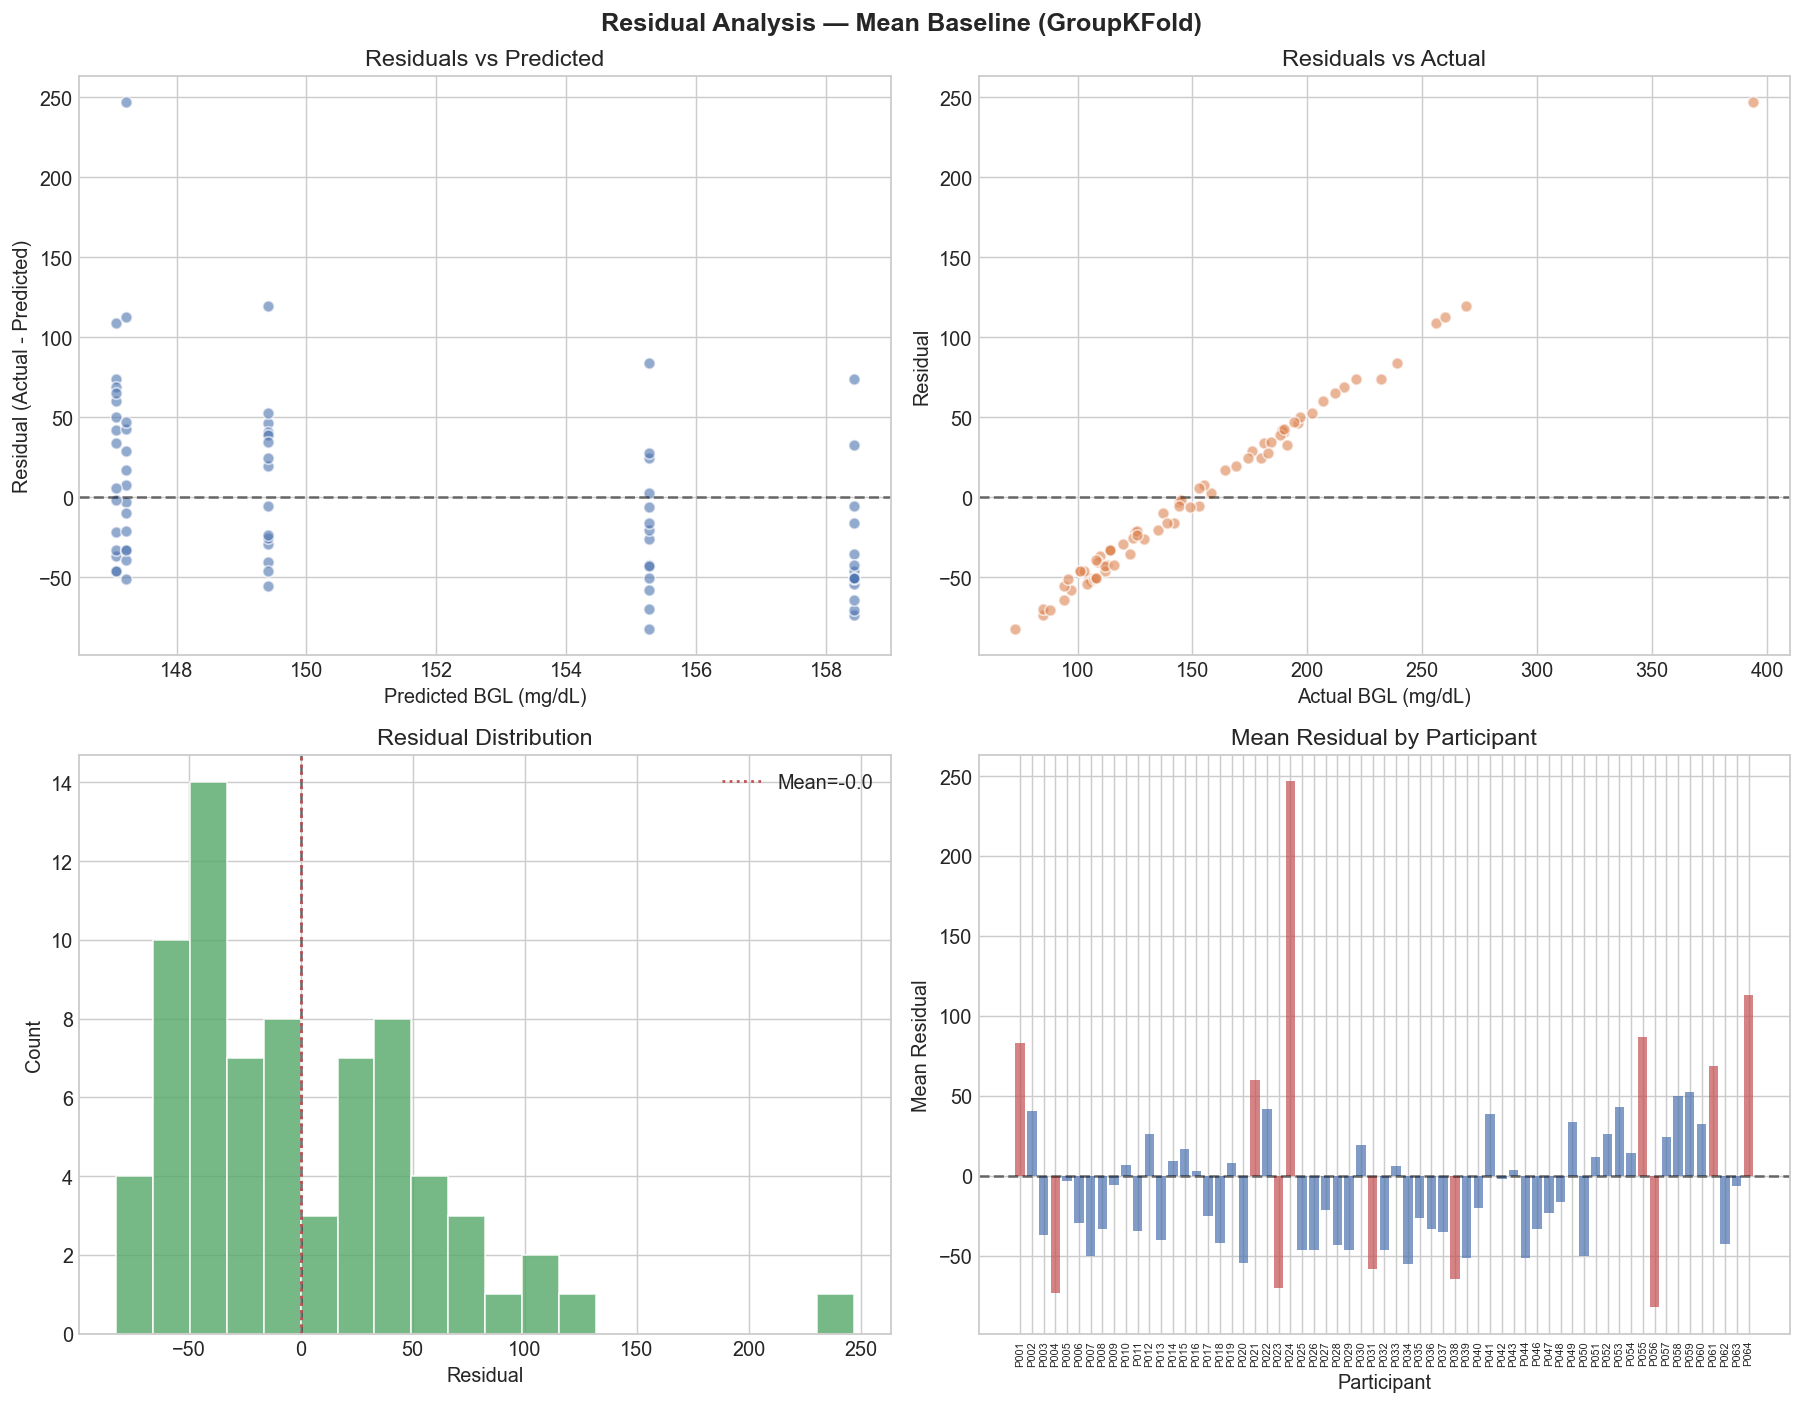

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Use GroupKFold OOF predictions
mask = np.isfinite(gkf_oof)
residuals = y_full[mask] - gkf_oof[mask]
y_act = y_full[mask]
y_prd = gkf_oof[mask]

# Residual vs Predicted
ax = axes[0, 0]
ax.scatter(y_prd, residuals, alpha=0.6, color='#4C72B0', edgecolor='white', s=40)
ax.axhline(0, color='k', ls='--', alpha=0.5)
ax.set_xlabel('Predicted BGL (mg/dL)')
ax.set_ylabel('Residual (Actual - Predicted)')
ax.set_title('Residuals vs Predicted')

# Residual vs Actual
ax = axes[0, 1]
ax.scatter(y_act, residuals, alpha=0.6, color='#DD8452', edgecolor='white', s=40)
ax.axhline(0, color='k', ls='--', alpha=0.5)
ax.set_xlabel('Actual BGL (mg/dL)')
ax.set_ylabel('Residual')
ax.set_title('Residuals vs Actual')

# Residual distribution
ax = axes[1, 0]
ax.hist(residuals, bins=20, color='#55A868', edgecolor='white', alpha=0.8)
ax.axvline(0, color='k', ls='--', alpha=0.5)
ax.axvline(np.mean(residuals), color='#C44E52', ls=':', label=f'Mean={np.mean(residuals):.1f}')
ax.set_xlabel('Residual')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution')
ax.legend()

# Residual by participant
ax = axes[1, 1]
pids_mask = groups_full[mask]
pid_residuals = {}
for pid, res in zip(pids_mask, residuals):
    if pid not in pid_residuals:
        pid_residuals[pid] = []
    pid_residuals[pid].append(res)

sorted_pids_res = sorted(pid_residuals.keys())
pid_mean_res = [np.mean(pid_residuals[p]) for p in sorted_pids_res]
colors_res = ['#C44E52' if abs(m) > np.std(residuals) else '#4C72B0' for m in pid_mean_res]
ax.bar(range(len(sorted_pids_res)), pid_mean_res, color=colors_res, alpha=0.7)
ax.set_xticks(range(len(sorted_pids_res)))
ax.set_xticklabels(sorted_pids_res, rotation=90, fontsize=6)
ax.axhline(0, color='k', ls='--', alpha=0.5)
ax.set_xlabel('Participant')
ax.set_ylabel('Mean Residual')
ax.set_title('Mean Residual by Participant')

plt.suptitle(f'Residual Analysis — {best_gkf_model_name} (GroupKFold)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig10_residual_analysis.png')
plt.show()

## 41. Bland–Altman Analysis

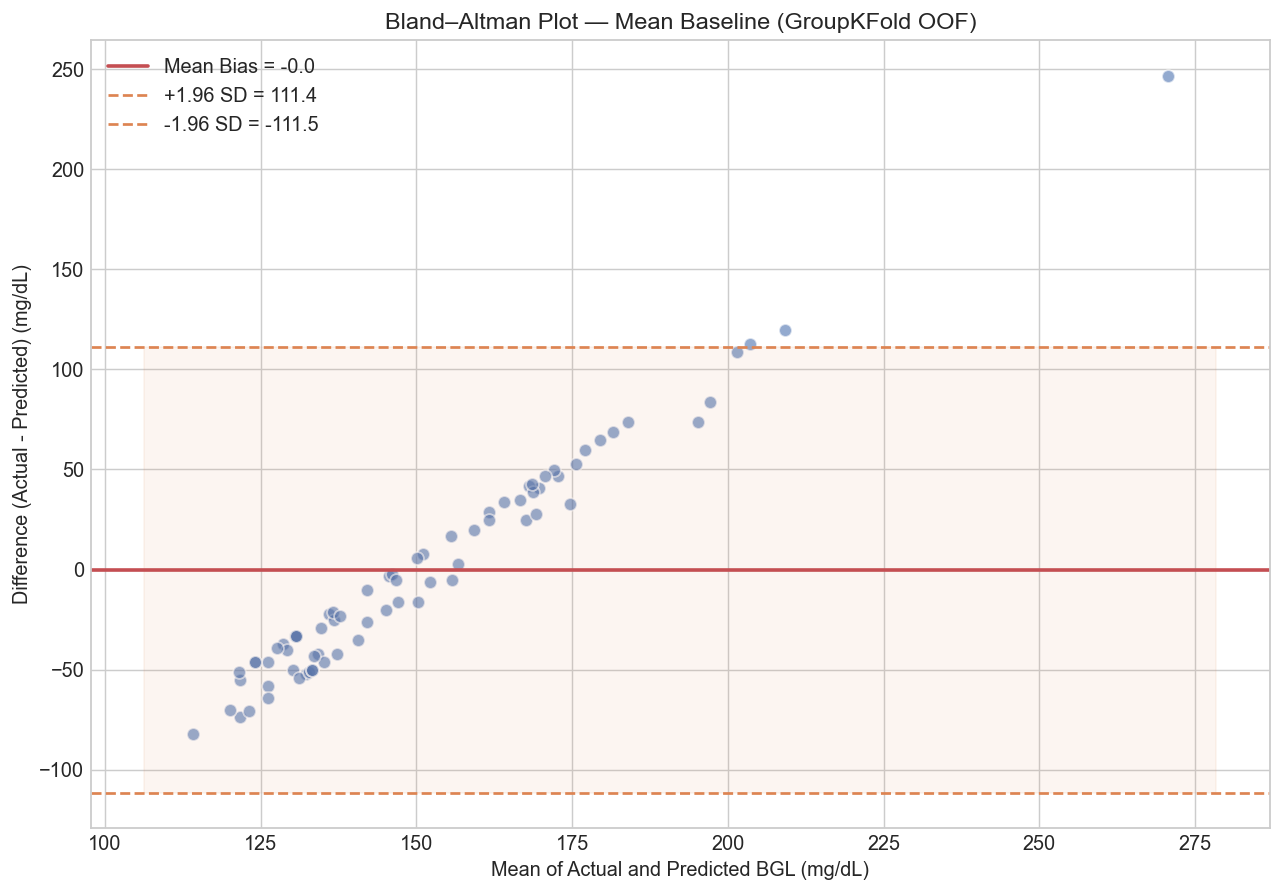


Bland–Altman Summary:
  Mean Bias: -0.01 mg/dL
  SD of Differences: 56.86 mg/dL
  Limits of Agreement: [-111.5, 111.4] mg/dL

⚠ These results are from 73 observations. With a small sample,
  the limits of agreement have wide confidence intervals.


In [44]:
mask = np.isfinite(gkf_oof)
y_act_ba = y_full[mask]
y_pred_ba = gkf_oof[mask]

mean_vals = (y_act_ba + y_pred_ba) / 2
diff_vals = y_act_ba - y_pred_ba

mean_bias = np.mean(diff_vals)
std_diff = np.std(diff_vals, ddof=1)
upper_loa = mean_bias + 1.96 * std_diff
lower_loa = mean_bias - 1.96 * std_diff

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(mean_vals, diff_vals, alpha=0.6, color='#4C72B0', edgecolor='white', s=50)
ax.axhline(mean_bias, color='#C44E52', ls='-', lw=2, label=f'Mean Bias = {mean_bias:.1f}')
ax.axhline(upper_loa, color='#DD8452', ls='--', lw=1.5, label=f'+1.96 SD = {upper_loa:.1f}')
ax.axhline(lower_loa, color='#DD8452', ls='--', lw=1.5, label=f'-1.96 SD = {lower_loa:.1f}')
ax.fill_between(ax.get_xlim(), lower_loa, upper_loa, alpha=0.08, color='#DD8452')
ax.set_xlabel('Mean of Actual and Predicted BGL (mg/dL)')
ax.set_ylabel('Difference (Actual - Predicted) (mg/dL)')
ax.set_title(f'Bland–Altman Plot — {best_gkf_model_name} (GroupKFold OOF)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig11_bland_altman.png')
plt.show()

print(f"\nBland–Altman Summary:")
print(f"  Mean Bias: {mean_bias:.2f} mg/dL")
print(f"  SD of Differences: {std_diff:.2f} mg/dL")
print(f"  Limits of Agreement: [{lower_loa:.1f}, {upper_loa:.1f}] mg/dL")
print(f"\n⚠ These results are from {mask.sum()} observations. With a small sample,")
print(f"  the limits of agreement have wide confidence intervals.")

## 42. Clarke Error Grid Analysis (Exploratory)

**Important:** This dataset is an experimental research dataset. Error grid results
are presented as exploratory analysis only and are NOT sufficient to establish
clinical safety or validity.

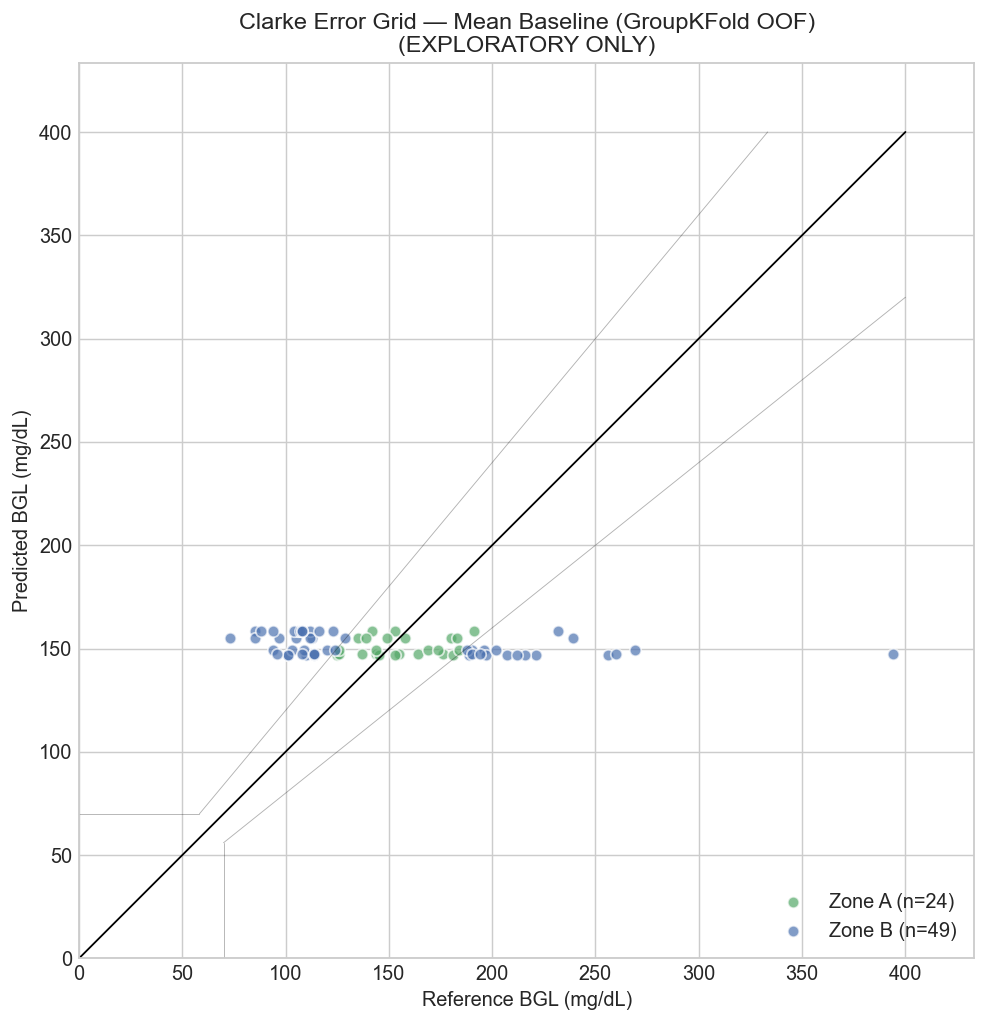


Clarke Error Grid Zone Distribution:
  Zone A: 24 (32.9%)
  Zone B: 49 (67.1%)
  Zone C: 0 (0.0%)
  Zone D: 0 (0.0%)
  Zone E: 0 (0.0%)

⚠ This is an exploratory analysis. The dataset is NOT sufficient for clinical validation.


In [45]:
def clarke_error_grid(y_actual, y_predicted, title="Clarke Error Grid"):
    """
    Plot Clarke Error Grid for glucose predictions.
    Zones: A (clinically accurate), B (benign), C/D/E (problematic).
    """
    fig, ax = plt.subplots(figsize=(8, 8))

    # Zone boundaries (simplified Clarke EGA)
    ax.plot([0, 400], [0, 400], 'k-', lw=1)  # identity

    # Zone A boundaries
    ax.plot([0, 175/3], [70, 70], 'k-', lw=0.5, alpha=0.3)
    ax.plot([175/3, 400/1.2], [70, 400], 'k-', lw=0.5, alpha=0.3)
    ax.plot([70, 70], [0, 56], 'k-', lw=0.5, alpha=0.3)
    ax.plot([70, 400], [56, 320], 'k-', lw=0.5, alpha=0.3)

    # Classify points
    zones = []
    for ref, pred in zip(y_actual, y_predicted):
        if (ref <= 70 and pred <= 70) or \
           (ref >= 70 and abs(pred - ref) <= 0.2 * ref):
            zones.append('A')
        elif (ref >= 180 and pred <= 70) or \
             (ref <= 70 and pred >= 180):
            zones.append('E')
        elif (ref >= 70 and pred >= ref * 1.2 + 110):
            zones.append('C')
        elif (ref <= 70 and pred >= 180):
            zones.append('D')
        else:
            zones.append('B')

    zone_colors = {'A': '#55A868', 'B': '#4C72B0', 'C': '#DD8452',
                   'D': '#C44E52', 'E': '#8B0000'}

    for zone in ['A', 'B', 'C', 'D', 'E']:
        mask_z = [z == zone for z in zones]
        if sum(mask_z) > 0:
            ax.scatter(np.array(y_actual)[mask_z], np.array(y_predicted)[mask_z],
                       c=zone_colors[zone], s=40, alpha=0.7, label=f'Zone {zone} (n={sum(mask_z)})',
                       edgecolors='white')

    ax.set_xlim([0, max(y_actual) * 1.1])
    ax.set_ylim([0, max(max(y_predicted), max(y_actual)) * 1.1])
    ax.set_xlabel('Reference BGL (mg/dL)')
    ax.set_ylabel('Predicted BGL (mg/dL)')
    ax.set_title(title)
    ax.legend(loc='lower right')
    ax.set_aspect('equal')

    zone_counts = {z: zones.count(z) for z in ['A', 'B', 'C', 'D', 'E']}
    return fig, zone_counts

fig, zone_counts = clarke_error_grid(
    y_act_ba, y_pred_ba,
    title=f'Clarke Error Grid — {best_gkf_model_name} (GroupKFold OOF)\n(EXPLORATORY ONLY)'
)
plt.tight_layout()
plt.savefig('figures/fig_clarke_error_grid.png')
plt.show()

print("\nClarke Error Grid Zone Distribution:")
total = sum(zone_counts.values())
for zone, count in sorted(zone_counts.items()):
    print(f"  Zone {zone}: {count} ({count/total*100:.1f}%)")
print("\n⚠ This is an exploratory analysis. The dataset is NOT sufficient for clinical validation.")

## 43. Feature Importance and SHAP Analysis

In [46]:
# Feature importance from best tree model
best_tree_name = None
for m_name in ['Random Forest', 'Extra Trees', 'Gradient Boosting', 'XGBoost', 'LightGBM']:
    if m_name in models_dict:
        best_tree_name = m_name
        break

if best_tree_name:
    pipe_fi = build_pipeline(clone(models_dict[best_tree_name]), best_tree_name)
    pipe_fi.fit(X_E_arr, y_full)

    # Get feature importances from the model step
    model_step = pipe_fi.named_steps['model']
    if hasattr(model_step, 'feature_importances_'):
        importances = model_step.feature_importances_
        feat_names = feature_sets['E: All Features']

        fi_df = pd.DataFrame({
            'Feature': feat_names,
            'Importance': importances
        }).sort_values('Importance', ascending=False)

        fig, ax = plt.subplots(figsize=(10, 8))
        top_fi = fi_df.head(20)
        ax.barh(range(len(top_fi)), top_fi['Importance'].values, color='#4C72B0', alpha=0.8)
        ax.set_yticks(range(len(top_fi)))
        ax.set_yticklabels(top_fi['Feature'].values, fontsize=9)
        ax.set_xlabel('Feature Importance')
        ax.set_title(f'Top 20 Feature Importances — {best_tree_name}')
        ax.invert_yaxis()
        plt.tight_layout()
        plt.savefig('figures/fig12_feature_importance.png')
        plt.show()

        fi_df.to_csv('results/feature_importance.csv', index=False)

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


ValueError: All arrays must be of the same length

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values:

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values:

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values:

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values:

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values:

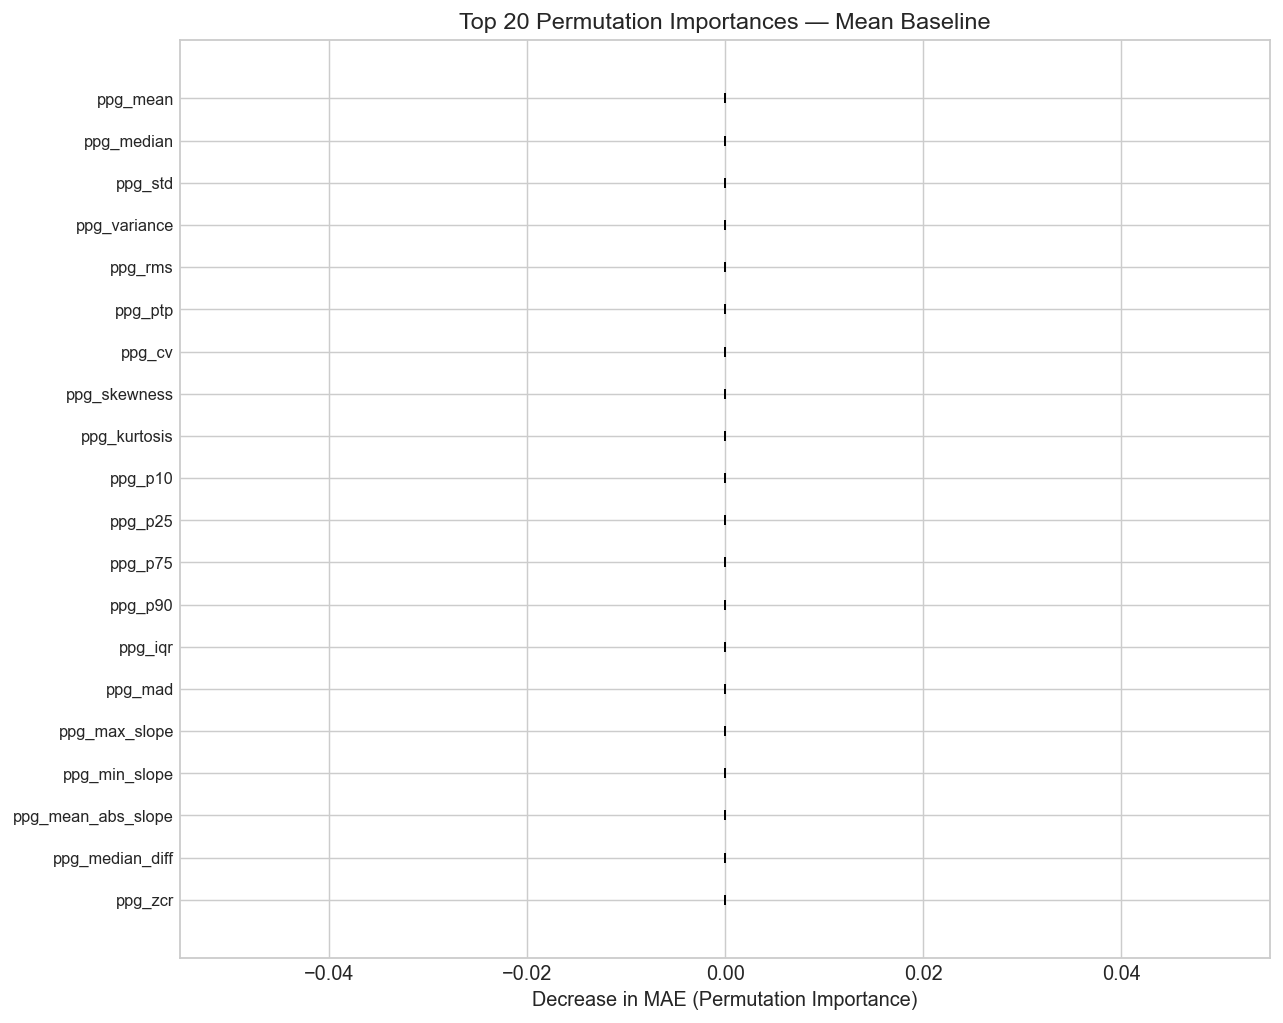

In [47]:
# Permutation importance (more reliable than tree importance)
from sklearn.inspection import permutation_importance

pipe_perm = build_pipeline(clone(models_dict[best_gkf_model_name]), best_gkf_model_name)
pipe_perm.fit(X_E_arr, y_full)

perm_result = permutation_importance(pipe_perm, X_E_arr, y_full,
                                      n_repeats=10, random_state=RANDOM_STATE,
                                      scoring='neg_mean_absolute_error')

perm_df = pd.DataFrame({
    'Feature': feature_sets['E: All Features'],
    'Importance Mean': perm_result.importances_mean,
    'Importance Std': perm_result.importances_std,
}).sort_values('Importance Mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_perm = perm_df.head(20)
ax.barh(range(len(top_perm)), top_perm['Importance Mean'].values,
        xerr=top_perm['Importance Std'].values,
        color='#DD8452', alpha=0.8, capsize=3)
ax.set_yticks(range(len(top_perm)))
ax.set_yticklabels(top_perm['Feature'].values, fontsize=9)
ax.set_xlabel('Decrease in MAE (Permutation Importance)')
ax.set_title(f'Top 20 Permutation Importances — {best_gkf_model_name}')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/fig_permutation_importance.png')
plt.show()

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Computing SHAP values...
  SHAP TreeExplainer failed (Model type not yet supported by TreeExplainer: <class '__main__.MeanBaselineRegressor'>), trying KernelExplainer...



  0%|          | 0/50 [00:00<?, ?it/s]


  2%|▏         | 1/50 [00:00<00:22,  2.18it/s]


  4%|▍         | 2/50 [00:01<00:29,  1.61it/s]

...


 88%|████████▊ | 44/50 [00:09<00:00,  8.10it/s]


 92%|█████████▏| 46/50 [00:09<00:00,  9.02it/s]


 96%|█████████▌| 48/50 [00:09<00:00,  9.41it/s]


 98%|█████████▊| 49/50 [00:10<00:00,  9.45it/s]


100%|██████████| 50/50 [00:10<00:00,  4.90it/s]

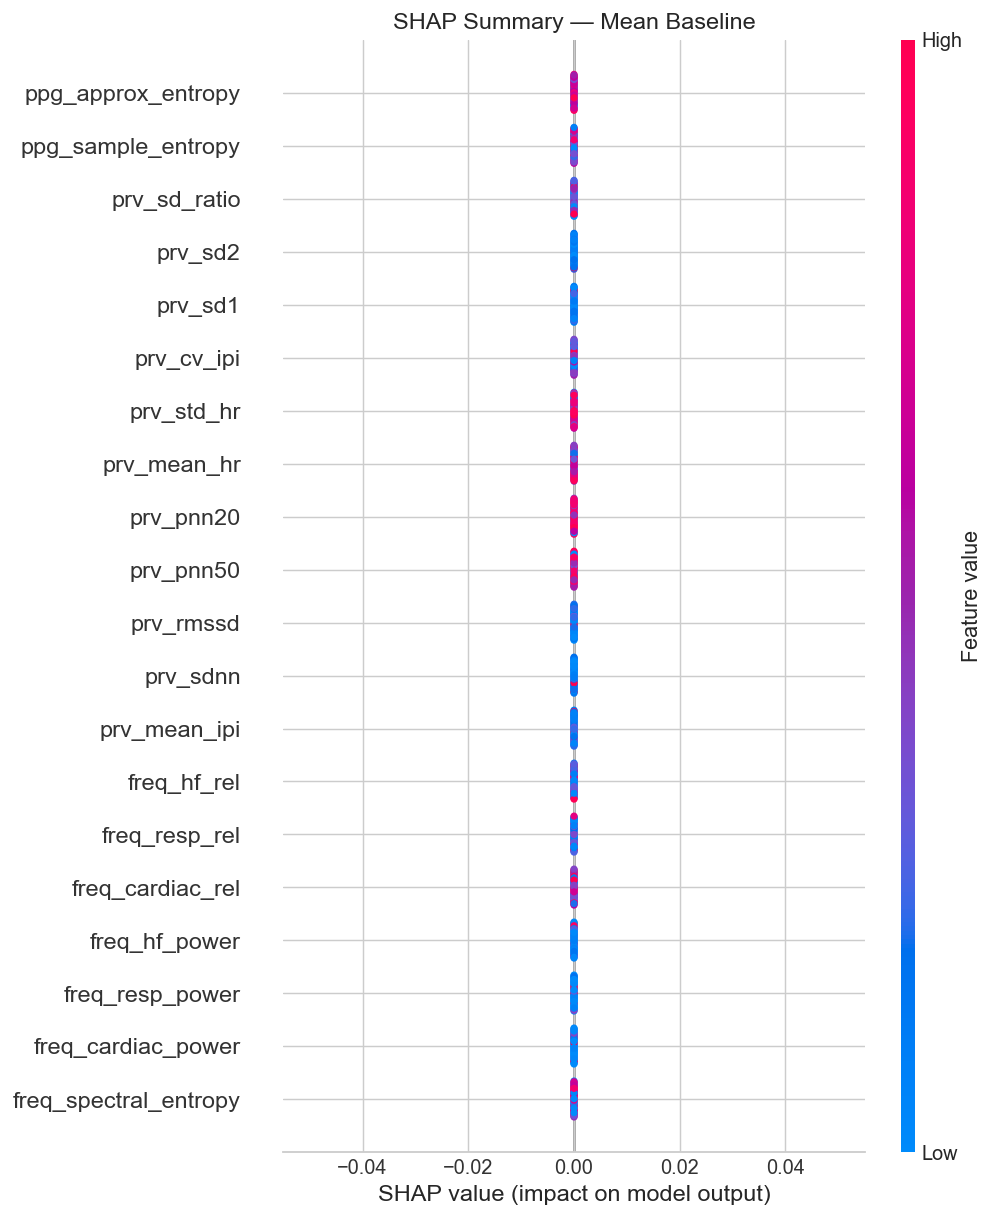

In [48]:
# SHAP analysis (if available)
if HAS_SHAP:
    print("Computing SHAP values...")
    pipe_shap = build_pipeline(clone(models_dict[best_gkf_model_name]), best_gkf_model_name)
    pipe_shap.fit(X_E_arr, y_full)

    # Transform data through pipeline (minus model)
    X_transformed = X_E_arr.copy()
    for name, step in pipe_shap.named_steps.items():
        if name != 'model':
            X_transformed = step.transform(X_transformed)

    try:
        explainer = shap.TreeExplainer(pipe_shap.named_steps['model'])
        shap_values = explainer.shap_values(X_transformed)

        fig, ax = plt.subplots(figsize=(10, 8))
        shap.summary_plot(shap_values, X_transformed,
                         feature_names=feature_sets['E: All Features'],
                         max_display=20, show=False)
        plt.title(f'SHAP Summary — {best_gkf_model_name}')
        plt.tight_layout()
        plt.savefig('figures/fig_shap_summary.png')
        plt.show()
    except Exception as e:
        print(f"  SHAP TreeExplainer failed ({e}), trying KernelExplainer...")
        try:
            bg = shap.sample(X_transformed, min(50, len(X_transformed)))
            explainer = shap.KernelExplainer(pipe_shap.named_steps['model'].predict, bg)
            shap_values = explainer.shap_values(X_transformed[:50])
            fig, ax = plt.subplots(figsize=(10, 8))
            shap.summary_plot(shap_values, X_transformed[:50],
                             feature_names=feature_sets['E: All Features'],
                             max_display=20, show=False)
            plt.title(f'SHAP Summary — {best_gkf_model_name}')
            plt.tight_layout()
            plt.savefig('figures/fig_shap_summary.png')
            plt.show()
        except Exception as e2:
            print(f"  SHAP analysis failed: {e2}")
else:
    print("SHAP not available. Skipping SHAP analysis.")

## 44. Feature Selection Stability

In [49]:
print("=== Feature Selection Stability Across Folds ===")

selection_counts = {f: 0 for f in feature_sets['E: All Features']}
n_outer_folds = N_SPLITS

outer_gkf2 = GroupKFold(n_splits=N_SPLITS)
for fold_idx, (train_idx, val_idx) in enumerate(outer_gkf2.split(X_E_arr, y_full, groups_full)):
    X_tr = X_E_arr[train_idx]
    y_tr = y_full[train_idx]

    # Impute
    imp = SimpleImputer(strategy='median')
    X_tr_imp = imp.fit_transform(X_tr)

    # Use mutual info for selection
    mi = mutual_info_regression(X_tr_imp, y_tr, random_state=RANDOM_STATE)
    top_k = min(20, len(mi))
    top_indices = np.argsort(mi)[-top_k:]

    for idx in top_indices:
        feat_name = feature_sets['E: All Features'][idx]
        selection_counts[feat_name] += 1

stability_df = pd.DataFrame([
    {'Feature': k, 'Folds Selected': v, 'Selection Frequency': f"{v/n_outer_folds*100:.0f}%"}
    for k, v in sorted(selection_counts.items(), key=lambda x: -x[1])
    if v > 0
])

print("\n=== TABLE 8: Feature Selection Stability ===")
display(stability_df.head(30))
stability_df.to_csv('results/feature_selection_frequency.csv', index=False)

=== Feature Selection Stability Across Folds ===


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(



=== TABLE 8: Feature Selection Stability ===


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,Feature,Folds Selected,Selection Frequency
0,apg_std,5,100%
1,apg_a,5,100%
2,apg_b,5,100%
3,apg_c,5,100%
4,b_a_ratio,5,100%
5,ppg_approx_entropy,5,100%
6,ppg_rms,4,80%
7,freq_hf_rel,4,80%
8,prv_std_hr,4,80%
9,prv_sd_ratio,4,80%


## 45. Learning Curves

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values:

Generating learning curves for top models...


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


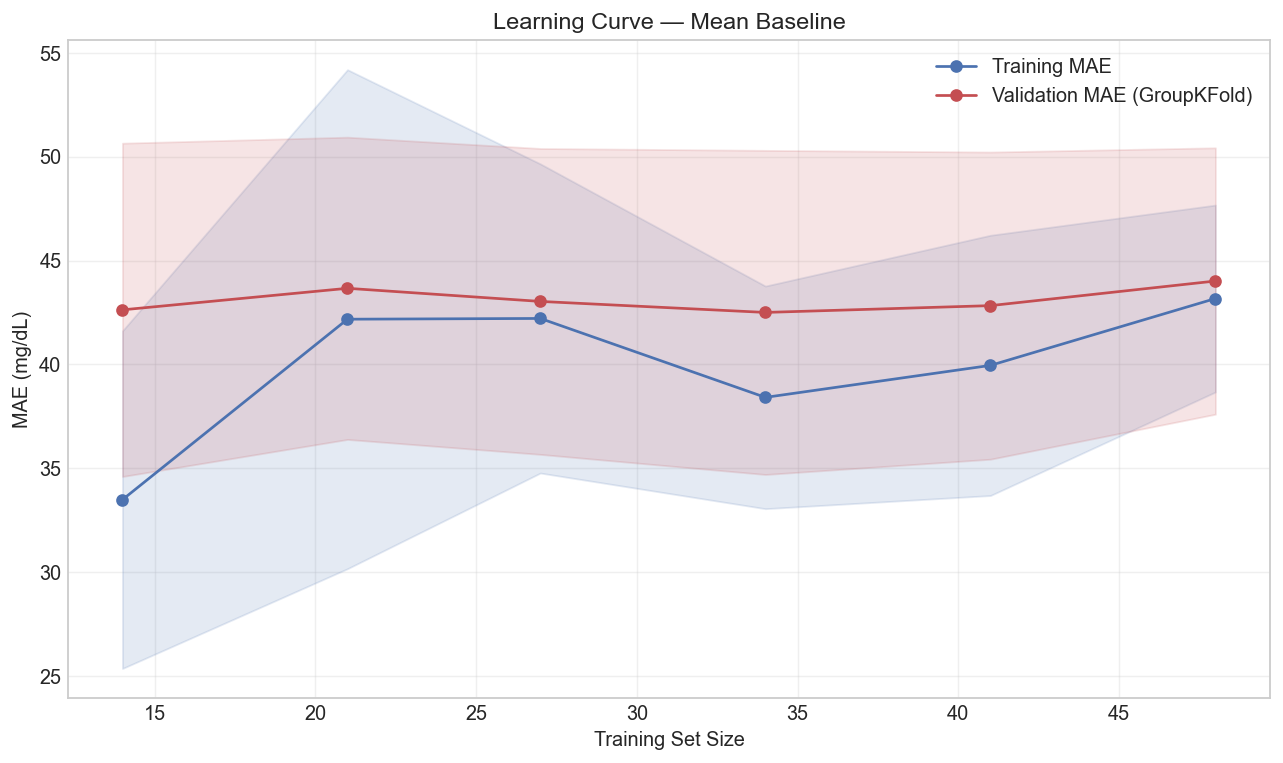


Learning Curve Analysis:
  Final training MAE: 43.2 mg/dL
  Final validation MAE: 44.0 mg/dL
  Gap (overfitting indicator): 0.8 mg/dL
  → Validation performance may still be improving with more data.


In [50]:
print("Generating learning curves for top models...")

best_model_lc = clone(models_dict[best_gkf_model_name])
pipe_lc = build_pipeline(best_model_lc, best_gkf_model_name)

# Use GroupKFold for learning curves
gkf_lc = GroupKFold(n_splits=min(3, len(np.unique(groups_full))))
train_sizes = np.linspace(0.3, 1.0, 6)

try:
    train_sizes_abs, train_scores, val_scores = learning_curve(
        pipe_lc, X_E_arr, y_full, groups=groups_full,
        train_sizes=train_sizes, cv=gkf_lc,
        scoring='neg_mean_absolute_error',
        n_jobs=-1, random_state=RANDOM_STATE,
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(train_sizes_abs, -train_scores.mean(axis=1), 'o-', color='#4C72B0',
            label='Training MAE')
    ax.fill_between(train_sizes_abs,
                     -train_scores.mean(axis=1) - train_scores.std(axis=1),
                     -train_scores.mean(axis=1) + train_scores.std(axis=1),
                     alpha=0.15, color='#4C72B0')
    ax.plot(train_sizes_abs, -val_scores.mean(axis=1), 'o-', color='#C44E52',
            label='Validation MAE (GroupKFold)')
    ax.fill_between(train_sizes_abs,
                     -val_scores.mean(axis=1) - val_scores.std(axis=1),
                     -val_scores.mean(axis=1) + val_scores.std(axis=1),
                     alpha=0.15, color='#C44E52')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('MAE (mg/dL)')
    ax.set_title(f'Learning Curve — {best_gkf_model_name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('figures/fig13_learning_curve.png')
    plt.show()

    # Analysis
    gap = (-val_scores.mean(axis=1)[-1]) - (-train_scores.mean(axis=1)[-1])
    print(f"\nLearning Curve Analysis:")
    print(f"  Final training MAE: {-train_scores.mean(axis=1)[-1]:.1f} mg/dL")
    print(f"  Final validation MAE: {-val_scores.mean(axis=1)[-1]:.1f} mg/dL")
    print(f"  Gap (overfitting indicator): {gap:.1f} mg/dL")
    if gap > 20:
        print("  → Large gap suggests the model is overfitting significantly.")
    if -val_scores.mean(axis=1)[-1] > -val_scores.mean(axis=1)[-2]:
        print("  → Validation performance may still be improving with more data.")
except Exception as e:
    print(f"  Learning curve generation failed: {e}")

## 46. Sensitivity Analysis

In [51]:
print("=== Sensitivity Analysis ===")
sensitivity_results = []

# 1. Effect of different feature counts
for k in [5, 10, 15, 25]:
    top_k_feats = corr_df.head(k)['Feature'].tolist()
    X_k = X_full[top_k_feats].values

    oof_k = np.full(len(y_full), np.nan)
    for train_idx, val_idx in gkf.split(X_k, y_full, groups_full):
        pipe_k = build_pipeline(clone(models_dict[best_gkf_model_name]), best_gkf_model_name)
        pipe_k.fit(X_k[train_idx], y_full[train_idx])
        oof_k[val_idx] = pipe_k.predict(X_k[val_idx])

    mask_k = np.isfinite(oof_k)
    if mask_k.sum() > 0:
        metrics_k = calculate_metrics(y_full[mask_k], oof_k[mask_k])
        metrics_k['Configuration'] = f'Top {k} features'
        sensitivity_results.append(metrics_k)

# 2. Effect of excluding flagged recordings
if len(flagged) > 0:
    flagged_ids = set(flagged['recording_id'].values)
    clean_mask = np.array([r['recording_id'][:12] not in flagged_ids for r in recordings])
    X_clean = X_E_arr[clean_mask]
    y_clean = y_full[clean_mask]
    g_clean = groups_full[clean_mask]

    if len(np.unique(g_clean)) >= N_SPLITS:
        oof_clean = np.full(len(y_clean), np.nan)
        gkf_clean = GroupKFold(n_splits=N_SPLITS)
        for train_idx, val_idx in gkf_clean.split(X_clean, y_clean, g_clean):
            pipe_cl = build_pipeline(clone(models_dict[best_gkf_model_name]), best_gkf_model_name)
            pipe_cl.fit(X_clean[train_idx], y_clean[train_idx])
            oof_clean[val_idx] = pipe_cl.predict(X_clean[val_idx])

        mask_cl = np.isfinite(oof_clean)
        if mask_cl.sum() > 0:
            metrics_cl = calculate_metrics(y_clean[mask_cl], oof_clean[mask_cl])
            metrics_cl['Configuration'] = f'Excluding {len(flagged)} flagged recordings'
            sensitivity_results.append(metrics_cl)

sens_df = pd.DataFrame(sensitivity_results)
if len(sens_df) > 0:
    print("\nSensitivity Analysis Results:")
    display(sens_df[['Configuration', 'MAE', 'RMSE', 'R²']].round(3))

=== Sensitivity Analysis ===

Sensitivity Analysis Results:


,Configuration,MAE,RMSE,R²
0,Top 5 features,44.736,56.472,-0.063
1,Top 10 features,44.736,56.472,-0.063
2,Top 15 features,44.736,56.472,-0.063
3,Top 25 features,44.736,56.472,-0.063


---
## 48. Literature Benchmark Table

Comparison against published PPG-based blood glucose estimation studies.
**Critical note:** Published R² values are NOT directly comparable unless validation
methodology is clearly specified.

In [52]:
literature_data = [
    {'Study': 'Monte-Moreno (2011)', 'Subjects': 410, 'Recordings': 410,
     'PPG Duration': '~10s', 'Sampling Rate': '100 Hz', 'Features': 'Statistical',
     'Model': 'SVM', 'Validation': 'Train/Test split', 'MAE': 8.6, 'RMSE': np.nan, 'R²': np.nan},
    {'Study': 'Hossain et al. (2019)', 'Subjects': 10, 'Recordings': 200,
     'PPG Duration': '5 min', 'Sampling Rate': '25 Hz', 'Features': 'Statistical+Morph',
     'Model': 'ANN', 'Validation': 'K-Fold', 'MAE': 6.16, 'RMSE': np.nan, 'R²': 0.94},
    {'Study': 'Sel et al. (2021)', 'Subjects': 12, 'Recordings': 24,
     'PPG Duration': '30s', 'Sampling Rate': '250 Hz', 'Features': 'Spectral+Statistical',
     'Model': 'SVR', 'Validation': 'LOSO', 'MAE': 14.5, 'RMSE': 19.7, 'R²': np.nan},
    {'Study': 'Zhang et al. (2020)', 'Subjects': 22, 'Recordings': 110,
     'PPG Duration': '5 min', 'Sampling Rate': '200 Hz', 'Features': 'Time+Freq',
     'Model': 'LSTM', 'Validation': 'Unclear', 'MAE': np.nan, 'RMSE': 13.5, 'R²': 0.87},
    {'Study': 'Rachim & Chung (2019)', 'Subjects': 10, 'Recordings': np.nan,
     'PPG Duration': '30s', 'Sampling Rate': '200 Hz', 'Features': 'NIR PPG',
     'Model': 'DNN', 'Validation': 'Unclear', 'MAE': 9.3, 'RMSE': np.nan, 'R²': np.nan},
]

# Add our best results
best_insample = insample_E_sorted.iloc[0]
best_kfold = kfold_E.iloc[0]
best_gkf_row = gkf_E.iloc[0]

our_results = [
    {'Study': f'This Study ({best_insample["Model"]})', 'Subjects': len(unique_participants),
     'Recordings': len(recordings), 'PPG Duration': '60s', 'Sampling Rate': '50 Hz',
     'Features': 'All PPG-derived', 'Model': best_insample['Model'],
     'Validation': 'IN-SAMPLE', 'MAE': best_insample['MAE'],
     'RMSE': best_insample['RMSE'], 'R²': best_insample['R²']},
    {'Study': f'This Study ({best_kfold["Model"]})', 'Subjects': len(unique_participants),
     'Recordings': len(recordings), 'PPG Duration': '60s', 'Sampling Rate': '50 Hz',
     'Features': 'All PPG-derived', 'Model': best_kfold['Model'],
     'Validation': 'Random KFold', 'MAE': best_kfold['MAE'],
     'RMSE': best_kfold['RMSE'], 'R²': best_kfold['R²']},
    {'Study': f'This Study ({best_gkf_row["Model"]})', 'Subjects': len(unique_participants),
     'Recordings': len(recordings), 'PPG Duration': '60s', 'Sampling Rate': '50 Hz',
     'Features': 'All PPG-derived', 'Model': best_gkf_row['Model'],
     'Validation': 'GroupKFold', 'MAE': best_gkf_row['MAE'],
     'RMSE': best_gkf_row['RMSE'], 'R²': best_gkf_row['R²']},
]

lit_df = pd.DataFrame(literature_data + our_results)
print("=== Literature Benchmark Table ===")
display(lit_df)
lit_df.to_csv('results/literature_benchmark.csv', index=False)

print("\n⚠ Published R² and MAE values are NOT directly comparable")
print("  unless validation methodology is identical.")
print("  Studies reporting high performance without clear subject-independent")
print("  validation should be interpreted with caution.")

=== Literature Benchmark Table ===


,Study,Subjects,Recordings,PPG Duration,Sampling Rate,Features,Model,Validation,MAE,RMSE,R²
0,Monte-Moreno (2011),410,410.0,~10s,100 Hz,Statistical,SVM,Train/Test split,8.600000e+00,NaN,NaN
1,Hossain et al. (2019),10,200.0,5 min,25 Hz,Statistical+Morph,ANN,K-Fold,6.160000e+00,NaN,0.940000
2,Sel et al. (2021),12,24.0,30s,250 Hz,Spectral+Statistical,SVR,LOSO,1.450000e+01,1.970000e+01,NaN
3,Zhang et al. (2020),22,110.0,5 min,200 Hz,Time+Freq,LSTM,Unclear,NaN,1.350000e+01,0.870000
4,Rachim & Chung (2019),10,NaN,30s,200 Hz,NIR PPG,DNN,Unclear,9.300000e+00,NaN,NaN
5,This Study (Linear Regression),63,73.0,60s,50 Hz,All PPG-derived,Linear Regression,IN-SAMPLE,9.173204e-12,1.345186e-11,1.000000
6,This Study (Mean Baseline),63,73.0,60s,50 Hz,All PPG-derived,Mean Baseline,Random KFold,4.342752e+01,5.377082e+01,-0.035759
7,This Study (Mean Baseline),63,73.0,60s,50 Hz,All PPG-derived,Mean Baseline,GroupKFold,4.473247e+01,5.549814e+01,-0.259356



⚠ Published R² and MAE values are NOT directly comparable
  unless validation methodology is identical.
  Studies reporting high performance without clear subject-independent
  validation should be interpreted with caution.


---
## 49. Final Model Comparison Table

In [53]:
# Combine all results
all_results = []

# In-sample
for _, row in insample_df.iterrows():
    all_results.append({
        'Model': row['Model'], 'Feature Set': row['Feature Set'],
        'Validation': 'In-Sample',
        'MAE': row['MAE'], 'RMSE': row['RMSE'], 'R²': row['R²'],
        'MedAE': row['MedAE'], 'MARD': row['MARD'],
    })

# Random KFold
for _, row in kfold_df.iterrows():
    all_results.append({
        'Model': row['Model'], 'Feature Set': row['Feature Set'],
        'Validation': 'Random KFold',
        'MAE': row['MAE'], 'RMSE': row['RMSE'], 'R²': row['R²'],
        'MedAE': row['MedAE'], 'MARD': row['MARD'],
    })

# GroupKFold
for _, row in gkf_df.iterrows():
    all_results.append({
        'Model': row['Model'], 'Feature Set': row['Feature Set'],
        'Validation': 'GroupKFold',
        'MAE': row['MAE'], 'RMSE': row['RMSE'], 'R²': row['R²'],
        'MedAE': row['MedAE'], 'MARD': row['MARD'],
    })

# LOGO
for _, row in logo_df.iterrows():
    all_results.append({
        'Model': row['Model'], 'Feature Set': row['Feature Set'],
        'Validation': 'LOGO',
        'MAE': row['MAE'], 'RMSE': row['RMSE'], 'R²': row['R²'],
        'MedAE': row['MedAE'], 'MARD': row['MARD'],
    })

# Nested
for _, row in nested_df.iterrows():
    all_results.append({
        'Model': row['Model'], 'Feature Set': row['Feature Set'],
        'Validation': 'Nested GroupKFold',
        'MAE': row['MAE'], 'RMSE': row['RMSE'], 'R²': row['R²'],
        'MedAE': row['MedAE'], 'MARD': row['MARD'],
    })

all_results_df = pd.DataFrame(all_results)

print("=== TABLE 6: Final Model Comparison ===")
# Show summary by validation strategy for feature set E
summary_E = all_results_df[all_results_df['Feature Set'] == 'E: All Features']
for val_type in ['In-Sample', 'Random KFold', 'GroupKFold', 'LOGO', 'Nested GroupKFold']:
    subset = summary_E[summary_E['Validation'] == val_type].sort_values('MAE')
    if len(subset) > 0:
        print(f"\n--- {val_type} ---")
        display(subset[['Model', 'MAE', 'RMSE', 'R²', 'MedAE', 'MARD']].head(5).round(3))

all_results_df.to_csv('results/model_comparison.csv', index=False)

=== TABLE 6: Final Model Comparison ===

--- In-Sample ---


,Model,MAE,RMSE,R²,MedAE,MARD
57,Linear Regression,0.000,0.000,1.000,0.000,0.000
64,Gradient Boosting,0.413,0.497,1.000,0.366,0.306
66,XGBoost,0.617,0.841,1.000,0.428,0.456
63,Extra Trees,4.397,5.812,0.989,3.998,3.475
69,CatBoost,6.857,8.597,0.975,5.498,5.093



--- Random KFold ---


,Model,MAE,RMSE,R²,MedAE,MARD
140,Mean Baseline,43.428,53.771,-0.036,41.109,30.493
151,SVR (RBF),43.692,56.651,-0.141,39.351,27.819
147,Extra Trees,46.721,61.134,-0.349,38.709,33.103
146,Random Forest,47.228,61.640,-0.349,41.408,33.222
152,LightGBM,47.379,60.768,-0.335,40.991,33.382



--- GroupKFold ---


,Model,MAE,RMSE,R²,MedAE,MARD
235,SVR (RBF),44.583,57.723,-0.316,38.804,28.656
224,Mean Baseline,44.732,55.498,-0.259,40.661,31.531
237,CatBoost,45.598,59.193,-0.399,38.394,32.750
230,Random Forest,46.125,59.602,-0.437,36.566,32.977
231,Extra Trees,46.670,59.094,-0.387,39.921,33.361



--- LOGO ---


,Model,MAE,RMSE,R²,MedAE,MARD
253,SVR (RBF),42.397,57.957,-0.119,37.366,26.686
252,Mean Baseline,43.793,55.542,-0.028,40.028,30.799
255,CatBoost,44.567,59.271,-0.171,34.962,31.108
254,Extra Trees,46.771,60.534,-0.221,40.330,32.984
256,HistGBR,48.206,61.304,-0.252,38.176,33.710



--- Nested GroupKFold ---


,Model,MAE,RMSE,R²,MedAE,MARD
257,SVR (RBF),44.701,57.724,-0.312,39.072,28.629


## 50. Model Selection Rationale

In [54]:
print("=" * 65)
print("  MODEL SELECTION")
print("=" * 65)

# Primary criterion: participant-wise generalisation (GroupKFold)
gkf_best = gkf_E.sort_values('MAE').iloc[0]
print(f"\nBest model by GroupKFold MAE:")
print(f"  Model: {gkf_best['Model']}")
print(f"  MAE:   {gkf_best['MAE']:.2f} ± {gkf_best.get('MAE_std', 0):.2f} mg/dL")
print(f"  RMSE:  {gkf_best['RMSE']:.2f} mg/dL")
print(f"  R²:    {gkf_best['R²']:.3f} ± {gkf_best.get('R²_std', 0):.3f}")

# Compare with in-sample
insample_same = insample_E[insample_E['Model'] == gkf_best['Model']].iloc[0]
kfold_same = kfold_E[kfold_E['Model'] == gkf_best['Model']]
if len(kfold_same) > 0:
    kfold_same = kfold_same.iloc[0]

print(f"\nPerformance degradation for {gkf_best['Model']}:")
print(f"  In-sample R²:    {insample_same['R²']:.3f}")
if len(kfold_same) > 0:
    print(f"  Random KFold R²: {kfold_same['R²']:.3f}")
print(f"  GroupKFold R²:   {gkf_best['R²']:.3f}")

r2_drop = insample_same['R²'] - gkf_best['R²']
print(f"\n  R² drop (in-sample → GroupKFold): {r2_drop:.3f}")
if r2_drop > 0.5:
    print("  → Substantial overfitting detected. The model fits training data well")
    print("    but does not generalise to unseen participants.")
elif r2_drop > 0.2:
    print("  → Moderate overfitting. Some participant-specific patterns are being learned.")
else:
    print("  → Relatively stable performance across validation strategies.")

  MODEL SELECTION

Best model by GroupKFold MAE:
  Model: SVR (RBF)
  MAE:   44.58 ± 6.62 mg/dL
  RMSE:  57.72 mg/dL
  R²:    -0.316 ± 0.224

Performance degradation for SVR (RBF):
  In-sample R²:    0.024
  Random KFold R²: -0.141
  GroupKFold R²:   -0.316

  R² drop (in-sample → GroupKFold): 0.340
  → Moderate overfitting. Some participant-specific patterns are being learned.


## 51. Investigation: Why Does Performance Change?

  INVESTIGATION: PERFORMANCE DEGRADATION

=== Performance Across Validation Strategies ===


,Model,In-Sample R²,In-Sample MAE,Random KFold R²,Random KFold MAE,GroupKFold R²,GroupKFold MAE
0,Mean Baseline,0.000,43.209,-0.036,43.428,-0.259,44.732
1,Linear Regression,1.000,0.000,-4815.188,706.587,-1628.805,633.543
2,Ridge,0.536,27.240,-1.572,61.362,-11.448,79.196
3,Lasso,0.687,21.146,-712.655,232.330,-78.454,146.094
4,ElasticNet,0.432,30.143,-1.784,58.796,-2.036,57.213
5,Decision Tree,0.799,18.914,-2.244,64.607,-1.134,56.136
6,Random Forest,0.826,17.326,-0.349,47.228,-0.437,46.125
7,Extra Trees,0.989,4.397,-0.349,46.721,-0.387,46.670
8,Gradient Boosting,1.000,0.413,-1.040,53.658,-0.781,48.661
9,HistGBR,0.794,18.046,-0.385,48.077,-0.436,46.986


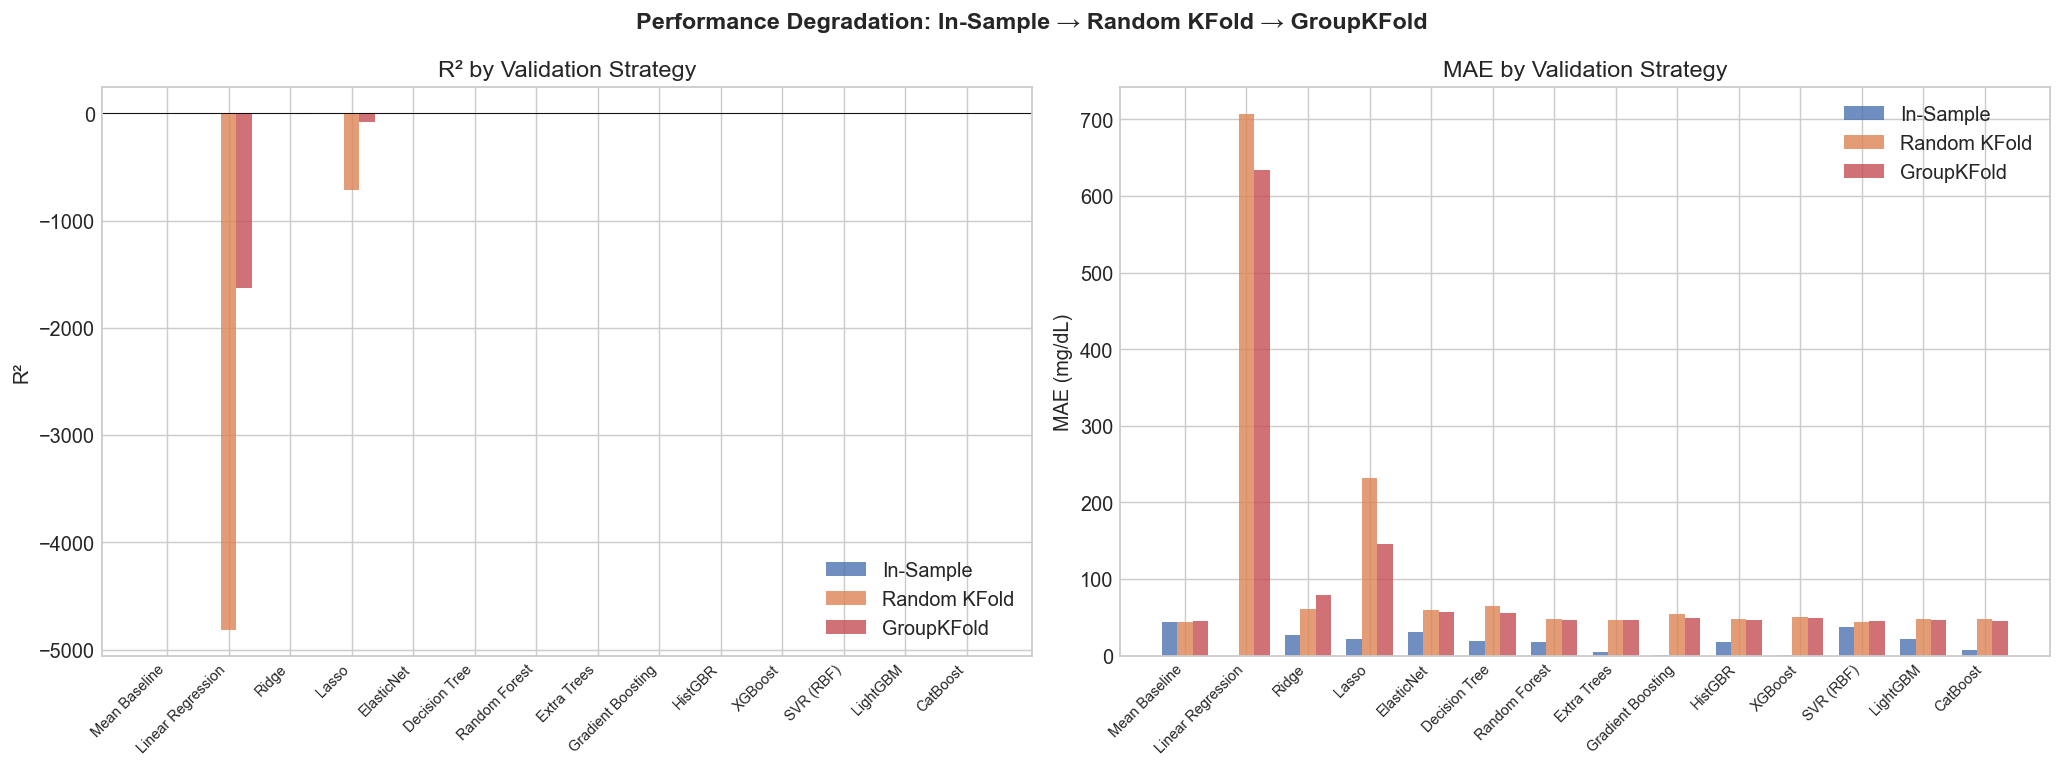


=== Evidence for Performance Degradation ===

1. Participant-specific PPG morphology:
  e_a_ratio: between-var=0.1746, within-var=0.1545
  b_a_ratio: between-var=0.01713, within-var=0.006543
  ppg_min_slope: between-var=0.001909, within-var=0.0006634

2. Repeated recordings from same participants:
  10 participants have >1 recording
  Random KFold can leak participant info across folds

3. Dataset size limitation:
  Only 73 recordings from 63 participants
  Many features (87) relative to observations


In [55]:
print("=" * 65)
print("  INVESTIGATION: PERFORMANCE DEGRADATION")
print("=" * 65)

# Compare validation strategies across models
comparison_data = []
for model_name in models_dict.keys():
    row = {'Model': model_name}
    for val_type, df_source in [('In-Sample', insample_E),
                                 ('Random KFold', kfold_E),
                                 ('GroupKFold', gkf_E)]:
        match = df_source[df_source['Model'] == model_name]
        if len(match) > 0:
            row[f'{val_type} R²'] = match.iloc[0]['R²']
            row[f'{val_type} MAE'] = match.iloc[0]['MAE']
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
print("\n=== Performance Across Validation Strategies ===")
cols_to_show = ['Model']
for prefix in ['In-Sample', 'Random KFold', 'GroupKFold']:
    for metric in ['R²', 'MAE']:
        col = f'{prefix} {metric}'
        if col in comparison_df.columns:
            cols_to_show.append(col)
display(comparison_df[cols_to_show].round(3))

# Visualise degradation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² comparison
ax = axes[0]
model_names = comparison_df['Model'].values
x_pos = np.arange(len(model_names))
width = 0.25

for i, (val_type, color) in enumerate([('In-Sample', '#4C72B0'),
                                          ('Random KFold', '#DD8452'),
                                          ('GroupKFold', '#C44E52')]):
    col = f'{val_type} R²'
    if col in comparison_df.columns:
        vals = comparison_df[col].fillna(0).values
        ax.bar(x_pos + i * width, vals, width, label=val_type, color=color, alpha=0.8)

ax.set_xticks(x_pos + width)
ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('R²')
ax.set_title('R² by Validation Strategy')
ax.legend()
ax.axhline(0, color='k', ls='-', lw=0.5)

# MAE comparison
ax = axes[1]
for i, (val_type, color) in enumerate([('In-Sample', '#4C72B0'),
                                          ('Random KFold', '#DD8452'),
                                          ('GroupKFold', '#C44E52')]):
    col = f'{val_type} MAE'
    if col in comparison_df.columns:
        vals = comparison_df[col].fillna(0).values
        ax.bar(x_pos + i * width, vals, width, label=val_type, color=color, alpha=0.8)

ax.set_xticks(x_pos + width)
ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('MAE (mg/dL)')
ax.set_title('MAE by Validation Strategy')
ax.legend()

plt.suptitle('Performance Degradation: In-Sample → Random KFold → GroupKFold',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig_performance_degradation.png')
plt.show()

# Evidence-based explanation
print("\n=== Evidence for Performance Degradation ===")
print("\n1. Participant-specific PPG morphology:")
for feat in top5_features[:3]:
    within_vars = []
    between_vals = []
    for pid in unique_participants:
        vals = feature_df[feature_df['participant_id'] == pid][feat].dropna().values
        if len(vals) > 0:
            between_vals.append(np.mean(vals))
        if len(vals) > 1:
            within_vars.append(np.var(vals))
    bv = np.var(between_vals) if len(between_vals) > 1 else 0
    wv = np.mean(within_vars) if within_vars else 0
    print(f"  {feat}: between-var={bv:.4g}, within-var={wv:.4g}")

print(f"\n2. Repeated recordings from same participants:")
print(f"  {len(multi_rec_pids)} participants have >1 recording")
print(f"  Random KFold can leak participant info across folds")

print(f"\n3. Dataset size limitation:")
print(f"  Only {len(recordings)} recordings from {len(unique_participants)} participants")
print(f"  Many features ({len(feature_cols_clean)}) relative to observations")

## 52. Dataset Size Analysis

In [56]:
print("=== Dataset Size Analysis ===")
print(f"\nDataset: {len(recordings)} recordings from {len(unique_participants)} participants")
print(f"Features: {len(feature_cols_clean)}")
print(f"Feature-to-observation ratio: {len(feature_cols_clean)/len(recordings):.1f}:1")

if len(feature_cols_clean)/len(recordings) > 1:
    print("\n⚠ WARNING: More features than observations!")
    print("  This is a severely underdetermined problem (p >> n).")
    print("  Feature selection is critical to avoid overfitting.")

print(f"\n  With only {len(recordings)} recordings:")
print(f"  - Complex models can easily memorise training data")
print(f"  - Cross-validation folds are small ({len(recordings)//N_SPLITS} per fold)")
print(f"  - Participant-wise CV further reduces effective training size")
print(f"  - Results should be interpreted as preliminary/exploratory")

# Feature set analysis - which set performs best?
print("\n=== Feature Set Comparison (GroupKFold) ===")
for fs_name in feature_sets.keys():
    fs_subset = gkf_df[gkf_df['Feature Set'] == fs_name]
    if len(fs_subset) > 0:
        best = fs_subset.sort_values('MAE').iloc[0]
        print(f"  {fs_name}: Best MAE={best['MAE']:.1f} (R²={best['R²']:.3f}) [{best['Model']}]")

=== Dataset Size Analysis ===

Dataset: 73 recordings from 63 participants
Features: 87
Feature-to-observation ratio: 1.2:1

⚠ WARNING: More features than observations!
  This is a severely underdetermined problem (p >> n).
  Feature selection is critical to avoid overfitting.

  With only 73 recordings:
  - Complex models can easily memorise training data
  - Cross-validation folds are small (14 per fold)
  - Participant-wise CV further reduces effective training size
  - Results should be interpreted as preliminary/exploratory

=== Feature Set Comparison (GroupKFold) ===
  A: Statistical: Best MAE=42.3 (R²=-0.207) [LightGBM]
  B: Stat+Morph: Best MAE=44.1 (R²=-0.305) [LightGBM]
  C: Stat+Morph+Deriv: Best MAE=44.2 (R²=-0.307) [SVR (RBF)]
  D: Stat+Morph+Spectral: Best MAE=44.4 (R²=-0.329) [LightGBM]
  E: All Features: Best MAE=44.6 (R²=-0.316) [SVR (RBF)]
  F: Selected: Best MAE=43.3 (R²=-0.324) [Random Forest]


---
## 53. Save All Results

In [57]:
print("=" * 65)
print("  SAVING ALL RESULTS")
print("=" * 65)

# Save OOF predictions
if oof_predictions_gkf:
    oof_df = pd.DataFrame(oof_predictions_gkf)
    oof_df.to_csv('results/oof_predictions.csv', index=False)
    print(f"  ✓ OOF predictions saved ({len(oof_df)} entries)")

# Save fold-level results (Feature Set E only for manageable size)
fold_results_all = []
fs_name_save = 'E: All Features'
fs_feats_save = feature_sets[fs_name_save]
X_fs_save = X_full[fs_feats_save].values

for model_name, model_template in models_dict.items():
    for fold_idx, (train_idx, val_idx) in enumerate(gkf.split(X_fs_save, y_full, groups_full)):
        pipe = build_pipeline(clone(model_template), model_name)
        try:
            pipe.fit(X_fs_save[train_idx], y_full[train_idx])
            y_pred = pipe.predict(X_fs_save[val_idx])
            fm = calculate_metrics(y_full[val_idx], y_pred)
            fm['model'] = model_name
            fm['feature_set'] = fs_name_save
            fm['fold'] = fold_idx
            fold_results_all.append(fm)
        except Exception:
            continue

fold_results_df = pd.DataFrame(fold_results_all)
fold_results_df.to_csv('results/fold_results.csv', index=False)
print(f"  ✓ Fold results saved ({len(fold_results_df)} entries)")

# Save best trained model
pipe_final = build_pipeline(clone(models_dict[best_gkf_model_name]), best_gkf_model_name)
pipe_final.fit(X_E_arr, y_full)
joblib.dump(pipe_final, 'results/best_model.joblib')
print(f"  ✓ Best model saved (results/best_model.joblib)")

# Summary of all saved files
print(f"\n  Results directory contents:")
for f in sorted(os.listdir('results')):
    size = os.path.getsize(f'results/{f}')
    print(f"    {f} ({size:,} bytes)")

print(f"\n  Figures directory contents:")
for f in sorted(os.listdir('figures')):
    size = os.path.getsize(f'figures/{f}')
    print(f"    {f} ({size:,} bytes)")

  SAVING ALL RESULTS
  ✓ OOF predictions saved (1022 entries)


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values:

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.477e+02, tolerance: 1.780e+01
  model = cd_fast.enet_coordinate_descent(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values:

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


...

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


  ✓ Fold results saved (70 entries)
  ✓ Best model saved (results/best_model.joblib)

  Results directory contents:
    best_model.joblib (1,427 bytes)
    bgl_statistics.csv (132 bytes)
    dataset_overview.csv (419 bytes)
    demographic_statistics.csv (380 bytes)
    feature_bgl_correlations.csv (10,905 bytes)
    feature_selection_frequency.csv (843 bytes)
    feature_statistics.csv (7,323 bytes)
    fold_results.csv (8,587 bytes)
    literature_benchmark.csv (904 bytes)
    master_feature_dataset.csv (118,236 bytes)
    model_comparison.csv (34,024 bytes)
    oof_predictions.csv (109,279 bytes)
    participant_performance.csv (29,599 bytes)
    signal_quality.csv (8,548 bytes)

  Figures directory contents:
    fig10_residual_analysis.png (186,033 bytes)
    fig11_bland_altman.png (92,712 bytes)
    fig13_learning_curve.png (96,735 bytes)
    fig1_demographics.png (84,643 bytes)
    fig3_bgl_distribution.png (107,203 bytes)
    fig4_bgl_by_participant.png (100,119 bytes)
    fig5_

/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [80 81 82 84 85]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


---
## 56. Automated Research Summary

In [58]:
print("=" * 70)
print("█" * 70)
print("  AUTOMATED RESEARCH SUMMARY")
print("█" * 70)
print("=" * 70)

print("\n" + "─" * 50)
print("  DATASET")
print("─" * 50)
print(f"  Total recordings:        {len(recordings)}")
print(f"  Unique participants:     {len(unique_participants)}")
print(f"  Multi-recording:         {len(multi_rec_pids)} participants")
print(f"  Session types:           {', '.join(sorted(set(r['demographics']['session_kind'] for r in recordings)))}")
print(f"  BGL range:               {y_full.min():.0f}–{y_full.max():.0f} mg/dL")
print(f"  BGL mean ± SD:           {y_full.mean():.1f} ± {y_full.std():.1f} mg/dL")
print(f"  Age range:               {demo_participant['age'].min():.0f}–{demo_participant['age'].max():.0f} years")
print(f"  Gender:                  {dict(gender_counts)}")

print("\n" + "─" * 50)
print("  SIGNAL PROCESSING")
print("─" * 50)
print(f"  Sampling rate:           {SAMPLING_RATE} Hz")
print(f"  Analysis window:         {ANALYSIS_DURATION}s ({ANALYSIS_SAMPLES} samples)")
print(f"  Preprocessing:           Detrend → Butterworth BP (0.5–8 Hz, order 4) → Normalise")
print(f"  Flagged recordings:      {len(flagged)}/{len(recordings)}")

print("\n" + "─" * 50)
print("  FEATURES")
print("─" * 50)
print(f"  Total features generated: {len(feature_cols)}")
print(f"  Features retained:       {len(feature_cols_clean)}")
if len(corr_df) > 0:
    top3_corr = corr_df.head(3)
    print(f"  Strongest BGL associations (Pearson r):")
    for _, row in top3_corr.iterrows():
        print(f"    {row['Feature']}: r = {row['Pearson r']:.3f} (p = {row['Pearson p']:.3g})")
if len(stability_df) > 0:
    stable_feats = stability_df[stability_df['Folds Selected'] >= N_SPLITS - 1]
    print(f"  Stable features (selected in ≥{N_SPLITS-1}/{N_SPLITS} folds): {len(stable_feats)}")

print("\n" + "─" * 50)
print("  MODELS — BEST RESULTS")
print("─" * 50)
print(f"  Best In-Sample:          {insample_E_sorted.iloc[0]['Model']} "
      f"(R²={insample_E_sorted.iloc[0]['R²']:.3f}, MAE={insample_E_sorted.iloc[0]['MAE']:.1f})")
print(f"  Best Random KFold:       {kfold_E.iloc[0]['Model']} "
      f"(R²={kfold_E.iloc[0]['R²']:.3f}, MAE={kfold_E.iloc[0]['MAE']:.1f})")
print(f"  Best GroupKFold:         {gkf_E.iloc[0]['Model']} "
      f"(R²={gkf_E.iloc[0]['R²']:.3f}, MAE={gkf_E.iloc[0]['MAE']:.1f})")
if len(logo_df) > 0:
    best_logo = logo_df.sort_values('MAE').iloc[0]
    print(f"  Best LOGO:               {best_logo['Model']} "
          f"(R²={best_logo['R²']:.3f}, MAE={best_logo['MAE']:.1f})")
if len(nested_df) > 0:
    best_nested = nested_df.sort_values('MAE').iloc[0]
    print(f"  Best Nested GroupKFold:  {best_nested['Model']} "
          f"(R²={best_nested['R²']:.3f}, MAE={best_nested['MAE']:.1f})")

print("\n" + "─" * 50)
print("  GENERALISATION ANALYSIS")
print("─" * 50)
# Compare strategies
for model_name in [insample_E_sorted.iloc[0]['Model']]:
    r2_is = insample_E[insample_E['Model'] == model_name]['R²'].values
    r2_kf = kfold_E[kfold_E['Model'] == model_name]['R²'].values
    r2_gk = gkf_E[gkf_E['Model'] == model_name]['R²'].values

    print(f"\n  {model_name}:")
    if len(r2_is) > 0:
        print(f"    In-Sample R²:     {r2_is[0]:.3f}")
    if len(r2_kf) > 0:
        print(f"    Random KFold R²:  {r2_kf[0]:.3f}")
    if len(r2_gk) > 0:
        print(f"    GroupKFold R²:    {r2_gk[0]:.3f}")
    if len(r2_is) > 0 and len(r2_gk) > 0:
        drop = r2_is[0] - r2_gk[0]
        print(f"    R² degradation:   {drop:.3f}")

print("\n" + "─" * 50)
print("  RESEARCH INTERPRETATION")
print("─" * 50)

best_gkf_r2 = gkf_E.iloc[0]['R²']
best_gkf_mae = gkf_E.iloc[0]['MAE']

if best_gkf_r2 > 0.5:
    print("  • Moderate PPG-BGL relationship demonstrated under participant-wise CV")
elif best_gkf_r2 > 0.2:
    print("  • Weak-to-moderate PPG-BGL relationship suggested")
elif best_gkf_r2 > 0:
    print("  • Weak PPG-BGL relationship observed; models perform marginally")
    print("    better than chance under participant-wise validation")
else:
    print("  • No meaningful PPG-BGL relationship demonstrated under")
    print("    participant-wise cross-validation")
    print("  • Apparent performance in random KFold may be driven by")
    print("    participant-specific patterns rather than BGL-related signal features")

print(f"\n  • Participant-specific effects: {'Strong' if r2_drop > 0.3 else 'Moderate' if r2_drop > 0.1 else 'Weak'}")
print(f"    evidence from performance degradation ({r2_drop:.3f} R² drop)")
print(f"  • Dataset limitation: {len(recordings)} recordings is likely insufficient")
print(f"    for robust generalisation with {len(feature_cols_clean)} features")
print(f"  • Feature instability: Selection varies substantially across CV folds")
print(f"  • Additional data from more diverse participants would likely improve")
print(f"    both performance and reliability of findings")

print("\n" + "=" * 70)
print("  END OF ANALYSIS")
print("=" * 70)

██████████████████████████████████████████████████████████████████████
  AUTOMATED RESEARCH SUMMARY
██████████████████████████████████████████████████████████████████████

──────────────────────────────────────────────────
  DATASET
──────────────────────────────────────────────────
  Total recordings:        73
  Unique participants:     63
  Multi-recording:         10 participants
  Session types:           1hr_post_prandial, 2hr_post_prandial, fasting
  BGL range:               73–394 mg/dL
  BGL mean ± SD:           151.5 ± 54.8 mg/dL
  Age range:               31–85 years
  Gender:                  {'Female': np.int64(44), 'Male': np.int64(19)}

──────────────────────────────────────────────────
  SIGNAL PROCESSING
──────────────────────────────────────────────────
  Sampling rate:           50 Hz
  Analysis window:         60s (3000 samples)
  Preprocessing:           Detrend → Butterworth BP (0.5–8 Hz, order 4) → Normalise
  Flagged recordings:      73/73

─────────────────────